# 🧪 PyCaret: A Whirlwind Tour of Capabilities
## Every problem type PyCaret solves, one small industry dataset each — inputs, the one-line calls, and the outputs illustrated

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dlmastery/class/blob/main/colabs/06_data_eval_mlops/pycaret_capabilities_tour.ipynb)
![Python](https://img.shields.io/badge/Python-3.10%2B-blue)
![PyCaret](https://img.shields.io/badge/PyCaret-3.3-blue)

---

<div style="background: linear-gradient(135deg, #36d1dc 0%, #5b86e5 100%); padding: 30px; border-radius: 20px; color: white; text-align: center; margin: 10px 0;">

### Welcome

This is the **tour**, not the deep dive. Its sibling, `pycaret_zero_to_hero.ipynb`, follows one dataset through the whole machine-learning lifecycle. This notebook does the opposite: **twelve capabilities, twelve small industry datasets**, and for each one the same four beats — *what problem is this, what does the input look like, the three-line call, and what comes out*. By the end you will know what PyCaret can do, what you have to give it, and what you get back.

</div>

## 🎯 Learning Objectives

1. **Recognise every problem type PyCaret solves out of the box and the one-line call for each of its modules (classification, regression, clustering, anomaly, time_series).**
2. **See what the **input** must look like for each capability (a DataFrame and a target column; a series with a time index; a feature matrix without labels) before running anything.**
3. **Read the **outputs** each module produces: the compare table, `pull()` metrics, `predict_model` frames with labels and scores, cluster assignments, anomaly scores, forecasts with intervals.**
4. **Judge each result with the right metric family and one honest picture from `plot_model` or your own matplotlib.**
5. **Know what each capability costs (time, data, dependencies) and when a plain scikit-learn pipeline wins.**
6. **Leave with a capability map you can use to pick the right PyCaret module and call for a new business problem.**

## 📚 Table of Contents

| Part | Task | Capability · dataset | Difficulty |
|:----:|:----:|--------|:----------:|
| 0 | 1 | Setup, the lifecycle in one line, and a helper that shows any input | ⭐ |
| 1 | 2 | Binary classification · telecom churn (compare_models and the plot gallery) | ⭐ |
| 2 | 3 | Multiclass classification · loan grades | ⭐ |
| 3 | 4 | Regression · house prices | ⭐ |
| 4 | 5 | Tune, ensemble, blend, stack · one call each on the churn model | ⭐⭐ |
| 5 | 6 | Rare events · card fraud with fix_imbalance and threshold optimisation | ⭐⭐ |
| 6 | 7 | Clustering · customer segments (pycaret.clustering) | ⭐⭐ |
| 7 | 8 | Anomaly detection · transaction outliers (pycaret.anomaly) | ⭐⭐ |
| 8 | 9 | Time series · store demand with exogenous promos (pycaret.time_series) | ⭐⭐⭐ |
| 9 | 10 | Text in tables · product reviews (feature engineering, then PyCaret) | ⭐⭐ |
| 10 | 11 | Interpretability · SHAP, reason codes, fairness, dashboards | ⭐⭐⭐ |
| 11 | 12 | Deployment and the capability map · finalize, save, API, drift, what to reach for when | 🔬 |

## 🗺️ How to read

Every Part is one capability and follows one rhythm: **❓ The problem → 📥 The input → 💻 One-line calls → 📤 The output → 📊 A picture → ✅ When to use it**. The datasets are small and generated inside the notebook, so nothing downloads. Every `compare_models` uses a short `include=` list and three folds, so each Part runs in a minute or two.

## ⏱️ Estimated Time

About 75 minutes end to end on a Colab CPU. No GPU needed.


In [ ]:
# PyCaret 3.3.2 (the latest stable release) supports Python 3.9-3.11 ONLY.
# On 3.12+ it installs and then refuses to import; on 3.13 its pinned deps have no wheels at all.
# So this notebook needs Colab's Python 3.11 image:
#   Runtime > Change runtime type > Runtime version > 2025.07 > Save
# NOTE: pip prints a red "dependency resolver" ERROR block about google-colab wanting pandas 2.2.2
# and plotnine wanting matplotlib 3.8. That is expected and harmless here. PyCaret pins the older
# versions on purpose, this notebook does not use those packages, and the install still succeeds.
import sys
assert sys.version_info[:2] == (3, 11), "Need Python 3.11, got " + sys.version.split()[0] + ". Set Runtime version to 2025.07."
!pip install -q --only-binary=:all: "pycaret[analysis,models]==3.3.2"
print("pip finished on Python", sys.version.split()[0])
print("If this was the first run: Runtime > Restart session, then run this cell again.")

pip finished on Python 3.11.13
If this was the first run: Runtime > Restart session, then run this cell again.


# Part 0 · Setup and the Three-Line Pattern ⭐

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What PyCaret is, in one paragraph

PyCaret is a low-code wrapper around scikit-learn (and friends: LightGBM, XGBoost, CatBoost, sktime, pyod) that turns the machine-learning lifecycle into a handful of function calls that look the same in every module. `setup()` takes a DataFrame and a target and builds the preprocessing pipeline; `compare_models()` trains and cross-validates a zoo of models and returns a table; `create_model()`, `tune_model()`, `blend_models()`, `stack_models()` refine; `plot_model()` draws the diagnostics; `predict_model()` scores new rows; `finalize_model()` and `save_model()` ship it. Five modules share that grammar: **classification**, **regression**, **clustering**, **anomaly** and **time_series**. The habit is the **lifecycle in one line each**:

```python
exp = ClassificationExperiment(); exp.setup(df, target="churned", session_id=42)
best = exp.compare_models()            # the table of every model, cross-validated
preds = exp.predict_model(best, data=new_df)
```

Everything in this tour is a variation of those calls; this notebook uses the experiment **objects** (`ClassificationExperiment`, `RegressionExperiment`, ...) so several modules can live in one notebook without their functions shadowing each other.

</div>

# Task 1 · Setup

## 1.1 Install and import


In [ ]:
# Install happens in the first cell of this notebook. PyCaret 3.3 requires Python 3.11 exactly.
import warnings; warnings.filterwarnings("ignore")
import os, sys, time, json, tempfile, shutil, logging, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm   # imported before scikit-learn on purpose: on Windows the two ship different OpenMP runtimes and the other order crashes LightGBM fits (harmless on Colab)
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid"); sns.set_palette("husl")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)

import pycaret
from pycaret.classification import ClassificationExperiment
from pycaret.regression import RegressionExperiment
from pycaret.clustering import ClusteringExperiment
from pycaret.anomaly import AnomalyExperiment
TS_OK = True
try:
    from pycaret.time_series import TSForecastingExperiment
except Exception:  # noqa: BLE001 - needs sktime/pmdarima; the time-series Part explains
    TS_OK = False
N_JOBS = max(1, min(4, os.cpu_count() or 2))     # every setup() is told to use at most 4 cores
WORK = tempfile.mkdtemp(prefix="pctour_")        # saved models and plot PNGs go under here; deleted at the end
PLOTS = os.path.join(WORK, "plots"); os.makedirs(PLOTS, exist_ok=True)
print(f"PyCaret {pycaret.__version__} | time_series module: {TS_OK} | n_jobs per experiment: {N_JOBS} | python {sys.version.split()[0]}")
print("All libraries imported successfully!")


PyCaret 3.3.2 | time_series module: True | n_jobs per experiment: 2 | python 3.11.13
All libraries imported successfully!


## 1.2 Five helpers used in every Part

`show_input` prints what a dataset *looks like* — shape, the first rows, the column types PyCaret will infer, and the label's distribution — so every Part starts by looking at its input. `report_card` gives every model the same metric row (threshold, ranking and probabilistic metrics for classifiers; MAE, RMSE, MAPE, R² for regressors). `pretty` styles tables, `timer` makes speed a number, and `render` / `render_grid` show any `plot_model` picture (or a grid of them) inline in any runtime: PyCaret draws through matplotlib/yellowbrick on the current axes and closes every figure when it saves, so the helpers save each PNG first with no figure open and then draw the images.


In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, log_loss, brier_score_loss, matthews_corrcoef,
                             mean_absolute_error, mean_squared_error, r2_score, median_absolute_error)
import time as _time
from contextlib import contextmanager
try:
    from IPython.display import display
except ImportError:  # noqa: BLE001 - plain python: print instead
    display = print

def show_input(df, label=None, n=5, name="dataset"):
    # What does this input look like? Shape, head, dtypes as PyCaret will see them, and the label distribution.
    print(f"📥 {name}: {df.shape[0]:,} rows x {df.shape[1]} columns" + (f" | label = '{label}'" if label else ""))
    display(df.head(n))
    kinds = df.dtypes.astype(str).replace({"object": "text/category", "int64": "numeric", "float64": "numeric", "bool": "boolean", "category": "category"})
    print("column types:", dict(kinds))
    if label is not None:
        if df[label].nunique() <= 20:
            print("label distribution:", df[label].value_counts(normalize=True).round(3).to_dict())
        else:
            print(f"label range: {df[label].min():.3g} .. {df[label].max():.3g}, mean {df[label].mean():.3g}")

def report_card(y_true, y_pred=None, y_prob=None, name="model", task="classification"):
    # One tidy row of metrics. Classification needs y_pred (labels) and, ideally, y_prob (P(class 1)).
    y_true = np.asarray(y_true)
    if task == "classification":
        y_pred = np.asarray(y_pred)
        row = {"model": name, "accuracy": accuracy_score(y_true, y_pred), "balanced_acc": balanced_accuracy_score(y_true, y_pred),
               "precision": precision_score(y_true, y_pred, zero_division=0), "recall": recall_score(y_true, y_pred, zero_division=0),
               "f1": f1_score(y_true, y_pred, zero_division=0), "mcc": matthews_corrcoef(y_true, y_pred)}
        if y_prob is not None:
            y_prob = np.asarray(y_prob)
            row.update({"roc_auc": roc_auc_score(y_true, y_prob), "pr_auc": average_precision_score(y_true, y_prob),
                        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)), "brier": brier_score_loss(y_true, y_prob)})
    else:
        y_pred = np.asarray(y_pred, dtype=float); err = y_true - y_pred
        row = {"model": name, "MAE": mean_absolute_error(y_true, y_pred), "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
               "MedAE": median_absolute_error(y_true, y_pred), "MAPE_%": float(np.mean(np.abs(err / np.clip(np.abs(y_true), 1e-9, None))) * 100),
               "R2": r2_score(y_true, y_pred), "bias": float(err.mean())}
    return pd.DataFrame([row]).set_index("model")

def pretty(df, fmt="{:.3f}", highlight="max", subset=None):
    # A styled DataFrame: three decimals, the best value per column highlighted.
    sty = df.style.format(fmt, na_rep="-")
    cols = subset if subset is not None else [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    if cols and highlight == "max":
        sty = sty.highlight_max(subset=cols, color="#d4edda")
    elif cols and highlight == "min":
        sty = sty.highlight_min(subset=cols, color="#d4edda")
    return sty

def _save_plot(fn, **kw):
    # Run a PyCaret plotting call with save=True inside PLOTS (with no figure open: plot_model draws on the
    # current axes and closes every figure when it saves) and return the PNG it wrote.
    plt.close("all"); cwd = os.getcwd(); os.chdir(PLOTS)
    try:
        fn(save=True, **kw)
        fname = max([os.path.join(PLOTS, f) for f in os.listdir(PLOTS) if f.endswith(".png")], key=os.path.getmtime)
    finally:
        os.chdir(cwd); plt.close("all")
    return fname

def render(fn, title=None, figsize=(7.5, 5.5), **kw):
    # Show one plot_model / interpret_model picture inline, in any runtime: save -> PNG -> imshow.
    fname = _save_plot(fn, **kw)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(plt.imread(fname)); ax.axis("off"); ax.set_title(title or os.path.splitext(os.path.basename(fname))[0])
    plt.tight_layout(); plt.show()
    return fname

def render_grid(items, ncols=3, figsize=None, suptitle=None):
    # items: list of (title, fn, kwargs) -> save every PNG first (no figure open), then draw them as one grid.
    files = [(title, _save_plot(fn, **(kw or {}))) for title, fn, kw in items]
    nrows = int(np.ceil(len(files) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize or (5.2 * ncols, 4.2 * nrows))
    for ax, (title, fname) in zip(np.atleast_1d(axes).ravel(), files):
        ax.imshow(plt.imread(fname)); ax.axis("off"); ax.set_title(title)
    for ax in np.atleast_1d(axes).ravel()[len(files):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, y=1.0)
    plt.tight_layout(); plt.show()
    return [f for _, f in files]

@contextmanager
def timer(label="block"):
    t0 = _time.perf_counter()
    yield
    print(f"⏱️ {label}: {_time.perf_counter() - t0:.1f} s")

_demo = pd.DataFrame({"age": [34, 51], "plan": ["basic", "pro"], "churned": [0, 1]})
show_input(_demo, label="churned", name="a two-row demo")
print(report_card([0, 1, 1, 0], [0, 1, 0, 0], [0.2, 0.9, 0.4, 0.1], name="demo").round(3).to_string())


📥 a two-row demo: 2 rows x 3 columns | label = 'churned'


,age,plan,churned
0,34,basic,0
1,51,pro,1


column types: {'age': 'numeric', 'plan': 'text/category', 'churned': 'numeric'}
label distribution: {0: 0.5, 1: 0.5}
       accuracy  balanced_acc  precision  recall     f1    mcc  roc_auc  pr_auc  log_loss  brier
model                                                                                           
demo       0.75          0.75        1.0     0.5  0.667  0.577      1.0     1.0     0.338  0.105


## 1.3 Task 1 Summary

**✅ Key Takeaways**
- Five modules, one grammar: `setup` → `compare_models` → `create/tune/blend/stack` → `plot_model` → `predict_model` → `finalize/save`.
- Every Part starts with `show_input` so the shape of the input is never a mystery, and ends with `report_card` so the results are comparable.
- Every `setup` uses `session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False`; plots and models save under `WORK`.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `ClassificationExperiment`, `RegressionExperiment`, `ClusteringExperiment`, `AnomalyExperiment`, `TSForecastingExperiment` | the five module entry points (`TS_OK` says whether time_series imported) |
| `show_input`, `report_card`, `pretty`, `timer`, `render`, `render_grid` | the helpers used in every Part |
| `RANDOM_STATE`, `N_JOBS`, `WORK`, `PLOTS` | seed, cores per experiment, and the scratch directories for models and plot PNGs |

**➡️ Next Up:** Part 1 — the most common business question there is: who is about to leave?


# Part 1 · Binary Classification: Telecom Churn ⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

**`pycaret.classification` on a yes/no target.** One table of customers, one column that says who left, and PyCaret returns a ranked table of cross-validated models, a scored copy of any new table, and a gallery of diagnostic pictures. This Part is the template every later Part follows: the same six beats, the same helpers, a different dataset and module each time.

</div>

# Task 2 · Who is about to leave?

## 2.1 ❓ The problem

A telecom operator loses a share of its customers every month. The retention team can call a few hundred of them with an offer, so the question is not "how many will leave" but **"which ones"**. A good answer is a ranked list: the customers most likely to churn, first. What changes with a good answer is where the retention budget goes; what changes with a bad one is that the offers reach customers who were staying anyway.

The data is a table with one row per customer, a handful of columns the operator already has (tenure, monthly charge, contract type, support calls), and a label column `churned` that says whether the customer left in the last period. **Binary classification** is the name for this shape: two classes, one label per row, and a model that outputs a probability of the positive class (here, leaving).


## 2.2 📥 The input

The dataset is generated inside the notebook so that nothing downloads and so that the structure is known: churn is planted to rise with month-to-month contracts, support calls and monthly charge, and to fall with tenure. Real churn tables look the same, only messier.


In [ ]:
def make_churn(n=3000, seed=RANDOM_STATE):
    # One row per customer; `churned` is planted to depend on contract, tenure, charge, support calls and payment method.
    rng = np.random.default_rng(seed)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.25, 0.20])
    tenure = rng.integers(1, 73, n)                                        # months with the operator
    charge = np.round(rng.normal(70, 25, n).clip(20, 130), 2)              # monthly bill
    calls = rng.poisson(1.2, n)                                            # support calls last quarter
    streaming = rng.random(n) < 0.45                                       # has a streaming add-on (bool)
    pay = rng.choice(["Electronic check", "Mailed check", "Bank transfer", "Credit card"], n)
    gb = np.round(rng.gamma(2.0, 60, n), 1)                                # data used last month
    logit = (-1.9 + 1.8 * (contract == "Month-to-month") - 0.04 * tenure + 0.02 * (charge - 70)
             + 0.5 * calls + 0.6 * (pay == "Electronic check") + 0.3 * streaming)
    churned = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return pd.DataFrame({"tenure_months": tenure, "monthly_charge": charge, "contract": contract, "payment_method": pay,
                         "num_support_calls": calls, "streaming": streaming, "total_gb": gb, "churned": churned})

churn = make_churn()
show_input(churn, label="churned", name="telecom churn")


📥 telecom churn: 3,000 rows x 8 columns | label = 'churned'


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,churned
0,45,71.65,One year,Mailed check,0,False,110.9,0
1,60,58.39,Month-to-month,Credit card,2,True,42.7,1
2,47,44.65,Two year,Bank transfer,0,True,251.5,0
3,43,38.34,One year,Bank transfer,2,True,47.4,0
4,34,68.79,Month-to-month,Credit card,2,False,106.1,0


column types: {'tenure_months': 'numeric', 'monthly_charge': 'numeric', 'contract': 'text/category', 'payment_method': 'text/category', 'num_support_calls': 'numeric', 'streaming': 'boolean', 'total_gb': 'numeric', 'churned': 'numeric'}
label distribution: {0: 0.746, 1: 0.254}


| Column | Type | Meaning |
|---|---|---|
| `tenure_months` | numeric | months since the customer joined |
| `monthly_charge` | numeric | the monthly bill |
| `contract` | category | `Month-to-month`, `One year`, `Two year` |
| `payment_method` | category | how the bill is paid |
| `num_support_calls` | numeric | support calls in the last quarter |
| `streaming` | boolean | has a streaming add-on |
| `total_gb` | numeric | data used last month |
| `churned` | **target** | 1 = left in the last period |

`setup()` will read the two text columns as categorical and one-hot encode them, keep the boolean as is, treat the four numbers as numeric, and see a binary target because `churned` has two distinct values. The label distribution printed above is the **base rate**: the accuracy any model gets by predicting "stays" for everyone, and the number every later metric must beat.


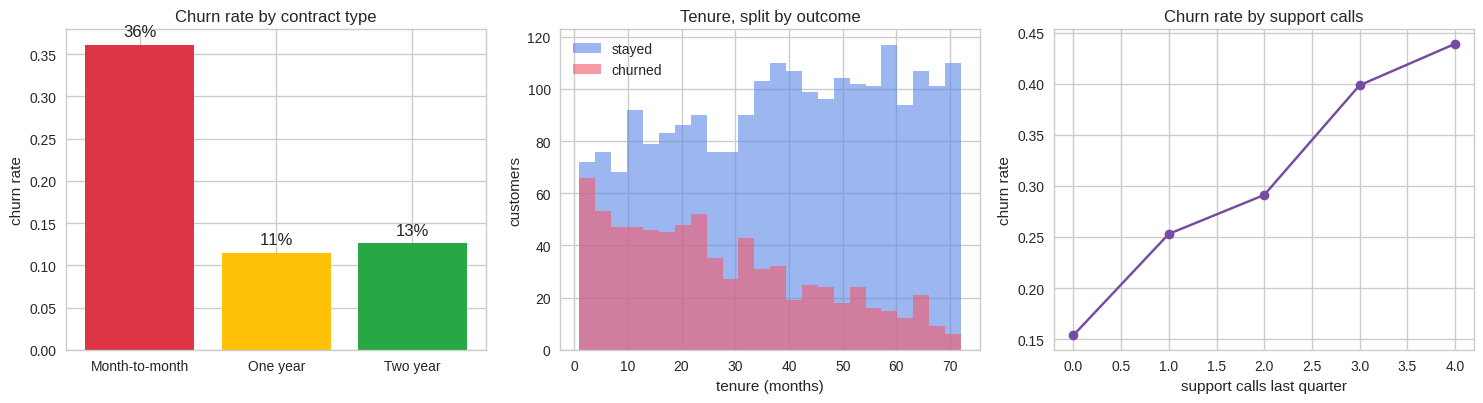

base rate (share churned): 0.254 | month-to-month churn 0.361 vs two-year 0.126


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
rate = churn.groupby("contract")["churned"].mean().reindex(["Month-to-month", "One year", "Two year"])
axes[0].bar(rate.index, rate.values, color=["#dc3545", "#ffc107", "#28a745"]); axes[0].set_ylabel("churn rate"); axes[0].set_title("Churn rate by contract type")
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 0.01, f"{v:.0%}", ha="center")
for lab, col, name in [(0, "#5b86e5", "stayed"), (1, "#f5576c", "churned")]:
    axes[1].hist(churn.loc[churn.churned == lab, "tenure_months"], bins=24, alpha=0.6, color=col, label=name)
axes[1].set_xlabel("tenure (months)"); axes[1].set_ylabel("customers"); axes[1].set_title("Tenure, split by outcome"); axes[1].legend()
rate_calls = churn.groupby("num_support_calls")["churned"].agg(["mean", "size"]).query("size >= 20")
axes[2].plot(rate_calls.index, rate_calls["mean"], marker="o", color="#764ba2"); axes[2].set_xlabel("support calls last quarter"); axes[2].set_ylabel("churn rate"); axes[2].set_title("Churn rate by support calls")
plt.tight_layout(); plt.show()
print(f"base rate (share churned): {churn.churned.mean():.3f} | month-to-month churn {rate['Month-to-month']:.3f} vs two-year {rate['Two year']:.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three one-feature views of the label. Left: churn is several times more common on month-to-month contracts than on two-year ones. Middle: churners cluster at short tenure, stayers spread across the whole range. Right: every extra support call raises the churn rate. These are the patterns a model will have to find, and they are the sanity check for the feature-importance picture later in this Part: if the model's top features are not among these three, something is wrong.

**The common misread:** treating one of these plots as the model. Each shows one feature at a time; a month-to-month customer with six years of tenure and no support calls is a low risk, and only a model that combines the columns can say so.

</div>


## 2.3 💻 One-line calls

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What the three calls do

- **`setup(df, target=...)`** builds the preprocessing pipeline (type inference, imputation, one-hot encoding), splits off a held-out partition, and fixes the cross-validation scheme. Nothing is trained yet. `test_data=` hands it a held-out set made here, so that the same rows are scored at the end of the Part; `index=False` tells it both frames carry a plain row-number index.
- **`compare_models(include=[...], fold=3, sort="AUC")`** fits every listed model inside every fold, averages the fold scores and returns the winner; `pull()` returns the table behind the call.
- **`predict_model(model, data=...)`** runs the pipeline and the model on a new table and appends a label and a score to every row.

Every argument below is a real one in PyCaret 3.3 (`inspect.signature` checks it), and every `setup` in this notebook uses the same four housekeeping arguments: `session_id=RANDOM_STATE` (seed), `n_jobs=N_JOBS` (cores), `verbose=False, html=False` (no widgets, so the calls work in a script as well as a notebook).

</div>


In [ ]:
train_churn, test_churn = train_test_split(churn, test_size=0.3, stratify=churn["churned"], random_state=RANDOM_STATE)
train_churn, test_churn = train_churn.reset_index(drop=True), test_churn.reset_index(drop=True)

sig = inspect.signature(ClassificationExperiment.setup).parameters
assert {"test_data", "index", "session_id", "n_jobs", "verbose", "html", "fold"} <= set(sig), "argument names changed"

exp_churn = ClassificationExperiment()
with timer("setup"):
    exp_churn.setup(train_churn, target="churned", test_data=test_churn, index=False,
                    session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)

setup_summary = exp_churn.pull()          # the table setup() would have displayed
print(setup_summary.to_string(index=False))
print("\ncolumns after preprocessing:", list(exp_churn.get_config("X_train_transformed").columns))


⏱️ setup: 2.8 s
                Description            Value
                 Session id               42
                     Target          churned
                Target type           Binary
        Original data shape        (3000, 8)
     Transformed data shape       (3000, 13)
Transformed train set shape       (2100, 13)
 Transformed test set shape        (900, 13)
           Numeric features                4
       Categorical features                2
                 Preprocess             True
            Imputation type           simple
         Numeric imputation             mean
     Categorical imputation             mode
   Maximum one-hot encoding               25
            Encoding method             None
             Fold Generator  StratifiedKFold
                Fold Number                3
                   CPU Jobs                2
                    Use GPU            False
             Log Experiment            False
            Experiment Name clf-default

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The `setup` summary, row by row

| Row | What it tells you |
|---|---|
| **Target / Target type** | the column to predict and whether PyCaret saw it as `Binary`, `Multiclass` or (in the regression module) `Regression`. If this row is wrong, every later number is wrong. |
| **Original data shape** | rows and columns of train plus held-out data, before preprocessing. |
| **Transformed data shape** | the same after one-hot encoding: the column count grows by one per category level, which the `columns after preprocessing` line above spells out. |
| **Transformed train / test set shape** | the two partitions; the test partition is the `test_data` passed in. |
| **Numeric / Categorical features** | how many columns landed in each bucket. Check this against the column table above; a numeric id read as a category, or a category coded as numbers read as a measurement, is the most common `setup` mistake. |
| **Imputation type, Numeric / Categorical imputation** | how missing values will be filled (mean for numbers, mode for categories by default). This table has no missing values, but the pipeline is ready for them. |
| **Maximum one-hot encoding / Encoding method** | categories with up to 25 levels are one-hot encoded; beyond that, a different encoder. |
| **Fold Generator / Fold Number** | the cross-validation scheme: `StratifiedKFold` keeps the churn rate the same in every fold, and `fold=3` keeps the tour quick. |
| **CPU Jobs / Use GPU** | the `n_jobs` and `use_gpu` arguments echoed back. |

</div>


In [ ]:
INCLUDE_CLS = ["lr", "dt", "rf", "et", "lightgbm", "gbc", "knn", "nb"]     # logistic regression, decision tree, two forests, two boosters, k-NN, naive Bayes
with timer(f"compare_models: {len(INCLUDE_CLS)} models x 3 folds"):
    best_churn = exp_churn.compare_models(include=INCLUDE_CLS, fold=3, sort="AUC", verbose=False)

cmp_churn = exp_churn.pull()
print(cmp_churn.to_string())
print(f"\nwinner by AUC: {type(best_churn).__name__}")


⏱️ compare_models: 8 models x 3 folds: 39.5 s
                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
lr                    Logistic Regression    0.7905  0.8036  0.3921  0.6483  0.4870  0.3653  0.3844    5.8900
gbc          Gradient Boosting Classifier    0.7776  0.7801  0.3752  0.6007  0.4612  0.3304  0.3453    0.8567
nb                            Naive Bayes    0.7471  0.7695  0.6398  0.5023  0.5623  0.3883  0.3943    0.1633
lightgbm  Light Gradient Boosting Machine    0.7633  0.7486  0.3808  0.5526  0.4501  0.3057  0.3148    1.0533
rf               Random Forest Classifier    0.7729  0.7450  0.3509  0.5878  0.4394  0.3082  0.3244    1.3733
et                 Extra Trees Classifier    0.7590  0.7325  0.3490  0.5410  0.4239  0.2803  0.2914    0.7733
knn                K Neighbors Classifier    0.7190  0.6346  0.2364  0.4078  0.2993  0.1389  0.1470    0.3200
dt               Decision Tree Classifier    0.6638  0.5705  0.3809  0.350

## 2.4 📤 The output

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The compare table, column by column

Every number is a **mean over the three cross-validation folds on the training partition**; the held-out partition has not been touched yet. Rows are sorted by the `sort=` column.

| Column | Meaning | Reads |
|---|---|---|
| **Accuracy** | share of rows labelled correctly at the default 0.5 cut-off | inflated by the majority class: predicting "stays" for everyone scores the base rate from Section 2.2 |
| **AUC** | area under the ROC curve: the probability that a random churner is ranked above a random stayer | threshold-free; 0.5 is a coin flip, 1.0 is a perfect ranking; the right sort key for a ranked call list |
| **Recall** | of the customers who churned, the share the model flagged | the retention team's coverage |
| **Prec.** | of the customers flagged, the share who churned | the share of offers that were not wasted |
| **F1** | the harmonic mean of precision and recall | one number for the trade-off at the default cut-off |
| **Kappa** | agreement with the truth beyond what chance would give | corrects accuracy for the base rate |
| **MCC** | Matthews correlation between predicted and true labels | the most honest single number on an imbalanced label; 0 is chance |
| **TT (Sec)** | training time per fold | the cost column |

For a binary target, Recall, Prec. and F1 are for the **positive class** (churned = 1). Recall is well below precision for most models at the default cut-off: churners are the minority, so a 0.5 cut-off flags few of them. Part 5 shows how to move the cut-off.

</div>


In [ ]:
pretty(cmp_churn.drop(columns=["Model"]), subset=[c for c in cmp_churn.columns if c not in ("Model", "TT (Sec)")])


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,0.790,0.804,0.392,0.648,0.487,0.365,0.384,5.890
gbc,0.778,0.780,0.375,0.601,0.461,0.330,0.345,0.857
nb,0.747,0.769,0.640,0.502,0.562,0.388,0.394,0.163
lightgbm,0.763,0.749,0.381,0.553,0.450,0.306,0.315,1.053
rf,0.773,0.745,0.351,0.588,0.439,0.308,0.324,1.373
et,0.759,0.733,0.349,0.541,0.424,0.280,0.291,0.773
knn,0.719,0.635,0.236,0.408,0.299,0.139,0.147,0.320
dt,0.664,0.571,0.381,0.350,0.365,0.137,0.137,0.143


`predict_model` returns the input table with columns appended. With `data=` it scores any frame that has the feature columns (the label may be present or not); without `data=` it scores the held-out partition. When the label is present, `pull()` afterwards returns the metrics on those rows. By default the score column is `prediction_score`, the probability of **whichever label was predicted**; `raw_score=True` adds one column per class instead, and `prediction_score_1` is $P(\text{churned})$, the number a ranked list needs.


In [ ]:
pred_churn = exp_churn.predict_model(best_churn, data=test_churn, verbose=False)
print("predict_model(best, data=test) -> columns appended:", [c for c in pred_churn.columns if c not in test_churn.columns])
display(pred_churn.head(6))

pred_churn = exp_churn.predict_model(best_churn, data=test_churn, raw_score=True, verbose=False)
print("\nwith raw_score=True:", [c for c in pred_churn.columns if c not in test_churn.columns])
display(pred_churn[["contract", "tenure_months", "num_support_calls", "churned", "prediction_label", "prediction_score_0", "prediction_score_1"]].head(6))

y_true, y_lab, y_prob = pred_churn["churned"].values, pred_churn["prediction_label"].values, pred_churn["prediction_score_1"].values
card_churn = pd.concat([report_card(y_true, y_lab, y_prob, name=type(best_churn).__name__),
                        report_card(y_true, np.zeros_like(y_true), np.full(len(y_true), y_true.mean()), name="always 'stays' (baseline)")])
print("\nheld-out report card:")
pretty(card_churn, subset=[c for c in card_churn.columns if c not in ("log_loss", "brier")])


predict_model(best, data=test) -> columns appended: ['prediction_label', 'prediction_score']


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,churned,prediction_label,prediction_score
0,66,89.430000,One year,Mailed check,2,True,110.400002,0,0,0.9434
1,60,69.250000,Month-to-month,Credit card,2,False,64.599998,0,0,0.8290
2,9,80.529999,One year,Bank transfer,2,True,112.199997,0,0,0.6403
3,58,70.139999,One year,Mailed check,0,False,79.500000,0,0,0.9877
4,11,70.760002,Month-to-month,Electronic check,2,False,89.300003,1,1,0.6955
5,36,53.790001,Month-to-month,Mailed check,0,True,204.699997,0,0,0.8413



with raw_score=True: ['prediction_label', 'prediction_score_0', 'prediction_score_1']


,contract,tenure_months,num_support_calls,churned,prediction_label,prediction_score_0,prediction_score_1
0,One year,66,2,0,0,0.9434,0.0566
1,Month-to-month,60,2,0,0,0.8290,0.1710
2,One year,9,2,0,0,0.6403,0.3597
3,One year,58,0,0,0,0.9877,0.0123
4,Month-to-month,11,2,1,1,0.3045,0.6955
5,Month-to-month,36,0,0,0,0.8413,0.1587



held-out report card:


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
LogisticRegression,0.783,0.655,0.612,0.395,0.480,0.365,0.797,0.573,0.453,0.149
always 'stays' (baseline),0.747,0.500,0.000,0.000,0.000,0.000,0.500,0.253,0.566,0.189


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `prediction_score` is not the churn probability

In the first frame above, `prediction_score` is high on rows labelled 0 as well as on rows labelled 1: it is the confidence in the *predicted* label. Ranking customers by it puts the surest stayers at the top of the call list. Always pass `raw_score=True` and rank by `prediction_score_1`. The report card makes the same point from the other side: the "always stays" baseline matches the model on accuracy to within a few points while its recall, MCC and AUC show it is useless.

</div>

The business deliverable is the ranked list. Sorting the scored frame by `prediction_score_1` gives it in one line:


In [ ]:
riskiest = (pred_churn.sort_values("prediction_score_1", ascending=False)
            [["contract", "tenure_months", "monthly_charge", "num_support_calls", "payment_method", "prediction_score_1", "churned"]]
            .head(10).rename(columns={"prediction_score_1": "P(churn)"}))
print("top-10 riskiest customers on the held-out set (the retention team's call list):")
display(riskiest.style.format({"P(churn)": "{:.3f}", "monthly_charge": "{:.2f}"}).background_gradient(subset=["P(churn)"], cmap="Reds"))
top_n = pred_churn.sort_values("prediction_score_1", ascending=False).head(100)
print(f"churn rate among the 100 highest-scored customers: {top_n['churned'].mean():.2f}  vs  base rate {y_true.mean():.2f}")


top-10 riskiest customers on the held-out set (the retention team's call list):


,contract,tenure_months,monthly_charge,num_support_calls,payment_method,P(churn),churned
506,Month-to-month,5,108.78,4,Electronic check,0.966,1
104,Month-to-month,8,121.63,4,Electronic check,0.951,1
568,Month-to-month,25,130.00,4,Electronic check,0.945,1
596,Month-to-month,3,82.30,3,Electronic check,0.918,1
609,Month-to-month,7,112.68,2,Electronic check,0.914,1
272,Month-to-month,20,130.00,3,Bank transfer,0.900,1
46,Month-to-month,16,130.00,3,Credit card,0.870,1
250,Month-to-month,16,55.89,5,Electronic check,0.866,1
815,Month-to-month,17,79.69,3,Electronic check,0.858,1
198,Month-to-month,23,88.00,3,Electronic check,0.847,1


churn rate among the 100 highest-scored customers: 0.66  vs  base rate 0.25


## 2.5 📊 The picture: the plot gallery

`plot_model(model, plot=<name>)` is PyCaret's signature feature: twenty-odd named diagnostics, each one call. The six below are the ones worth looking at for every binary classifier; `render` saves each as a PNG and shows it inline. (`evaluate_model(model)` shows the same gallery as a widget with one button per plot; it needs a live notebook kernel, so it is mentioned and not run.)


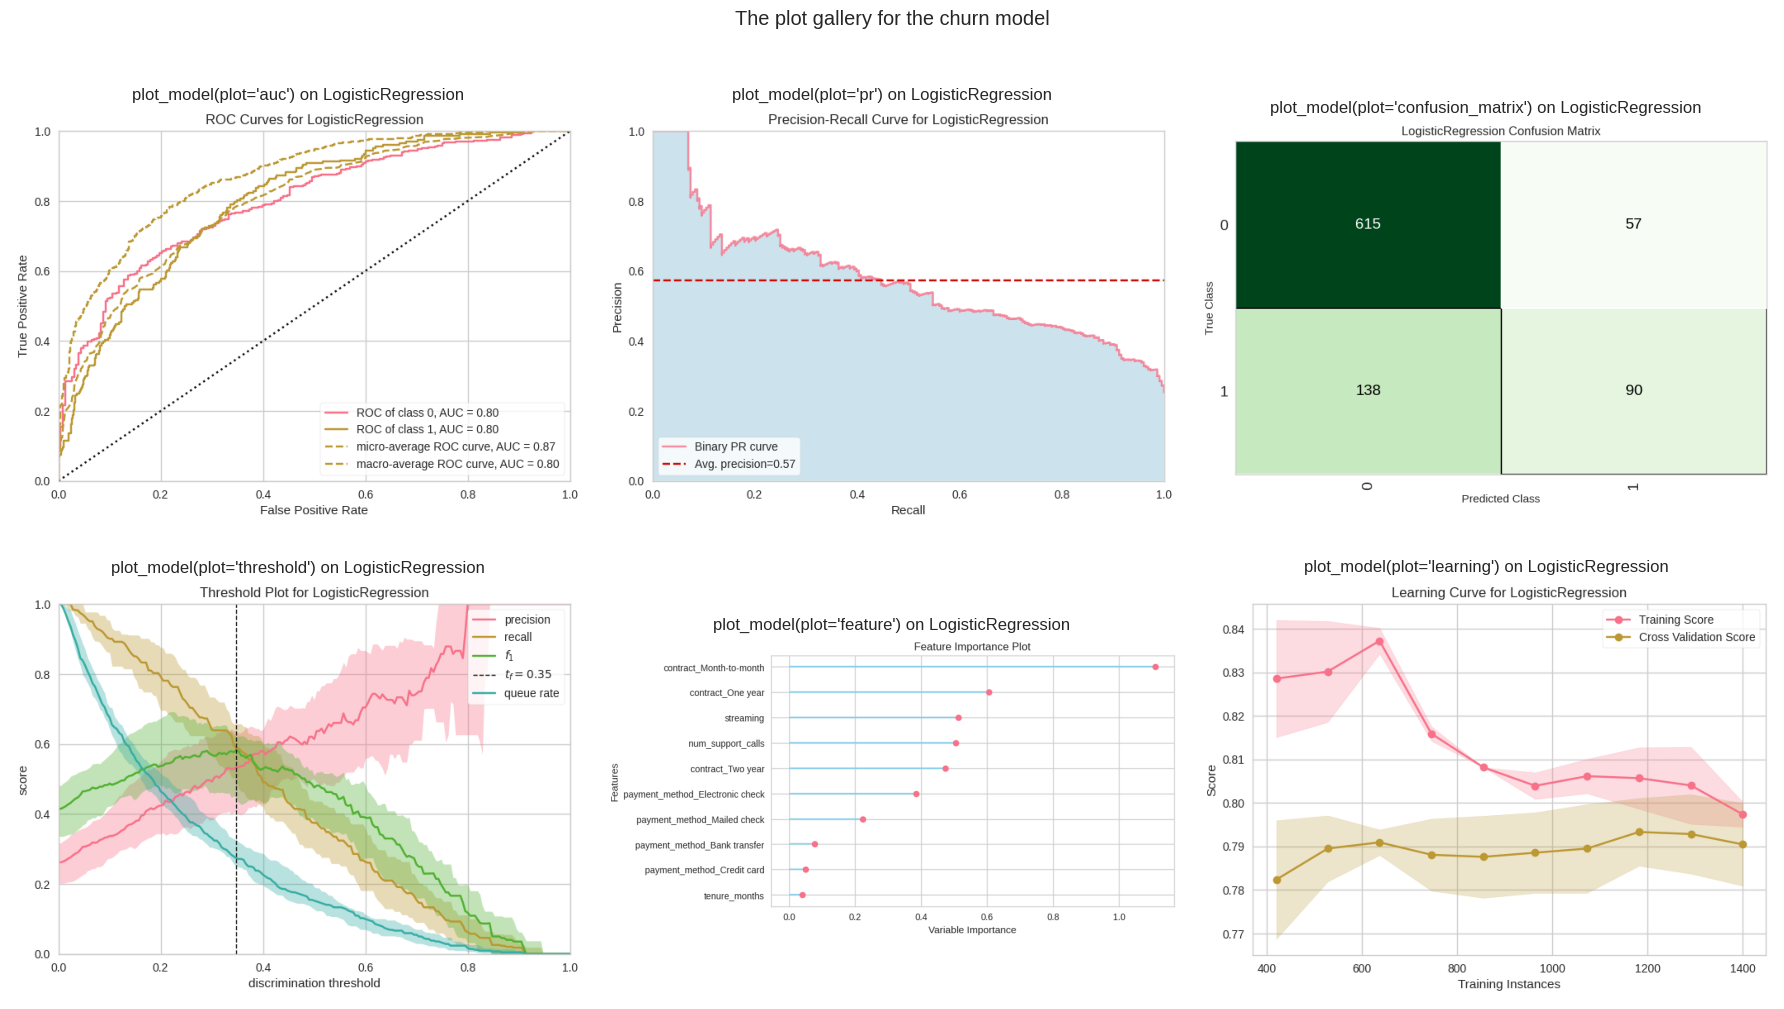

⏱️ six plot_model pictures: 32.0 s
PNG files under: /tmp/pctour_x_iz1mwp/plots -> ['AUC.png', 'Precision Recall.png', 'Confusion Matrix.png', 'Threshold.png', 'Feature Importance.png', 'Learning Curve.png']


In [ ]:
# `feature` needs coef_ or feature_importances_; k-NN and naive Bayes have neither, so fall back to a random forest for that panel only
imp_model = best_churn if (hasattr(best_churn, "coef_") or hasattr(best_churn, "feature_importances_")) else exp_churn.create_model("rf", fold=3, verbose=False)
gallery = [("auc", None), ("pr", None), ("confusion_matrix", None),
           ("threshold", {"plot_kwargs": {"n_trials": 10}}), ("feature", None), ("learning", None)]
items = []
for plot, kw in gallery:                       # render_grid takes (title, fn, kwargs) triples and saves every PNG before drawing
    model = imp_model if plot == "feature" else best_churn
    items.append((f"plot_model(plot='{plot}') on {type(model).__name__}",
                  lambda model=model, plot=plot, **k: exp_churn.plot_model(model, plot=plot, verbose=False, **k), kw))
with timer("six plot_model pictures"):
    gallery_files = render_grid(items, ncols=3, figsize=(18, 10.5), suptitle="The plot gallery for the churn model")
print("PNG files under:", PLOTS, "->", [os.path.basename(p) for p in gallery_files])


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six views of one model on the held-out partition (the learning curve uses the training partition).

- **`auc`** (top left): true-positive rate against false-positive rate as the cut-off moves; the area is the AUC column of the compare table. The further the curve bows towards the top-left corner, the better the ranking.
- **`pr`** (top middle): precision against recall as the cut-off moves. It starts high and falls as the model flags more customers; on a minority target this picture is harsher and more honest than the ROC.
- **`confusion_matrix`** (top right): the four counts at the 0.5 cut-off. The bottom row is the actual churners; the bottom-left cell is the churners the model missed.
- **`threshold`** (bottom left): precision, recall, F1 and queue rate (the share of customers flagged) against the cut-off, with bands from refitting on `n_trials` random splits. The dashed line marks the F1 optimum.
- **`feature`** (bottom middle): the model's coefficients (linear models) or importances (tree models) on the encoded columns. Contract and support calls, two of the three columns Section 2.2 flagged, sit near the top.
- **`learning`** (bottom right): training and cross-validation score against training-set size. Converging lines mean more rows would not help much; a wide gap means the model is memorising.

**The common misread:** reading the `feature` bars of a linear model as "how much each column matters". They are raw coefficients on unscaled columns: `tenure_months` sits at the bottom although Section 2.2 showed tenure separates churners from stayers, because its coefficient is *per month* and tenure runs over dozens of months, while a one-hot column runs from 0 to 1. `setup(normalize=True)` puts every column on one scale and makes the bars comparable; tree importances do not have this problem. The confusion matrix has a cousin of the same trap: its counts depend on the 0.5 cut-off, which no one chose, and the `threshold` plot next to it shows how much recall a different cut-off buys.

</div>


## 2.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ `pycaret.classification` for a yes/no question

**Reach for it when** the data is a table with one row per case and one binary label (churn, default, fraud, click, conversion, defect), and the question is either "which cases" (a ranked list) or "how likely" (a probability). **What it costs:** one `setup` (a few seconds) and one `compare_models` (seconds per model per fold); the whole Part ran in about a minute. **The one gotcha:** the default `prediction_score` and the default 0.5 cut-off. Rank by `prediction_score_1` and choose the cut-off from the `threshold` plot or from a cost model (Part 5).

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: sort by the metric the decision uses

`compare_models` sorts by `Accuracy` unless told otherwise, and on this label accuracy barely separates the models from the "always stays" baseline. A ranked call list needs a ranking metric, so this Part sorted by `AUC`; a fixed-size list needs precision at that size; a cost-sensitive decision needs the cost. Pick `sort=` before running the call, not after reading the table.

</div>


## 2.7 Task 2 Summary

**✅ Key Takeaways**
- The input is a table with a binary label; `show_input` shows the base rate, and `setup` infers types and the `Binary` target. Read the summary before trusting anything after it.
- `compare_models(include=..., fold=3, sort="AUC")` returns the winner and `pull()` returns the table: fold-averaged metrics on the training partition only.
- `predict_model(model, data=df, raw_score=True)` appends `prediction_label` and one probability column per class; rank by `prediction_score_1`.
- `report_card` next to an "always stays" baseline shows why accuracy is the wrong headline on an imbalanced label.
- The plot gallery is six calls of `plot_model`; `render` makes them work in any runtime.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_churn`, `churn`, `train_churn`, `test_churn` | the generator, the table, and its 70/30 stratified split |
| `exp_churn`, `setup_summary` | the `ClassificationExperiment` and the `setup` summary table |
| `INCLUDE_CLS`, `best_churn`, `cmp_churn` | the model list, the AUC winner, and the compare table |
| `pred_churn`, `card_churn`, `riskiest` | the scored held-out frame, its report card, and the top-10 call list |
| `imp_model`, `gallery`, `items`, `gallery_files` | the model used for the `feature` panel, the six plot names, the `(title, fn, kwargs)` triples for `render_grid`, and the PNG paths |

**➡️ Next Up:** Part 2 — the same calls when the label has five values instead of two.


# Part 2 · Multiclass Classification: Loan Grades ⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

**`pycaret.classification` on a label with more than two values.** The calls are the ones from Part 1, unchanged. What changes is what comes out: one probability column per class, metrics that have to be averaged across classes, and a confusion matrix with a diagonal to read instead of four cells.

</div>

# Task 3 · Which grade does this loan get?

## 3.1 ❓ The problem

A lender assigns every application a **grade** from `A` (safest) to `E` (riskiest); the grade sets the interest rate. Today an underwriter grades by hand from the applicant's income, debt, credit score and history. The question: can the grade be predicted from the application alone, so that the obvious cases are graded automatically and the underwriters spend their time on the borderline ones? A good answer changes the turnaround time; a wrong grade changes the price the customer pays.

Five labels make this a **multiclass** problem. The grades are also **ordinal** (B sits between A and C), which PyCaret does not know: it treats the five grades as five unrelated labels. Section 3.5 measures what that costs.


## 3.2 📥 The input

The grade is planted to follow a risk score built from credit score, debt-to-income ratio, income, delinquencies, home ownership and loan purpose, plus noise, so no model can reach perfect accuracy. The classes are imbalanced on purpose: `C` is the most common grade and `E` the rarest.


In [ ]:
def make_loans(n=3000, seed=RANDOM_STATE):
    # One row per application; `grade` A..E follows a planted risk score with noise, so accuracy cannot be perfect.
    rng = np.random.default_rng(seed)
    income = np.round(np.exp(rng.normal(np.log(58000), 0.45, n)), -2)
    loan = np.round(np.exp(rng.normal(np.log(15000), 0.6, n)), -2)
    score = rng.integers(520, 850, n)
    dti = np.round(rng.beta(2, 5, n) * 60, 1)                              # debt-to-income, percent
    emp = rng.integers(0, 30, n)
    home = rng.choice(["rent", "mortgage", "own"], n, p=[0.45, 0.40, 0.15])
    purpose = rng.choice(["car", "home", "education", "business", "debt"], n, p=[0.2, 0.2, 0.15, 0.15, 0.3])
    delinq = rng.poisson(0.3, n)                                           # delinquencies in the last two years
    risk = (-(score - 685) / 60 + dti / 15 - 1.2 * np.log(income / 58000) + 0.6 * delinq + 0.4 * (home == "rent")
            + 0.5 * (purpose == "business") + 0.25 * np.log(loan / 15000) - 0.02 * emp + rng.normal(0, 0.9, n))
    cuts = np.quantile(risk, [0.12, 0.40, 0.72, 0.90])                     # A 12%, B 28%, C 32%, D 18%, E 10%
    grade = np.array(list("ABCDE"))[np.searchsorted(cuts, risk)]
    return pd.DataFrame({"annual_income": income, "loan_amount": loan, "credit_score": score, "dti_pct": dti,
                         "employment_years": emp, "home_ownership": home, "purpose": purpose, "delinquencies_2y": delinq, "grade": grade})

loans = make_loans()
GRADES = list("ABCDE")
show_input(loans, label="grade", name="loan applications")


📥 loan applications: 3,000 rows x 9 columns | label = 'grade'


,annual_income,loan_amount,credit_score,dti_pct,employment_years,home_ownership,purpose,delinquencies_2y,grade
0,66500.0,31700.0,747,16.2,12,rent,car,0,B
1,36300.0,22700.0,734,17.6,18,mortgage,education,0,C
2,81300.0,48800.0,650,11.6,13,own,debt,1,B
3,88600.0,5900.0,775,21.6,16,rent,debt,0,B
4,24100.0,12800.0,761,34.6,28,mortgage,education,0,E


column types: {'annual_income': 'numeric', 'loan_amount': 'numeric', 'credit_score': 'numeric', 'dti_pct': 'numeric', 'employment_years': 'numeric', 'home_ownership': 'text/category', 'purpose': 'text/category', 'delinquencies_2y': 'numeric', 'grade': 'text/category'}
label distribution: {'C': 0.32, 'B': 0.28, 'D': 0.18, 'A': 0.12, 'E': 0.1}


| Column | Type | Meaning |
|---|---|---|
| `annual_income`, `loan_amount` | numeric | in currency |
| `credit_score` | numeric | bureau score, higher is safer |
| `dti_pct` | numeric | monthly debt payments as a share of income |
| `employment_years` | numeric | years in current job |
| `home_ownership` | category | `rent`, `mortgage`, `own` |
| `purpose` | category | what the loan is for |
| `delinquencies_2y` | numeric | late payments in the last two years |
| `grade` | **target** | `A` .. `E`, five classes |

`setup()` sees five distinct text values in `grade` and infers a **Multiclass** target; it label-encodes the grades internally and decodes them again in `predict_model`, so the output frame shows letters, not integers.


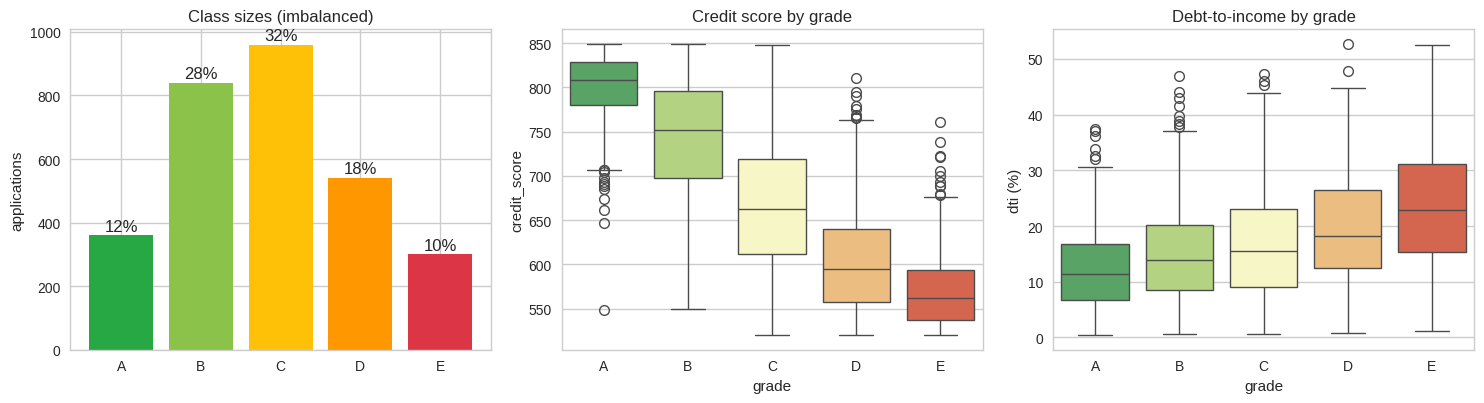

class shares: {'A': 0.12, 'B': 0.28, 'C': 0.32, 'D': 0.18, 'E': 0.1}
majority-class accuracy (always predict 'C'): 0.320


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
counts = loans["grade"].value_counts().reindex(GRADES)
axes[0].bar(counts.index, counts.values, color=["#28a745", "#8bc34a", "#ffc107", "#ff9800", "#dc3545"]); axes[0].set_ylabel("applications"); axes[0].set_title("Class sizes (imbalanced)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f"{v / len(loans):.0%}", ha="center")
sns.boxplot(data=loans, x="grade", y="credit_score", order=GRADES, ax=axes[1], palette="RdYlGn_r"); axes[1].set_title("Credit score by grade")
sns.boxplot(data=loans, x="grade", y="dti_pct", order=GRADES, ax=axes[2], palette="RdYlGn_r"); axes[2].set_title("Debt-to-income by grade"); axes[2].set_ylabel("dti (%)")
plt.tight_layout(); plt.show()
print("class shares:", (counts / len(loans)).round(3).to_dict())
print(f"majority-class accuracy (always predict '{counts.idxmax()}'): {counts.max() / len(loans):.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the five class sizes, which set the baseline: always predicting the largest class scores the printed majority-class accuracy, and the two rarest grades are where a model will struggle. Middle and right: credit score falls and debt-to-income rises from `A` to `E`, but the boxes overlap heavily between neighbouring grades. The overlap is the ordinal structure showing through: an application on the `B`/`C` border looks almost the same from either side.

**The common misread:** expecting accuracy near 1 because the boxes trend so clearly. The trend is between `A` and `E`; the decision is between `B` and `C`, where the boxes overlap, and that is where most errors will land.

</div>


## 3.3 💻 One-line calls

The same three calls as Part 1. Two additions: `add_metric` registers a **macro-averaged F1** (the F1 of each grade, averaged with equal weight, so the rare grades count as much as `C`), and `compare_models` sorts by `Accuracy` because the lender's question is "how often is the automatic grade right".


In [ ]:
train_loans, test_loans = train_test_split(loans, test_size=0.3, stratify=loans["grade"], random_state=RANDOM_STATE)
train_loans, test_loans = train_loans.reset_index(drop=True), test_loans.reset_index(drop=True)

exp_loans = ClassificationExperiment()
with timer("setup"):
    exp_loans.setup(train_loans, target="grade", test_data=test_loans, index=False,
                    session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)
s = exp_loans.pull().set_index("Description")["Value"]
for key in ["Target", "Target type", "Original data shape", "Transformed data shape", "Numeric features", "Categorical features", "Fold Generator"]:
    print(f"{key:>25}: {s[key]}")
print("target as given:", sorted(train_loans["grade"].unique()), "-> as the models see it:", sorted(exp_loans.get_config("y_train_transformed").unique()))


⏱️ setup: 2.0 s
                   Target: grade
              Target type: Multiclass
      Original data shape: (3000, 9)
   Transformed data shape: (3000, 15)
         Numeric features: 6
     Categorical features: 2
           Fold Generator: StratifiedKFold
target as given: ['A', 'B', 'C', 'D', 'E'] -> as the models see it: [0, 1, 2, 3, 4]


`add_metric(id, name, score_func, target="pred", greater_is_better=True, **kwargs)` registers any scikit-learn scoring function. The natural call passes `average="macro"` as a keyword, and the next cell does that first, **on purpose**: in PyCaret 3.3.2 the keywords are kept for `predict_model` but dropped from the cross-validation scorer, and the scorer is also called with `sample_weight=`. The cross-validated column comes back as `0.0000`, which is an error score, not a score. The fix is a two-line wrapper that fixes the averaging and accepts extra keywords.


In [ ]:
sig = inspect.signature(ClassificationExperiment.add_metric).parameters
assert {"id", "name", "score_func", "target", "greater_is_better", "kwargs"} <= set(sig), "add_metric signature changed"

exp_loans.add_metric("f1_macro_kw", "F1 Macro (kwargs)", f1_score, average="macro")     # the natural call: broken in CV

def f1_macro(y_true, y_pred, **kwargs):
    # PyCaret's CV scorer passes sample_weight=; the averaging is fixed here instead of via add_metric kwargs
    return f1_score(y_true, y_pred, average="macro")
exp_loans.add_metric("f1_macro", "F1 Macro", f1_macro)                                   # the fix

with timer(f"compare_models: {len(INCLUDE_CLS)} models x 3 folds, 5 classes"):
    best_loans = exp_loans.compare_models(include=INCLUDE_CLS, fold=3, sort="Accuracy", verbose=False)
cmp_loans = exp_loans.pull()
print(cmp_loans.to_string())
exp_loans.remove_metric("f1_macro_kw")
print(f"\nwinner by Accuracy: {type(best_loans).__name__} | 'F1 Macro (kwargs)' is 0.0000 everywhere (a swallowed error), 'F1 Macro' is the real macro-F1 -> the broken metric is removed")


⏱️ compare_models: 8 models x 3 folds, 5 classes: 22.1 s
                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  F1 Macro (kwargs)  F1 Macro  TT (Sec)
lightgbm  Light Gradient Boosting Machine    0.5471  0.8216  0.5471  0.5501  0.5462  0.3991  0.4001                0.0    0.5427    1.9133
gbc          Gradient Boosting Classifier    0.5443  0.0000  0.5443  0.5472  0.5432  0.3954  0.3964                0.0    0.5393    1.8533
rf               Random Forest Classifier    0.5386  0.8217  0.5386  0.5438  0.5314  0.3793  0.3824                0.0    0.5070    0.5333
nb                            Naive Bayes    0.5276  0.8105  0.5276  0.5339  0.5224  0.3672  0.3698                0.0    0.5132    0.1133
et                 Extra Trees Classifier    0.5038  0.8008  0.5038  0.5058  0.4961  0.3322  0.3350                0.0    0.4692    0.4767
dt               Decision Tree Classifier    0.4719  0.6504  0.4719  0.4756  0.4720  0.3068  0.3073          

## 3.4 📤 The output

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The compare table with five classes

The columns are the same as in Part 1, but Recall, Prec., F1 and AUC now have to be **averaged across classes**, and PyCaret's default is the **weighted** average: each class's score weighted by its size. Two consequences visible in the table:

- **Recall equals Accuracy** in every row. Weighted recall is the share of rows whose class was predicted correctly, which is accuracy by another name; it says nothing about the rare grades.
- **F1 Macro** is lower than **F1**. The macro average gives `A` and `E` the same weight as `C`, and the rare grades are the hard ones. When the rare classes matter (they do: `E` is where the money is lost), macro-F1 is the column to sort by.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A `0.0000` in the table is an error, not a score

`compare_models` runs with `errors="ignore"`: any metric that raises inside a fold is scored as 0 and the run continues. Two cases appear in this Part. The `F1 Macro (kwargs)` column above was 0 for every model because the scorer was mis-built. And the **AUC column is 0.0000 for logistic regression and gradient boosting** (models that expose `decision_function`), because with scikit-learn 1.4 PyCaret's multiclass AUC scorer asks for decision scores first and `roc_auc_score(multi_class="ovr")` rejects them for not being probabilities; models without `decision_function` (forests, LightGBM, naive Bayes) get their AUC from `predict_proba` and are fine. `predict_model` computes AUC differently and reports the true value, as the held-out row below shows. Treat every exact zero as a question.

</div>


In [ ]:
pretty(cmp_loans.drop(columns=["Model"]), subset=[c for c in cmp_loans.columns if c not in ("Model", "TT (Sec)")])


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1 Macro (kwargs),F1 Macro,TT (Sec)
lightgbm,0.547,0.822,0.547,0.550,0.546,0.399,0.400,0.000,0.543,1.913
gbc,0.544,0.000,0.544,0.547,0.543,0.395,0.396,0.000,0.539,1.853
rf,0.539,0.822,0.539,0.544,0.531,0.379,0.382,0.000,0.507,0.533
nb,0.528,0.810,0.528,0.534,0.522,0.367,0.370,0.000,0.513,0.113
et,0.504,0.801,0.504,0.506,0.496,0.332,0.335,0.000,0.469,0.477
dt,0.472,0.650,0.472,0.476,0.472,0.307,0.307,0.000,0.469,0.120
lr,0.359,0.000,0.359,0.345,0.304,0.099,0.106,0.000,0.225,0.533
knn,0.255,0.506,0.255,0.243,0.244,0.003,0.003,0.000,0.202,0.180


`predict_model(..., raw_score=True)` now appends **one probability column per class**, `prediction_score_A` .. `prediction_score_E`; `prediction_label` is the class with the largest of them. `report_card` is written for binary labels, so the per-class view comes from scikit-learn's `classification_report`, turned into a DataFrame.


In [ ]:
from sklearn.metrics import classification_report, cohen_kappa_score

pred_loans = exp_loans.predict_model(best_loans, data=test_loans, raw_score=True, verbose=False)
held_out_row = exp_loans.pull()
prob_cols = [f"prediction_score_{g}" for g in GRADES]
print("columns appended:", [c for c in pred_loans.columns if c not in test_loans.columns])
display(pred_loans[["credit_score", "dti_pct", "annual_income", "grade", "prediction_label"] + prob_cols].head(8))
print("\nPyCaret's held-out row (pull() after predict_model):"); display(held_out_row)

y_true_g, y_pred_g = pred_loans["grade"].astype(str).values, pred_loans["prediction_label"].astype(str).values
rep = pd.DataFrame(classification_report(y_true_g, y_pred_g, output_dict=True, zero_division=0)).T
rep["support"] = rep["support"].astype(int)
print("\nper-class report on the held-out set:")
pretty(rep, subset=["precision", "recall", "f1-score"])


columns appended: ['prediction_label', 'prediction_score_A', 'prediction_score_B', 'prediction_score_C', 'prediction_score_D', 'prediction_score_E']


,credit_score,dti_pct,annual_income,grade,prediction_label,prediction_score_A,prediction_score_B,prediction_score_C,prediction_score_D,prediction_score_E
0,617,1.000000,49300.0,D,C,0.0011,0.0132,0.6752,0.3090,0.0016
1,539,22.100000,85900.0,D,D,0.0003,0.0010,0.2964,0.4847,0.2177
2,742,7.100000,44600.0,A,B,0.0341,0.7814,0.1839,0.0006,0.0001
3,825,37.099998,35600.0,B,C,0.0037,0.3083,0.6794,0.0075,0.0010
4,722,30.799999,42100.0,E,D,0.0000,0.0073,0.2076,0.7850,0.0001
5,567,15.000000,175300.0,D,D,0.0008,0.1250,0.0549,0.8171,0.0021
6,539,41.400002,62900.0,E,E,0.0000,0.0000,0.0003,0.0034,0.9962
7,741,18.600000,97800.0,B,B,0.2187,0.7539,0.0269,0.0004,0.0000



PyCaret's held-out row (pull() after predict_model):


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1 Macro
0,Light Gradient Boosting Machine,0.5433,0.8286,0.5433,0.5405,0.5398,0.3937,0.3946,0.5262



per-class report on the held-out set:


,precision,recall,f1-score,support
A,0.609,0.491,0.544,108.000
B,0.586,0.623,0.604,252.000
C,0.543,0.611,0.575,288.000
D,0.419,0.352,0.383,162.000
E,0.541,0.511,0.526,90.000
accuracy,0.543,0.543,0.543,0.000
macro avg,0.540,0.518,0.526,900.000
weighted avg,0.541,0.543,0.540,900.000


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: read the per-class rows before the averages

The `accuracy`, `macro avg` and `weighted avg` rows at the bottom of the report are what the compare table showed. The five rows above them are what it hid: recall per grade, which ranges widely across the five rows while the accuracy is one number. A lender cares most about `E` being caught, so the number to watch is the `E` row's recall, not the accuracy. Sorting `compare_models` by the macro-F1 registered above is the one-line way to make the model selection care about the same thing.

</div>


## 3.5 📊 The picture

Two views of the confusion matrix: PyCaret's `plot_model(plot="confusion_matrix")` with raw counts, and a row-normalised version drawn with matplotlib, where each row sums to one and the diagonal is the per-class recall from the report above.


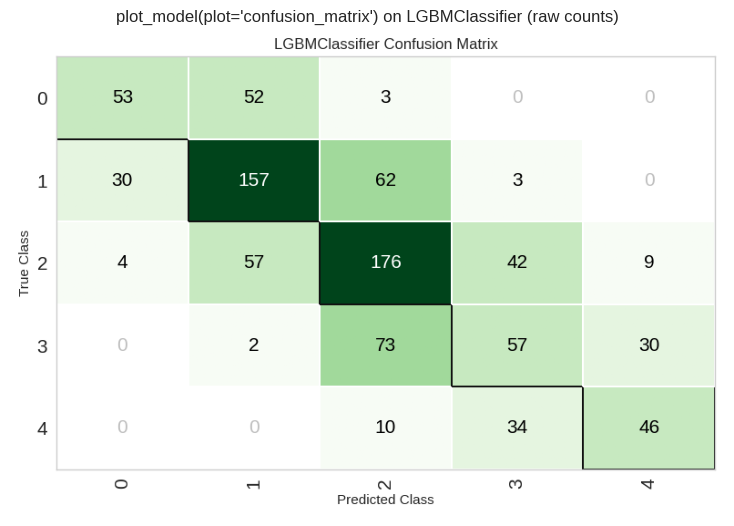

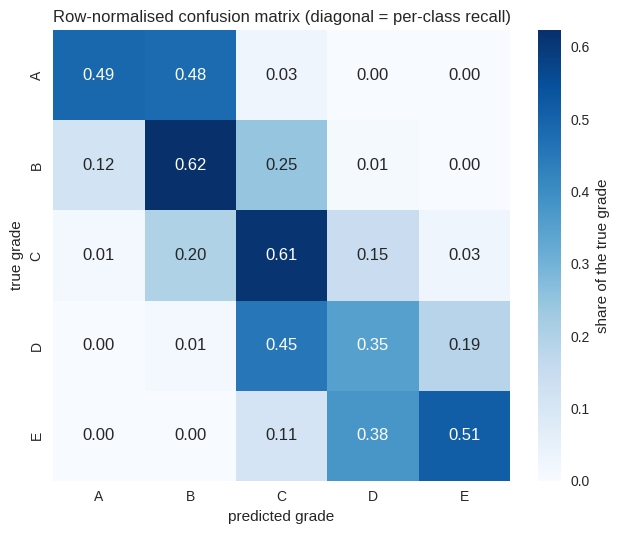

per-class recall (diagonal): {'A': 0.491, 'B': 0.623, 'C': 0.611, 'D': 0.352, 'E': 0.511}


In [ ]:
from sklearn.metrics import confusion_matrix

render(lambda **k: exp_loans.plot_model(best_loans, plot="confusion_matrix", verbose=False, **k),
       title=f"plot_model(plot='confusion_matrix') on {type(best_loans).__name__} (raw counts)")

cm = confusion_matrix(y_true_g, y_pred_g, labels=GRADES)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=GRADES, yticklabels=GRADES, ax=ax, cbar_kws={"label": "share of the true grade"})
ax.set_xlabel("predicted grade"); ax.set_ylabel("true grade"); ax.set_title("Row-normalised confusion matrix (diagonal = per-class recall)")
plt.tight_layout(); plt.show()
print("per-class recall (diagonal):", dict(zip(GRADES, np.round(np.diag(cm_norm), 3))))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The raw-count matrix is dominated by the big middle classes; the normalised one puts every grade on the same footing. The mass sits on the diagonal and on the two cells next to it: when the model is wrong, it is almost always wrong by **one grade**, and the cells two or more steps away are nearly empty. Recall is highest for the two large middle grades and lowest for `D`, which is squeezed between a bigger `C` and a sharper `E`, and for `A`; each loses its mass to its neighbours, not to distant grades.

**The common misread:** counting every off-diagonal cell as the same kind of error. Grading a `D` loan as `C` misprices it a little; grading it as `A` misprices it a lot. The confusion matrix shows the distinction; accuracy and F1 throw it away.

</div>

The next cell makes that concrete: stacked probability bars for eight applicants (how sure the model is, and about which neighbours it hesitates) and the "off by how many grades" breakdown.


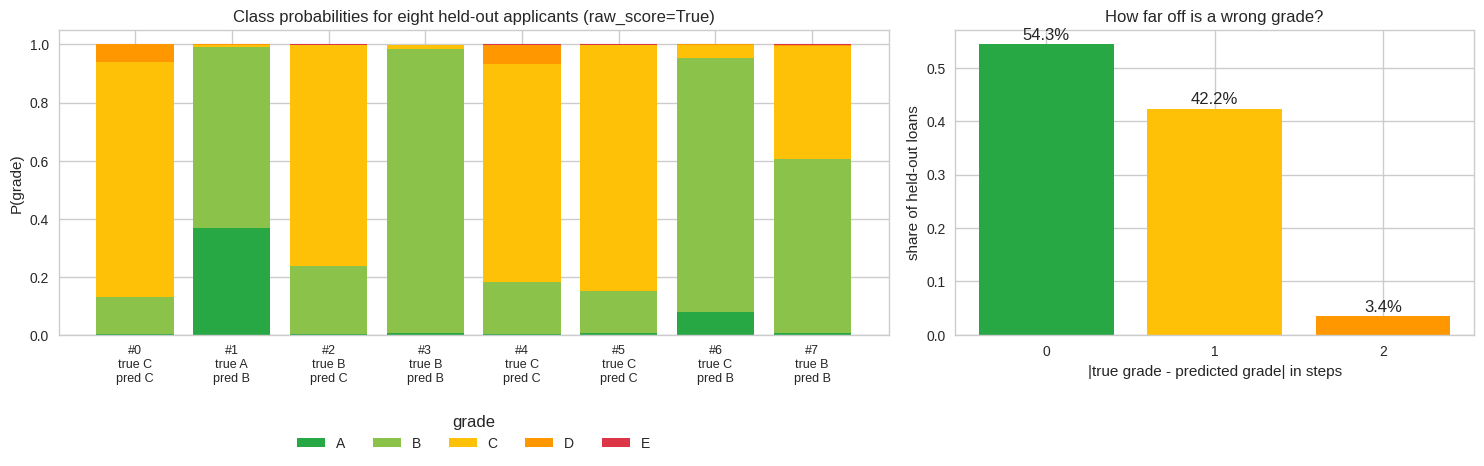

exact: 0.543 | off by one grade: 0.422 | off by two or more: 0.034
'within one grade' accuracy: 0.966  vs  exact accuracy 0.543


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.6, 1]})
sample = pred_loans.sample(8, random_state=RANDOM_STATE).reset_index(drop=True)
bottom = np.zeros(len(sample)); colors = ["#28a745", "#8bc34a", "#ffc107", "#ff9800", "#dc3545"]
for g, col in zip(GRADES, colors):
    axes[0].bar(range(len(sample)), sample[f"prediction_score_{g}"], bottom=bottom, color=col, label=g); bottom += sample[f"prediction_score_{g}"].values
axes[0].set_xticks(range(len(sample))); axes[0].set_xticklabels([f"#{i}\ntrue {t}\npred {p}" for i, (t, p) in enumerate(zip(sample['grade'].astype(str), sample['prediction_label'].astype(str)))], fontsize=9)
axes[0].set_ylabel("P(grade)"); axes[0].set_title("Class probabilities for eight held-out applicants (raw_score=True)"); axes[0].legend(title="grade", ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.22))

steps = (pd.Series(y_true_g).map(GRADES.index) - pd.Series(y_pred_g).map(GRADES.index)).abs()
off = steps.value_counts(normalize=True).sort_index()
axes[1].bar(off.index.astype(str), off.values, color=["#28a745", "#ffc107", "#ff9800", "#dc3545", "#8b0000"][:len(off)])
for i, v in enumerate(off.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")
axes[1].set_xlabel("|true grade - predicted grade| in steps"); axes[1].set_ylabel("share of held-out loans"); axes[1].set_title("How far off is a wrong grade?")
plt.tight_layout(); plt.show()
print(f"exact: {off.get(0, 0):.3f} | off by one grade: {off.get(1, 0):.3f} | off by two or more: {off[off.index >= 2].sum():.3f}")
print(f"'within one grade' accuracy: {off.get(0, 0) + off.get(1, 0):.3f}  vs  exact accuracy {off.get(0, 0):.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: each bar is one applicant and the coloured segments are the five probabilities. A confident case has one tall segment; a borderline case splits its mass between two **adjacent** colours, which is the ordinal structure showing up in a model that was never told about it. Right: the share of held-out loans graded exactly right, one step off, and two or more steps off. The "within one grade" accuracy printed under the plot is the number an underwriter would quote; the compare table only knows the exact one.

**The common misread:** taking the exact accuracy as the business accuracy. If a one-step error is acceptable (the underwriter reviews borderline cases anyway), the model is far more useful than the compare table suggests; if it is not, the fix is an ordinal method or a cost matrix, neither of which `compare_models` applies.

</div>


## 3.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ `pycaret.classification` for more than two labels

**Reach for it when** the label is one of several named categories (grade, product tier, ticket category, defect type) and the same table-with-a-target shape holds. The calls do not change; `predict_model(raw_score=True)` returns one probability per class. **What it costs:** about the same as binary on this table (the timer above); models that fit one-vs-rest scale with the number of classes. **The one gotcha:** ordinal labels. PyCaret treats `A..E` as unrelated, so a one-step error and a four-step error cost the same during training. Check the off-by-k breakdown; if the steps matter, regress on the ordinal position (Part 3's module) or reweight the classes.

</div>


## 3.7 Task 3 Summary

**✅ Key Takeaways**
- `setup` infers `Multiclass` from a target with more than two values and label-encodes it; `predict_model` decodes it back.
- With several classes the table's Recall, Prec., F1 and AUC are weighted averages; weighted recall equals accuracy, so register a macro-F1 with `add_metric` when rare classes matter.
- `add_metric` keywords are dropped from the cross-validation scorer in PyCaret 3.3.2 and the scorer passes `sample_weight=`; wrap the metric in a function that fixes its arguments and accepts `**kwargs`.
- An exact `0.0000` in a compare table is a swallowed error (`errors="ignore"`), never a score.
- Read the per-class report and the row-normalised confusion matrix; on ordinal labels, count how many steps off the errors are.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_loans`, `loans`, `GRADES`, `train_loans`, `test_loans` | the generator, the table, the ordered class list and the stratified split |
| `exp_loans`, `best_loans`, `cmp_loans` | the experiment, the accuracy winner and the compare table (with the `F1 Macro` column) |
| `f1_macro` | the wrapper that makes `add_metric` work inside cross-validation |
| `pred_loans`, `held_out_row`, `prob_cols`, `rep` | the scored held-out frame, PyCaret's metric row, the five probability columns, the per-class report |
| `cm`, `cm_norm`, `off` | the confusion matrix, its row-normalised version, and the off-by-k breakdown |

**➡️ Next Up:** Part 3 — the target is a number: house prices, and what `transform_target` does to a skewed one.


# Part 3 · Regression: House Prices ⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

**`pycaret.regression` on a numeric target.** Same grammar, different module: `RegressionExperiment().setup(df, target="price_k")`, `compare_models(sort="MAE")`, `predict_model`. The metrics change to error sizes in the target's own units, the plot gallery changes to residual diagnostics, and one `setup` flag, `transform_target`, decides whether the model learns prices or log-like prices.

</div>

# Task 4 · What is this house worth?

## 4.1 ❓ The problem

An estate agency wants a first-pass valuation for every new listing before an agent visits: size, age, neighbourhood, distance to the centre, condition. A good answer is a number within a few percent of the eventual sale price, and an honest error bar. What changes with a good answer is the asking price on day one; what changes with a bad one is a house that sits unsold for months or sells below value in a week.

The target is a **number**, so this is **regression**. House prices are also **right-skewed**: most homes cluster around the median and a long tail of expensive ones stretches to several times that. Skew is why this Part runs `setup` twice.


## 4.2 📥 The input

Prices are generated as a log-normal: a base price multiplied by neighbourhood, size, age, distance and condition effects, with multiplicative noise. The target is stored in **thousands** (`price_k`), the way listing tables usually store it and, as Section 4.3 shows, the scale that keeps the target transform numerically safe.


In [ ]:
def make_houses(n=3000, seed=RANDOM_STATE):
    # One row per listing; price is log-normal with planted neighbourhood, size, age, distance and condition effects.
    rng = np.random.default_rng(seed)
    hoods = ["Riverside", "Old Town", "Hillcrest", "Eastfield", "Meadows"]
    hood_effect = {"Riverside": 0.35, "Old Town": 0.15, "Hillcrest": 0.25, "Eastfield": -0.15, "Meadows": 0.0}
    hood = rng.choice(hoods, n, p=[0.15, 0.2, 0.2, 0.25, 0.2])
    sqft = np.round(np.exp(rng.normal(np.log(1800), 0.35, n)), -1).clip(500, 6000)
    beds = np.clip(np.round(sqft / 650 + rng.normal(0, 0.7, n)), 1, 6).astype(int)
    baths = np.clip(np.round(beds * 0.6 + rng.normal(0, 0.5, n)), 1, 4).astype(int)
    age = rng.integers(0, 90, n)
    lot = np.round(np.exp(rng.normal(np.log(6000), 0.5, n)), -2)
    garage = rng.choice([0, 1, 2, 3], n, p=[0.2, 0.4, 0.35, 0.05])
    dist = np.round(rng.gamma(2.5, 3.0, n), 1)                             # km to the city centre
    cond = rng.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.15, 0.4, 0.3, 0.1])   # surveyor's condition rating
    log_price = (np.log(320) + 0.75 * np.log(sqft / 1800) + 0.05 * baths - 0.004 * age + np.array([hood_effect[h] for h in hood])
                 - 0.025 * dist + 0.06 * (cond - 3) + 0.04 * garage + 0.08 * np.log(lot / 6000) + rng.normal(0, 0.18, n))
    return pd.DataFrame({"sqft": sqft, "bedrooms": beds, "bathrooms": baths, "age_years": age, "lot_sqft": lot, "garage_spaces": garage,
                         "neighbourhood": hood, "dist_centre_km": dist, "condition": cond, "price_k": np.round(np.exp(log_price), 1)})

houses = make_houses()
show_input(houses, label="price_k", name="house listings")
print(f"price_k: median {houses.price_k.median():.0f}, mean {houses.price_k.mean():.0f}, max {houses.price_k.max():.0f} (thousands) | skew {houses.price_k.skew():.2f}")


📥 house listings: 3,000 rows x 10 columns | label = 'price_k'


,sqft,bedrooms,bathrooms,age_years,lot_sqft,garage_spaces,neighbourhood,dist_centre_km,condition,price_k
0,2610.0,4,2,68,5100.0,2,Eastfield,1.7,3,288.9
1,1380.0,1,1,38,6100.0,1,Hillcrest,14.7,3,241.2
2,690.0,1,1,44,3500.0,1,Meadows,2.8,4,119.7
3,970.0,1,1,30,2000.0,1,Eastfield,5.2,4,128.2
4,2960.0,5,4,28,6800.0,1,Riverside,12.1,3,643.2


column types: {'sqft': 'numeric', 'bedrooms': 'numeric', 'bathrooms': 'numeric', 'age_years': 'numeric', 'lot_sqft': 'numeric', 'garage_spaces': 'numeric', 'neighbourhood': 'text/category', 'dist_centre_km': 'numeric', 'condition': 'numeric', 'price_k': 'numeric'}
label range: 68.1 .. 1.32e+03, mean 315
price_k: median 290, mean 315, max 1324 (thousands) | skew 1.41


| Column | Type | Meaning |
|---|---|---|
| `sqft`, `lot_sqft` | numeric | living area and lot size |
| `bedrooms`, `bathrooms`, `garage_spaces` | numeric | counts |
| `age_years` | numeric | age of the building |
| `neighbourhood` | category | five named areas with different price levels |
| `dist_centre_km` | numeric | distance to the city centre |
| `condition` | numeric | surveyor's rating 1 (poor) .. 5 (excellent) |
| `price_k` | **target** | sale price in thousands |

`setup()` sees a numeric target with many distinct values and infers **Regression**. `condition` is a number that is really an ordered rating; leaving it numeric is the right call here (its steps are meaningful). The mean printed above sits well to the right of the median, which is what skew looks like in two numbers.


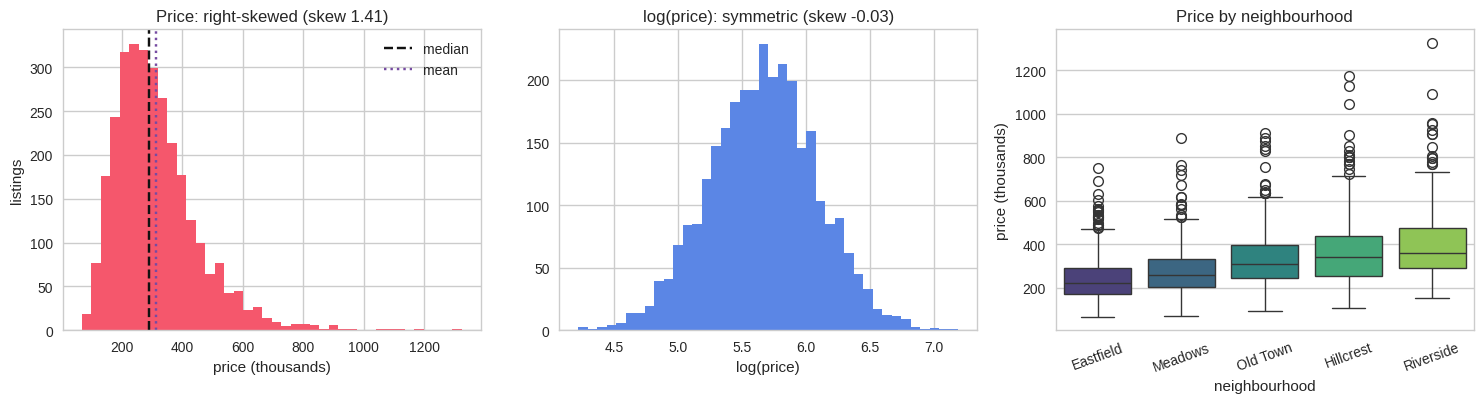

median price by neighbourhood (thousands): {'Eastfield': 223.0, 'Meadows': 260.0, 'Old Town': 308.0, 'Hillcrest': 343.0, 'Riverside': 360.0}


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(houses["price_k"], bins=40, color="#f5576c"); axes[0].axvline(houses["price_k"].median(), color="k", ls="--", label="median"); axes[0].axvline(houses["price_k"].mean(), color="#764ba2", ls=":", label="mean")
axes[0].set_xlabel("price (thousands)"); axes[0].set_ylabel("listings"); axes[0].set_title(f"Price: right-skewed (skew {houses.price_k.skew():.2f})"); axes[0].legend()
axes[1].hist(np.log(houses["price_k"]), bins=40, color="#5b86e5"); axes[1].set_xlabel("log(price)"); axes[1].set_title(f"log(price): symmetric (skew {np.log(houses.price_k).skew():.2f})")
order = houses.groupby("neighbourhood")["price_k"].median().sort_values().index
sns.boxplot(data=houses, x="neighbourhood", y="price_k", order=order, ax=axes[2], palette="viridis"); axes[2].set_title("Price by neighbourhood"); axes[2].set_ylabel("price (thousands)"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print("median price by neighbourhood (thousands):", houses.groupby("neighbourhood")["price_k"].median().round(0).sort_values().to_dict())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the raw price has a long right tail; the mean sits to the right of the median because a few expensive homes pull it. Middle: the logarithm of the same prices is close to symmetric, which is the signature of a log-normal target and the reason a target transform is worth trying. Right: neighbourhood shifts the whole distribution, and the spread grows with the level, so errors in currency will be larger in the expensive areas even if errors in percent are the same.

**The common misread:** reading the neighbourhood boxplot as "the model only needs neighbourhood". The boxes overlap; within one area, size and condition move the price as much as the area does between areas.

</div>


## 4.3 💻 One-line calls

Same shape, new module. `RegressionExperiment().setup(...)` gets the same housekeeping arguments; `compare_models` sorts by `MAE` because "typical error in thousands" is what the agency will ask for.


In [ ]:
train_houses, test_houses = train_test_split(houses, test_size=0.3, random_state=RANDOM_STATE)
train_houses, test_houses = train_houses.reset_index(drop=True), test_houses.reset_index(drop=True)

sig = inspect.signature(RegressionExperiment.setup).parameters
assert {"transform_target", "transform_target_method", "test_data", "index"} <= set(sig), "argument names changed"
print("transform_target default:", sig["transform_target"].default, "| transform_target_method default:", sig["transform_target_method"].default)

INCLUDE_REG = ["lr", "ridge", "rf", "et", "lightgbm", "gbr", "knn"]     # linear, ridge, two forests, two boosters, k-NN
exp_houses = RegressionExperiment()
with timer("setup (raw target)"):
    exp_houses.setup(train_houses, target="price_k", test_data=test_houses, index=False, transform_target=False,
                     session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)
s = exp_houses.pull().set_index("Description")["Value"]
for key in ["Target", "Target type", "Original data shape", "Transformed data shape", "Numeric features", "Categorical features", "Fold Generator"]:
    print(f"{key:>25}: {s[key]}")
with timer(f"compare_models: {len(INCLUDE_REG)} regressors x 3 folds"):
    best_houses = exp_houses.compare_models(include=INCLUDE_REG, fold=3, sort="MAE", verbose=False)
cmp_houses = exp_houses.pull()
print(cmp_houses.to_string())
print(f"\nwinner by MAE: {type(best_houses).__name__}")


transform_target default: False | transform_target_method default: yeo-johnson
⏱️ setup (raw target): 2.5 s
                   Target: price_k
              Target type: Regression
      Original data shape: (3000, 10)
   Transformed data shape: (3000, 14)
         Numeric features: 8
     Categorical features: 1
           Fold Generator: KFold
⏱️ compare_models: 7 regressors x 3 folds: 11.7 s
                                    Model      MAE         MSE      RMSE      R2   RMSLE    MAPE  TT (Sec)
gbr           Gradient Boosting Regressor  50.5647   4803.6636   69.2473  0.7394  0.2010  0.1668    0.3000
ridge                    Ridge Regression  50.5942   4712.4766   68.5671  0.7447  0.2302  0.1716    0.0633
lr                      Linear Regression  50.6096   4712.4604   68.5671  0.7447  0.2305  0.1717    0.0667
lightgbm  Light Gradient Boosting Machine  52.0475   5104.5450   71.3943  0.7219  0.2062  0.1711    0.6333
rf                Random Forest Regressor  53.8729   5444.2110   73

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 `transform_target`: learning on a log-like scale

`setup(transform_target=True)` adds a `target_transformation` step to the pipeline: a **Yeo-Johnson** power transform (a family of curves that includes the logarithm, with the curve chosen by maximum likelihood) is fitted to the training target, every model is trained on the transformed target, and `predict_model` inverts the transform so predictions and metrics come back in thousands. In PyCaret 3.3.2 the `transform_target_method` argument accepts `"yeo-johnson"` (the default) or `"quantile"`; there is no Box-Cox option. Least-squares models weight the expensive tail heavily on the raw scale; on the transformed scale a 10% error costs the same on a cheap house as on a dear one, which is usually what a valuation wants.

The next cell first shows the failure that motivates storing prices in thousands: PyCaret keeps the target as `float32`, and the Yeo-Johnson likelihood overflows on prices in full currency units, so `setup` raises before any model is trained. On `price_k` the same call works, and a side-by-side table shows what the transform changes.

</div>


In [ ]:
# the mistake: transform_target=True on a target in full currency units (float32 overflow inside the Yeo-Johnson fit)
dollars = train_houses.assign(price=train_houses["price_k"] * 1000).drop(columns=["price_k"])
try:
    RegressionExperiment().setup(dollars, target="price", transform_target=True, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)
    print("setup on prices in currency units: succeeded")
except Exception as e:  # noqa: BLE001 - the point is to show the failure
    print(f"setup on prices in currency units failed: {type(e).__name__}: {str(e)[:90]}")

# the fix: the target in thousands
exp_houses_tt = RegressionExperiment()
with timer("setup (transform_target=True, yeo-johnson) + compare_models"):
    exp_houses_tt.setup(train_houses, target="price_k", test_data=test_houses, index=False,
                        transform_target=True, transform_target_method="yeo-johnson",
                        session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)
    best_houses_tt = exp_houses_tt.compare_models(include=INCLUDE_REG, fold=3, sort="MAE", verbose=False)
cmp_houses_tt = exp_houses_tt.pull()
print("pipeline steps with transform_target:", [n for n, _ in exp_houses_tt.pipeline.steps])
y_raw, y_tf = exp_houses_tt.get_config("y_train"), exp_houses_tt.get_config("y_train_transformed")
print(f"training target: raw skew {y_raw.skew():.2f}  ->  transformed skew {y_tf.skew():.2f}")

tt_table = pd.DataFrame({"CV MAE, raw": cmp_houses["MAE"], "CV MAE, yeo-johnson": cmp_houses_tt["MAE"].reindex(cmp_houses.index),
                         "CV RMSLE, raw": cmp_houses["RMSLE"], "CV RMSLE, yeo-johnson": cmp_houses_tt["RMSLE"].reindex(cmp_houses.index)})
tt_table["MAE change"] = tt_table["CV MAE, yeo-johnson"] - tt_table["CV MAE, raw"]
tt_table["RMSLE change"] = tt_table["CV RMSLE, yeo-johnson"] - tt_table["CV RMSLE, raw"]
tt_table.index = cmp_houses["Model"]
print("\nper model, with and without the target transform (MAE in thousands; a negative change means the transform helped):")
pretty(tt_table, highlight="min", subset=["CV MAE, raw", "CV MAE, yeo-johnson", "CV RMSLE, raw", "CV RMSLE, yeo-johnson"])


setup on prices in currency units failed: BracketError: The algorithm terminated without finding a valid bracket. Consider trying different initia
⏱️ setup (transform_target=True, yeo-johnson) + compare_models: 13.8 s
pipeline steps with transform_target: ['target_transformation', 'numerical_imputer', 'categorical_imputer', 'onehot_encoding']
training target: raw skew 1.43  ->  transformed skew 0.00

per model, with and without the target transform (MAE in thousands; a negative change means the transform helped):


,"CV MAE, raw","CV MAE, yeo-johnson","CV RMSLE, raw","CV RMSLE, yeo-johnson",MAE change,RMSLE change
Model,,,,,,
Gradient Boosting Regressor,50.565,50.240,0.201,0.199,-0.325,-0.003
Ridge Regression,50.594,49.874,0.230,0.195,-0.720,-0.035
Linear Regression,50.610,49.873,0.231,0.195,-0.736,-0.035
Light Gradient Boosting Machine,52.047,51.189,0.206,0.203,-0.859,-0.003
Random Forest Regressor,53.873,53.299,0.216,0.213,-0.574,-0.003
Extra Trees Regressor,54.646,54.064,0.219,0.216,-0.583,-0.003
K Neighbors Regressor,84.778,84.293,0.345,0.343,-0.485,-0.002


## 4.4 📤 The output

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The regression compare table, column by column

| Column | Meaning | Reads |
|---|---|---|
| **MAE** | mean absolute error, in thousands | "typically off by this much"; robust to a few huge misses; the sort key here |
| **MSE** | mean squared error | in squared thousands, unreadable on its own; what least squares minimises |
| **RMSE** | root of MSE, back in thousands | always at least MAE; the gap between RMSE and MAE grows with a few large errors |
| **R2** | share of the price variance explained | 1 is perfect, 0 is "predict the mean"; unitless, so comparable across datasets |
| **RMSLE** | RMSE on `log(1 + y)` | a relative error: a miss of 20 on a 200 house counts like a miss of 100 on a 1,000 house |
| **MAPE** | mean absolute percentage error, as a fraction | the agency's language ("within 15%"); blows up when the target is near zero |
| **TT (Sec)** | training time per fold | the cost column |

`sort="MAE"` tells PyCaret that lower is better; it knows which of its metrics are errors. The table below is the raw-target run; `tt_table` above shows the transformed one side by side.

</div>


In [ ]:
pretty(cmp_houses.drop(columns=["Model"]), highlight="min", subset=["MAE", "MSE", "RMSE", "RMSLE", "MAPE"])


,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,50.565,4803.664,69.247,0.739,0.201,0.167,0.300
ridge,50.594,4712.477,68.567,0.745,0.230,0.172,0.063
lr,50.610,4712.460,68.567,0.745,0.231,0.172,0.067
lightgbm,52.047,5104.545,71.394,0.722,0.206,0.171,0.633
rf,53.873,5444.211,73.680,0.706,0.216,0.180,0.830
et,54.646,5563.587,74.456,0.699,0.219,0.184,0.787
knn,84.778,12579.308,111.985,0.320,0.345,0.301,0.073


`predict_model` on a regression experiment appends one column, `prediction_label` (the name is shared with the classification module; here it holds the predicted price in thousands). The table below scores five held-out houses with both experiments and adds the error columns by hand; `report_card(task="regression")` then gives both models the same metric row on the whole held-out set, with two extras the compare table lacks: `MedAE` (the median absolute error, blind to a few huge misses) and `bias` (the mean signed error: positive means the model predicts too low on average).


In [ ]:
pred_houses = exp_houses.predict_model(best_houses, data=test_houses, verbose=False)
pred_houses_tt = exp_houses_tt.predict_model(best_houses_tt, data=test_houses, verbose=False)

five = test_houses.head(5)[["neighbourhood", "sqft", "bedrooms", "age_years", "condition", "price_k"]].copy()
five["pred (raw)"] = pred_houses["prediction_label"].head(5).values
five["pred (yeo-johnson)"] = pred_houses_tt["prediction_label"].head(5).values
five["error (raw)"] = five["pred (raw)"] - five["price_k"]
five["error %"] = 100 * five["error (raw)"] / five["price_k"]
print("five held-out listings (thousands):")
display(five.round(1))

cards_houses = pd.concat([report_card(pred_houses["price_k"], pred_houses["prediction_label"], name=f"{type(best_houses).__name__} (raw target)", task="regression"),
                          report_card(pred_houses_tt["price_k"], pred_houses_tt["prediction_label"], name=f"{type(best_houses_tt).__name__} (yeo-johnson target)", task="regression"),
                          report_card(pred_houses["price_k"], np.full(len(pred_houses), train_houses["price_k"].mean()), name="always the training mean (baseline)", task="regression")])
print("\nheld-out report cards (thousands):")
pretty(cards_houses, fmt="{:.2f}", highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%"])


five held-out listings (thousands):


,neighbourhood,sqft,bedrooms,age_years,condition,price_k,pred (raw),pred (yeo-johnson),error (raw),error %
0,Eastfield,1570.0,3,48,3,183.9,210.2,193.5,26.3,14.3
1,Hillcrest,2040.0,3,7,3,524.7,463.2,465.7,-61.5,-11.7
2,Hillcrest,2440.0,3,84,2,313.7,389.2,338.1,75.5,24.1
3,Meadows,2290.0,4,85,4,380.4,299.6,283.8,-80.8,-21.2
4,Riverside,2020.0,4,13,4,519.9,499.2,510.2,-20.7,-4.0



held-out report cards (thousands):


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
GradientBoostingRegressor (raw target),47.94,65.48,35.12,15.80,0.79,1.04
LinearRegression (yeo-johnson target),47.97,67.42,33.65,15.38,0.78,5.62
always the training mean (baseline),108.07,142.60,90.50,41.04,-0.00,-2.08


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Judge `transform_target` on the inverted scale, and not by reflex

`tt_table` shows the transform lowered the cross-validated MAE by a small amount for every model, and where the real change is: RMSLE, the relative error, dropped clearly for the linear models and barely moved for the trees. Trees split the target wherever it lies, so a monotone transform changes little for them, while a linear model fitted on the log-like scale stops being pulled by the expensive tail. Both report cards are in thousands because `predict_model` inverted the transform; a model that looks better on the transformed scale and worse on the inverted one is worse. Read the `bias` column too: the transformed model's bias is positive (it predicts low on average) because inverting the transform of an average lands nearer the median than the mean, a known side effect called retransformation bias; the raw model is nearly unbiased. And the flag has a cost: on a target in full currency units the fit crashed outright. Use it when the target spans orders of magnitude or the residuals grow with the prediction; check the report card either way.

</div>


## 4.5 📊 The picture

The regression gallery has its own plots. `residuals` (residual against predicted value, train and held-out in two colours, with a histogram) and `error` (predicted against actual with the identity line) are the two to look at first; both through `render_grid`.


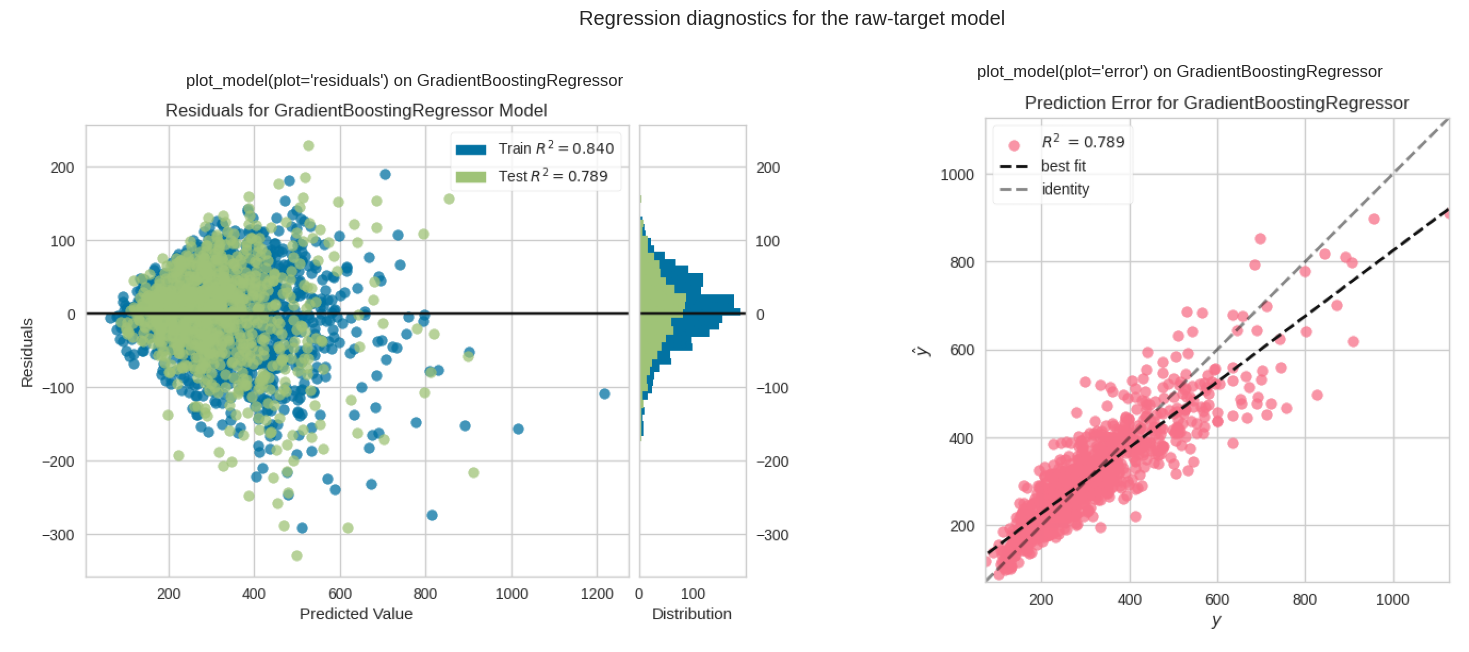

⏱️ residuals + error: 2.8 s
saved: ['Residuals.png', 'Prediction Error.png']


In [ ]:
with timer("residuals + error"):
    reg_files = render_grid([(f"plot_model(plot='residuals') on {type(best_houses).__name__}", lambda **k: exp_houses.plot_model(best_houses, plot="residuals", verbose=False, **k), None),
                             (f"plot_model(plot='error') on {type(best_houses).__name__}", lambda **k: exp_houses.plot_model(best_houses, plot="error", verbose=False, **k), None)],
                            ncols=2, figsize=(16, 6.5), suptitle="Regression diagnostics for the raw-target model")
print("saved:", [os.path.basename(p) for p in reg_files])


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, **residuals**: the cloud should be a flat band around zero. Here it fans out to the right: errors grow with the predicted price, which is what a multiplicative (log-normal) target does to a model fitted on the raw scale, and the reason the transformed model's RMSLE was better. The train and held-out clouds look alike, so the model is not memorising. Right, **prediction error**: predicted against actual with the identity line and the best-fit line; where the fit line bends away from the identity at the high end, expensive homes are under-predicted.

**The common misread:** treating a symmetric residual histogram as "the errors are fine". The histogram on the right of the residual plot pools every price level; the fan in the scatter shows the errors are not the same size everywhere, and the boxplot below shows they are not the same size in every neighbourhood.

</div>


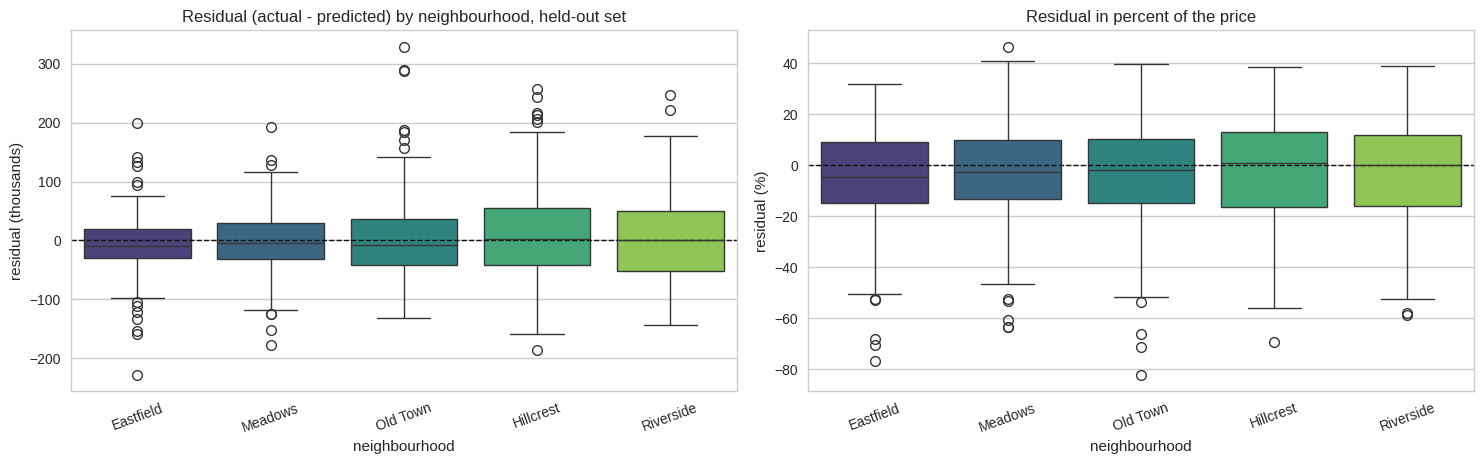

held-out report card by neighbourhood (thousands):
               MAE  RMSE  MedAE  MAPE_%   R2  bias
model                                             
Eastfield     35.3  48.9   25.5    15.1  0.7  -8.7
Hillcrest     59.4  78.5   45.4    16.6  0.7   9.9
Meadows       39.3  52.4   30.6    15.1  0.8  -1.8
Old Town      51.8  71.8   38.1    16.3  0.7   3.5
Riverside     60.8  76.8   52.6    16.3  0.8   6.6
all listings  47.9  65.5   35.1    15.8  0.8   1.0


In [ ]:
resid = pd.DataFrame({"neighbourhood": pred_houses["neighbourhood"].values, "price_k": pred_houses["price_k"].values,
                      "predicted": pred_houses["prediction_label"].values})
resid["residual"] = resid["price_k"] - resid["predicted"]
resid["residual %"] = 100 * resid["residual"] / resid["price_k"]
seg = pd.concat([report_card(g["price_k"], g["predicted"], name=h, task="regression") for h, g in resid.groupby("neighbourhood")]
                + [report_card(resid["price_k"], resid["predicted"], name="all listings", task="regression")])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sns.boxplot(data=resid, x="neighbourhood", y="residual", order=order, ax=axes[0], palette="viridis"); axes[0].axhline(0, color="k", lw=1, ls="--")
axes[0].set_title("Residual (actual - predicted) by neighbourhood, held-out set"); axes[0].set_ylabel("residual (thousands)"); axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=resid, x="neighbourhood", y="residual %", order=order, ax=axes[1], palette="viridis"); axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_title("Residual in percent of the price"); axes[1].set_ylabel("residual (%)"); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print("held-out report card by neighbourhood (thousands):")
print(seg.round(1).to_string())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: residuals in thousands by neighbourhood, ordered from the cheapest area to the dearest. The boxes widen from left to right: the same model is less precise, in currency, where houses cost more. Right: the same residuals as a percentage of the price; the boxes are now about the same width, which says the model's error is roughly proportional to the price. The report card underneath puts numbers on both views (MAE grows by area, MAPE stays about flat), and the `bias` column shows whether any area is systematically over- or under-valued.

**The common misread:** reading the widest box as "the model is bad in that neighbourhood". In currency it is; in percent it is not. Which one matters depends on who pays for the error, and the agency should be asked, not assumed.

</div>


## 4.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ `pycaret.regression` for a numeric target

**Reach for it when** the answer is a number (a price, a demand, a duration, a spend) and the data is a table with that number as a column. The calls mirror the classification module; only the metrics and the gallery differ. **What it costs:** the same as classification; the two `setup` + `compare_models` runs here took well under a minute together. **The one gotcha:** a skewed target. Try `transform_target=True` when the target spans orders of magnitude or the residual plot fans out, keep the target in sensible units (thousands, not units) so the transform can be fitted, and judge the result by the report card in the original units.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: report MAE and MAPE together, and always against a baseline

MAE is in the target's units and MAPE in percent; a stakeholder needs both. The "always the training mean" row in the report card is the floor: a model whose MAE is not far below it has learned little, whatever its R² says. Part 8 uses the same two numbers (as MASE and SMAPE) for forecasts.

</div>


## 4.7 Task 4 Summary

**✅ Key Takeaways**
- `RegressionExperiment` uses the same grammar; `setup` infers `Regression` from a numeric target and `compare_models(sort="MAE")` ranks by typical error in the target's units.
- MAE, RMSE and MedAE are in the target's units; R² is unitless; RMSLE and MAPE are relative errors. Report an absolute and a relative one together.
- `transform_target=True` fits a Yeo-Johnson transform (or `"quantile"`; no Box-Cox in 3.3.2) on the training target and inverts it in `predict_model`; it trimmed MAE slightly everywhere and cut the linear models' relative error most.
- PyCaret stores the target as float32, so a target in full currency units can overflow the transform; keep it in thousands.
- The residual plot and a residual-by-segment boxplot show where the error lives; errors proportional to the price are a different problem from errors concentrated in one area.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_houses`, `houses`, `train_houses`, `test_houses`, `order` | the generator, the table, the split, and the neighbourhoods ordered by median price |
| `INCLUDE_REG`, `exp_houses`, `best_houses`, `cmp_houses` | the model list, the raw-target experiment, its MAE winner and compare table |
| `exp_houses_tt`, `best_houses_tt`, `cmp_houses_tt`, `tt_table` | the `transform_target=True` experiment, its winner and table, and the side-by-side MAE comparison |
| `pred_houses`, `pred_houses_tt`, `five`, `cards_houses` | the scored held-out frames, the five-house table, and the report cards with a baseline |
| `reg_files`, `resid`, `seg` | the two diagnostic PNGs, the residual frame, and the per-neighbourhood report card |

**➡️ Next Up:** Part 4 — back to the churn model to squeeze it: `tune_model`, `ensemble_model`, `blend_models`, `stack_models`, one call each.


# Part 4 · Tune, Ensemble, Blend, Stack ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

`compare_models` picks a model. This Part shows the six calls that make a picked model **better**, one line each: `tune_model` (better hyperparameters), `ensemble_model` (bagging and boosting of one model), `blend_models` and `stack_models` (combinations of different models), `calibrate_model` (probabilities that mean what they say) and `optimize_threshold` (the cut-off chosen for a metric instead of left at 0.5). Every call returns a fitted model and leaves its cross-validation table in `pull()`, so the whole chain can be summarised in one table and one bar chart.

</div>

# Task 5 · Six one-liners that improve a model

## 4.1 ❓ The problem

A telecom's retention team has a churn model from Part 1 and one question: **is this as good as it gets?** Every tenth of AUC is customers they can call before they leave. The honest answer needs three separate experiments: can the same model be *tuned*, can several models be *combined*, and can the *decision* (the probability and the cut-off) be improved without touching the ranking. PyCaret makes each of those one call.


## 4.2 📥 The input

The same churn table Part 1 used, regenerated here so this Part runs on its own: seven columns about a customer and a `churned` label. A 75/25 split is made **outside** PyCaret and handed to `setup` through `test_data=`, so every held-out number in this Part is on the same 750 customers.


📥 telecom churn: 3,000 rows x 8 columns | label = 'churned'


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,churned
0,7,104.99,one year,credit card,2,False,286.9,1
1,56,81.04,two year,bank transfer,1,False,429.5,0
2,48,65.01,month-to-month,e-check,2,True,31.9,1
3,32,52.00,month-to-month,bank transfer,3,True,302.3,1
4,32,76.34,two year,credit card,1,False,207.1,0


column types: {'tenure_months': 'numeric', 'monthly_charge': 'numeric', 'contract': 'text/category', 'payment_method': 'text/category', 'num_support_calls': 'numeric', 'streaming': 'boolean', 'total_gb': 'numeric', 'churned': 'numeric'}
label distribution: {0: 0.747, 1: 0.253}


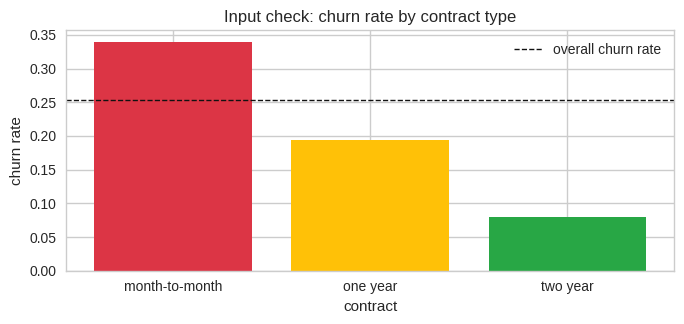

train 2,250 rows | held-out test 750 rows | churn rate 25.3%


In [ ]:
def make_churn(n=3000, seed=RANDOM_STATE):
    # A compact telecom churn table with planted structure: short tenure, month-to-month contracts,
    # e-check payments and support calls push churn up; long contracts and streaming pull it down.
    rng = np.random.default_rng(seed)
    tenure = rng.integers(1, 73, n)
    contract = rng.choice(["month-to-month", "one year", "two year"], n, p=[0.55, 0.25, 0.20])
    payment = rng.choice(["credit card", "bank transfer", "e-check", "mailed check"], n, p=[0.30, 0.25, 0.30, 0.15])
    streaming = rng.random(n) < 0.45
    charge = np.clip(rng.normal(65, 20, n) + 15 * streaming, 20, 130).round(2)
    calls = rng.poisson(1.2, n)
    gb = (rng.gamma(2.0, 120, n) * (1 + 0.8 * streaming)).round(1)
    logit = (-1.45 - 0.035 * tenure + 0.02 * (charge - 65) + 0.45 * calls
             + np.select([contract == "month-to-month", contract == "one year"], [1.2, 0.2], -0.8)
             + 0.5 * (payment == "e-check") - 0.2 * streaming)
    churned = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return pd.DataFrame({"tenure_months": tenure, "monthly_charge": charge, "contract": contract, "payment_method": payment,
                         "num_support_calls": calls, "streaming": streaming, "total_gb": gb, "churned": churned})

churn = make_churn(3000)
churn_train, churn_test = train_test_split(churn, test_size=0.25, stratify=churn["churned"], random_state=RANDOM_STATE)
churn_train, churn_test = churn_train.reset_index(drop=True), churn_test.reset_index(drop=True)
show_input(churn, label="churned", name="telecom churn")

fig, ax = plt.subplots(figsize=(7, 3.4))
rate = churn.groupby("contract")["churned"].mean().sort_values(ascending=False)
ax.bar(rate.index, rate.values, color=["#dc3545", "#ffc107", "#28a745"])
ax.axhline(churn["churned"].mean(), color="k", ls="--", lw=1, label="overall churn rate")
ax.set_ylabel("churn rate"); ax.set_xlabel("contract"); ax.set_title("Input check: churn rate by contract type"); ax.legend()
plt.tight_layout(); plt.show()
print(f"train {len(churn_train):,} rows | held-out test {len(churn_test):,} rows | churn rate {churn['churned'].mean():.1%}")


| Column | Type | Meaning |
|---|---|---|
| `tenure_months` | numeric | months since sign-up |
| `monthly_charge` | numeric | the monthly bill |
| `contract` | category | month-to-month, one year, two year |
| `payment_method` | category | credit card, bank transfer, e-check, mailed check |
| `num_support_calls` | numeric | support calls in the last quarter |
| `streaming` | boolean | has the streaming add-on |
| `total_gb` | numeric | data used last month |
| `churned` | **label** | 1 if the customer left |

`setup()` infers a **binary** target, two categorical columns to one-hot encode, one boolean and four numeric columns. The bar chart is the planted structure showing through: month-to-month contracts churn far more than two-year ones.

## 4.3 💻 One-line calls

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What each call does

| Call | What changes | Cost |
|---|---|---|
| `tune_model(m, n_iter=10, optimize="AUC", choose_better=True)` | draws 10 random hyperparameter sets from PyCaret's grid for that model, cross-validates each, keeps the best; returns the **original** if none beats it | `n_iter × fold` fits |
| `ensemble_model(m, method="Bagging")` | 10 copies of `m` on bootstrap samples, probabilities averaged | 10 × one fit, per fold |
| `ensemble_model(m, method="Boosting")` | AdaBoost: 10 copies, each fit on the previous one's mistakes | 10 × one fit, per fold |
| `blend_models([a, b, c], method="soft")` | averages the probabilities of different models | sum of the members |
| `stack_models([a, b, c], meta_model=lr)` | a meta-model learns weights from the members' out-of-fold predictions | members × `meta_model_fold` extra fits |
| `calibrate_model(m, method="sigmoid")` | wraps `m` so its probabilities match observed rates | `calibrate_fold` refits |
| `optimize_threshold(m, optimize="F1")` | searches the cut-off that maximises a metric under cross-validation | one CV per threshold tried |

**Hyperparameters** are the settings chosen before training (number of trees, depth, learning rate); **parameters** are what training learns. All the calls take `fold=` and leave their table in `pull()`.

</div>

The first call pair: a plain LightGBM, then `tune_model` on it. `return_tuner=True` also returns the scikit-learn searcher so `best_params_` can be printed.


In [ ]:
import inspect
assert {"n_iter", "optimize", "choose_better", "return_tuner"} <= set(inspect.signature(ClassificationExperiment.tune_model).parameters)

exp4 = ClassificationExperiment()
with timer("setup"):
    exp4.setup(churn_train, target="churned", test_data=churn_test, index=False,
               session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)

with timer("create_model('lightgbm')"):
    lgbm = exp4.create_model("lightgbm", fold=3, verbose=False)
lgbm_cv = exp4.pull()
print("LightGBM, per fold (pull()):"); print(lgbm_cv[["AUC", "F1", "Recall", "Prec."]].round(4).to_string())

with timer("tune_model: n_iter=10 x 3 folds"):
    lgbm_t, tuner = exp4.tune_model(lgbm, n_iter=10, fold=3, optimize="AUC", choose_better=True, return_tuner=True, verbose=False)
tuned_cv = exp4.pull()
print("\nbest of the 10 draws, per fold (pull()):"); print(tuned_cv[["AUC", "F1", "Recall", "Prec."]].round(4).to_string())
kept_original = lgbm_t is lgbm or lgbm_t.get_params() == lgbm.get_params()
print("\nsearch winner:", tuner.best_params_)
print("returned model:", "the ORIGINAL (choose_better kept it: the search lost on CV AUC)" if kept_original else "the tuned model")


⏱️ setup: 1.3 s
⏱️ create_model('lightgbm'): 5.1 s
LightGBM, per fold (pull()):
         AUC      F1  Recall   Prec.
Fold                                
0     0.7358  0.4807  0.4286  0.5473
1     0.7496  0.4272  0.3474  0.5546
2     0.7734  0.4808  0.3947  0.6148
Mean  0.7529  0.4629  0.3902  0.5722
Std   0.0155  0.0252  0.0333  0.0302
⏱️ tune_model: n_iter=10 x 3 folds: 16.4 s

best of the 10 draws, per fold (pull()):
         AUC      F1  Recall   Prec.
Fold                                
0     0.7604  0.4203  0.3280  0.5849
1     0.7459  0.3851  0.3000  0.5377
2     0.7899  0.4061  0.2789  0.7465
Mean  0.7654  0.4039  0.3023  0.6230
Std   0.0183  0.0145  0.0201  0.0894

search winner: {'actual_estimator__reg_lambda': 0.001, 'actual_estimator__reg_alpha': 2, 'actual_estimator__num_leaves': 40, 'actual_estimator__n_estimators': 130, 'actual_estimator__min_split_gain': 0.9, 'actual_estimator__min_child_samples': 86, 'actual_estimator__learning_rate': 0.05, 'actual_estimator__feature_

Next, the four combination calls. `ensemble_model` is shown on a **shallow** decision tree (`max_depth=3`, the textbook weak learner) where bagging and boosting help most; `blend_models` and `stack_models` combine three *different* models (a linear one, a bagged forest and the tuned LightGBM). A small helper records the `Mean` row of each `pull()` so the whole chain ends up in one table. The last two lines of the cell boost a *full-depth* tree as well, for the warning below.

**Stacking, as a diagram**

```
                     out-of-fold predictions (meta_model_fold=3)
   features ──►  lr    ──► P_lr(churn)   ─┐
   features ──►  rf    ──► P_rf(churn)   ─┼──►  meta-model lr  ──► final P(churn)
   features ──►  lgbm  ──► P_lgbm(churn) ─┘    learns one weight per member
```

Out-of-fold matters: the meta-model must see member predictions on rows the members did **not** train on, or it learns to trust an over-fitted member.


In [ ]:
def cv_row(step, base):
    # the Mean row of the last pull(), as one record for the step table
    r = exp4.pull().loc["Mean"]
    return {"step": step, "base": base, "CV AUC": r["AUC"], "CV F1": r["F1"], "CV Recall": r["Recall"], "CV Prec.": r["Prec."]}

steps = []
_ = exp4.create_model(lgbm, fold=3, verbose=False);      steps.append(cv_row("single", "lightgbm"))
_ = exp4.create_model(lgbm_t, fold=3, verbose=False);    steps.append(cv_row("tuned", "lightgbm"))
with timer("shallow decision tree: single, bagged, boosted"):
    dt = exp4.create_model("dt", max_depth=3, fold=3, verbose=False);               steps.append(cv_row("single", "tree (depth 3)"))
    dt_bag = exp4.ensemble_model(dt, method="Bagging", fold=3, verbose=False);      steps.append(cv_row("bagged x10", "tree (depth 3)"))
    dt_boost = exp4.ensemble_model(dt, method="Boosting", fold=3, verbose=False);   steps.append(cv_row("boosted x10", "tree (depth 3)"))
with timer("members, blend, stack"):
    lr = exp4.create_model("lr", fold=3, verbose=False)
    rf = exp4.create_model("rf", fold=3, verbose=False)
    blended = exp4.blend_models([lr, rf, lgbm_t], method="soft", fold=3, verbose=False);                    steps.append(cv_row("blended soft", "lr + rf + lightgbm"))
    stacked = exp4.stack_models([lr, rf, lgbm_t], meta_model=lr, meta_model_fold=3, fold=3, verbose=False); steps.append(cv_row("stacked -> lr", "lr + rf + lightgbm"))
step_table = pd.DataFrame(steps).set_index(["base", "step"])
print(type(dt_bag).__name__, "|", type(dt_boost).__name__, "|", type(blended).__name__, "|", type(stacked).__name__)
print(step_table.round(4).to_string())

# the warning's evidence: AdaBoost on a full-depth tree, which has no training mistakes left to reweight
dt_full = exp4.create_model("dt", fold=3, verbose=False); auc_full = exp4.pull().loc["Mean", "AUC"]
_ = exp4.ensemble_model(dt_full, method="Boosting", fold=3, verbose=False); auc_full_boost = exp4.pull().loc["Mean", "AUC"]
print(f"\nfull-depth tree: CV AUC {auc_full:.4f} -> boosted x10 {auc_full_boost:.4f} (gain {auc_full_boost - auc_full:+.4f})"
      f"   vs depth-3 tree: {step_table.loc[('tree (depth 3)', 'single'), 'CV AUC']:.4f} -> {step_table.loc[('tree (depth 3)', 'boosted x10'), 'CV AUC']:.4f}")


⏱️ shallow decision tree: single, bagged, boosted: 3.2 s
⏱️ members, blend, stack: 19.5 s
BaggingClassifier | AdaBoostClassifier | VotingClassifier | StackingClassifier
                                  CV AUC   CV F1  CV Recall  CV Prec.
base               step                                              
lightgbm           single         0.7529  0.4629     0.3902    0.5722
                   tuned          0.7654  0.4039     0.3023    0.6230
tree (depth 3)     single         0.6972  0.3095     0.2685    0.4854
                   bagged x10     0.7360  0.3265     0.2215    0.6388
                   boosted x10    0.7194  0.4277     0.3603    0.5278
lr + rf + lightgbm blended soft   0.7798  0.4150     0.3077    0.6536
                   stacked -> lr  0.7815  0.4230     0.3164    0.6512

full-depth tree: CV AUC 0.6092 -> boosted x10 0.6222 (gain +0.0130)   vs depth-3 tree: 0.6972 -> 0.7194


The last two calls change the **decision**, not the ranking. `calibrate_model` wraps the model in scikit-learn's `CalibratedClassifierCV` (`"sigmoid"` = Platt scaling, two parameters, safe on small data; `"isotonic"` = a free-form monotone step function that needs more rows). It is applied to both the default and the tuned LightGBM, because the two react differently. `optimize_threshold` runs one full cross-validation per cut-off that scipy's SHGO optimiser tries; the cell keeps SHGO's budget small through `**shgo_kwargs` and asks for `return_data=True` so the curve can be redrawn with matplotlib (the built-in chart is plotly, which needs a browser).


In [ ]:
from sklearn.calibration import calibration_curve
import plotly.graph_objects as go
from contextlib import contextmanager

@contextmanager
def quiet_plotly():
    # optimize_threshold ends with fig.show(); in a plain-python run that would try to open a browser
    original = go.Figure.show; go.Figure.show = lambda self, *a, **k: None
    try:
        yield
    finally:
        go.Figure.show = original

with timer("calibrate_model('sigmoid') x2"):
    lgbm_cal = exp4.calibrate_model(lgbm, method="sigmoid", calibrate_fold=3, fold=3, verbose=False)
    lgbm_t_cal = exp4.calibrate_model(lgbm_t, method="sigmoid", calibrate_fold=3, fold=3, verbose=False)
print(type(lgbm_cal).__name__, "wrapping", type(lgbm_cal.estimator).__name__)

def holdout(model, **kw):
    # (y_true, predicted label, P(churn)) on the experiment's held-out set (= churn_test)
    p = exp4.predict_model(model, raw_score=True, verbose=False, **kw)
    return p["churned"].values, p["prediction_label"].values, p["prediction_score_1"].values

cal_probs, cards = {}, []
for name, m in [("default lightgbm", lgbm), ("default, sigmoid-calibrated", lgbm_cal),
                ("tuned lightgbm", lgbm_t), ("tuned, sigmoid-calibrated", lgbm_t_cal)]:
    y_ho, lab, p = holdout(m); cal_probs[name] = p
    cards.append(report_card(y_ho, lab, p, name=name))
cal_table = pd.concat(cards)
print("\nheld-out set, before and after calibration (lower log_loss / brier = better probabilities):")
print(cal_table[["roc_auc", "pr_auc", "log_loss", "brier"]].round(4).to_string())

with timer("optimize_threshold(optimize='F1'), bounded SHGO"), quiet_plotly():
    thr_data, lgbm_thr = exp4.optimize_threshold(lgbm_t, optimize="F1", return_data=True, verbose=False,
                                                 n=8, options={"maxiter": 1, "f_tol": 1e-2},
                                                 minimizer_kwargs={"options": {"maxiter": 3, "ftol": 1e-2}})
t_f1 = float(lgbm_thr.probability_threshold)
print(f"\n{type(lgbm_thr).__name__}: probability_threshold = {t_f1:.3f}  ({thr_data['probability_threshold'].nunique()} thresholds tried, one 3-fold CV each)")


⏱️ calibrate_model('sigmoid') x2: 4.7 s
CalibratedClassifierCV wrapping LGBMClassifier
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value

## 4.4 📤 The output

Three tables come out of the chain. The **step table** is the `Mean` row of every `pull()`, one row per call. The **calibration table** (printed in 4.3) is `report_card` on the held-out set before and after `calibrate_model`. The **held-out report** below scores the tuned model at the default 0.5 cut-off and at the F1-optimal one; the thresholded classifier is the same model with a stored cut-off that `predict_model`, `finalize_model` and `save_model` all respect.


In [ ]:
print("step table (cross-validated, mean of 3 folds):")
display(pretty(step_table))

_, lab_t, p_t = holdout(lgbm_t)
_, lab_thr, p_thr = holdout(lgbm_thr)
final_card = pd.concat([report_card(y_ho, lab_t, p_t, name="tuned lightgbm @ default 0.50"),
                        report_card(y_ho, lab_thr, p_thr, name=f"tuned lightgbm @ F1-optimal {t_f1:.2f}")])
print("\nheld-out report_card, same model, two cut-offs:")
display(pretty(final_card[["accuracy", "balanced_acc", "precision", "recall", "f1", "mcc", "roc_auc", "pr_auc"]]))
print(f"flagged customers at 0.50: {int(lab_t.sum())}   at {t_f1:.2f}: {int(lab_thr.sum())}   (of {len(y_ho)} held-out, {int(y_ho.sum())} churners)")


step table (cross-validated, mean of 3 folds):


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will b

,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc
model,,,,,,,,
tuned lightgbm @ default 0.50,0.785,0.653,0.619,0.386,0.476,0.365,0.811,0.562
tuned lightgbm @ F1-optimal 0.25,0.727,0.747,0.475,0.788,0.592,0.435,0.811,0.562


flagged customers at 0.50: 118   at 0.25: 314   (of 750 held-out, 189 churners)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📤 Reading the tables

- **Step table.** Every number is cross-validation on the training partition; the held-out set is untouched until `predict_model`. Compare rows within one `base`: `single → tuned` for LightGBM, `single → bagged → boosted` for the shallow tree. The blend and stack rows are a third base (three members) and are read against the best single member. Notice that tuning for `optimize="AUC"` raised the LightGBM AUC while its F1 at the 0.5 cut-off *fell*: the tuned model is more regularised, its probabilities are more compressed, fewer customers cross 0.5, so recall drops. A ranking metric and a label metric can move in opposite directions.
- **Calibration table.** Compare each raw row with the calibrated one under it. The default LightGBM (100 trees on 2,250 rows) is over-confident and gains a lower log loss and Brier from calibration; the tuned model is already regularised and gains nothing or slightly loses. `roc_auc` barely moves in either pair.
- **Held-out report.** `roc_auc` and `pr_auc` are identical in both rows because moving the threshold does not reorder customers. What moves is `recall` versus `precision`, and with them `f1` and the number of customers flagged.

**The common misread:** ranking the step table by `CV AUC` across bases and calling the top row "the best model". A bagged tree and a tuned LightGBM sit in different noise bands (the per-fold picture below shows how wide), and the stack costs four models at prediction time for whatever it gains.

</div>

## 4.5 📊 The picture


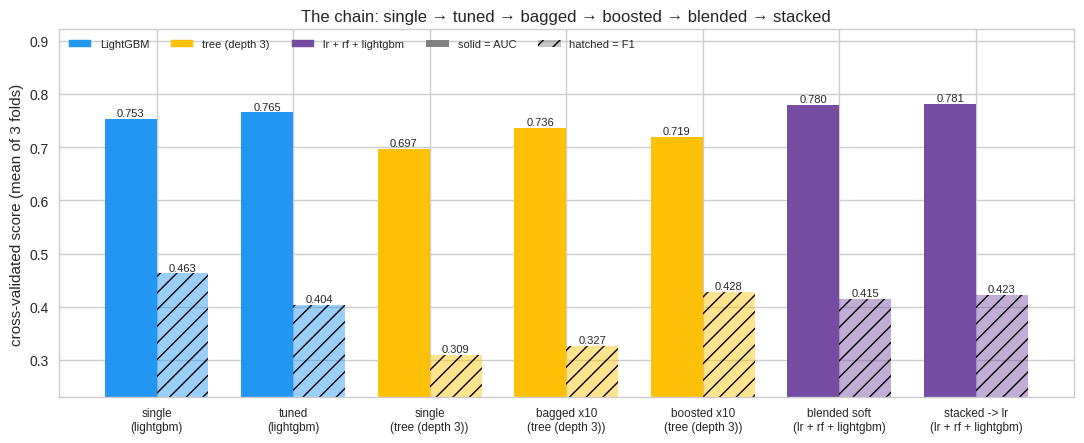

AUC gain: bagging the tree +0.039 | boosting it +0.022 | tuning LightGBM +0.012 | blend over the best single model +0.014


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.6))
labels = [f"{s}\n({b})" for b, s in step_table.index]
palette = {"lightgbm": "#2196F3", "tree (depth 3)": "#ffc107", "lr + rf + lightgbm": "#764ba2"}
colors = [palette[b] for b, _ in step_table.index]
x = np.arange(len(step_table)); w = 0.38
ax.bar(x - w / 2, step_table["CV AUC"], w, color=colors, label="CV AUC")
ax.bar(x + w / 2, step_table["CV F1"], w, color=colors, alpha=0.45, hatch="//", label="CV F1")
for i, (a, f) in enumerate(zip(step_table["CV AUC"], step_table["CV F1"])):
    ax.text(i - w / 2, a + 0.005, f"{a:.3f}", ha="center", fontsize=8); ax.text(i + w / 2, f + 0.005, f"{f:.3f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(min(step_table["CV F1"].min(), step_table["CV AUC"].min()) - 0.08, step_table["CV AUC"].max() + 0.14)
ax.set_ylabel("cross-validated score (mean of 3 folds)"); ax.set_title("The chain: single → tuned → bagged → boosted → blended → stacked")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2196F3", label="LightGBM"), Patch(color="#ffc107", label="tree (depth 3)"), Patch(color="#764ba2", label="lr + rf + lightgbm"),
                   Patch(facecolor="gray", label="solid = AUC"), Patch(facecolor="gray", alpha=0.45, hatch="//", label="hatched = F1")], loc="upper left", ncol=5, fontsize=8)
plt.tight_layout(); plt.show()
bag_gain = step_table.loc[("tree (depth 3)", "bagged x10"), "CV AUC"] - step_table.loc[("tree (depth 3)", "single"), "CV AUC"]
boost_gain = step_table.loc[("tree (depth 3)", "boosted x10"), "CV AUC"] - step_table.loc[("tree (depth 3)", "single"), "CV AUC"]
tune_gain = step_table.loc[("lightgbm", "tuned"), "CV AUC"] - step_table.loc[("lightgbm", "single"), "CV AUC"]
blend_gain = step_table.loc[("lr + rf + lightgbm", "blended soft"), "CV AUC"] - step_table["CV AUC"].iloc[:5].max()
print(f"AUC gain: bagging the tree {bag_gain:+.3f} | boosting it {boost_gain:+.3f} | tuning LightGBM {tune_gain:+.3f} | blend over the best single model {blend_gain:+.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Solid bars are AUC, hatched bars F1, one pair per step, coloured by base model. The big moves are inside the yellow group: a depth-3 tree ranks poorly and both bagging and boosting ten of them lift its AUC by the printed gains. The blue pair moves little from `single` to `tuned`: ten random draws rarely beat LightGBM's defaults by much. The purple pair sits at or just above the best single model: averaging three good models rarely hurts and rarely helps much either. Read the hatched bars separately: F1 is measured at the 0.5 cut-off and can fall while AUC rises.

**The common misread:** "ensembling does not work" from the top of the chart. It worked on the weak model; the ceiling near the top is the data, not the method.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Boosting needs a weak learner

The last line printed under the step table boosted a **full-depth** tree as well: it gained less than the depth-3 tree did, and ten boosted full-depth trees still rank below a *single* depth-3 tree. AdaBoost re-weights the rows the previous copy got wrong; a full-depth tree gets almost every training row right, so there is little to re-weight and the copies stay alike. Bagging has the opposite taste: it wants a jumpy, high-variance model, which a full-depth tree is. `ensemble_model(method="Boosting")` on a forest or on LightGBM is the same mistake in a different coat.

</div>


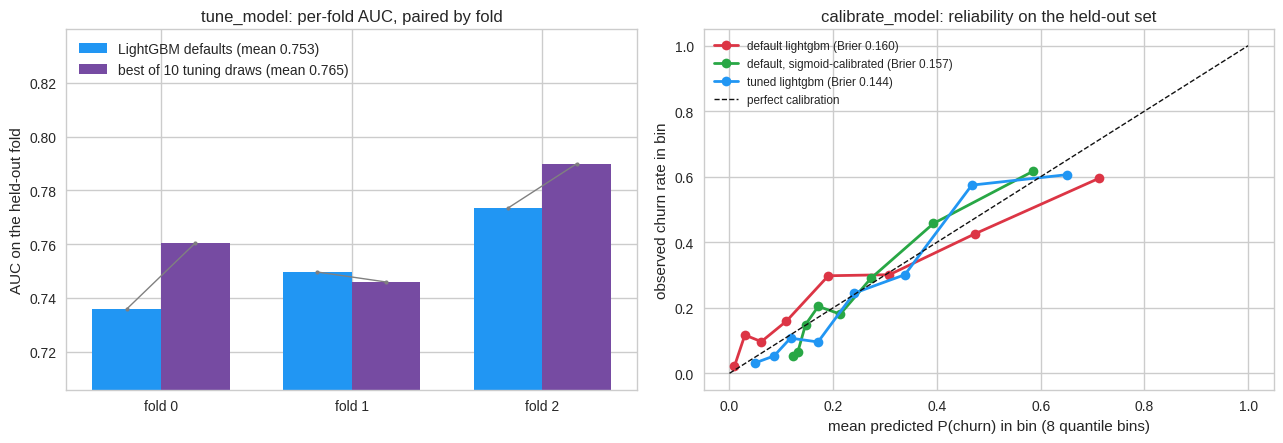

fold-to-fold std of the baseline AUC: 0.0190  |  mean gain from tuning: +0.0125
Brier, default lightgbm: 0.1598 -> calibrated 0.1573  |  tuned: 0.1444 -> calibrated 0.1469


In [ ]:
folds = np.arange(3)
before = lgbm_cv.iloc[:3]["AUC"].values; after = tuned_cv.iloc[:3]["AUC"].values
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
w = 0.36
axes[0].bar(folds - w / 2, before, w, color="#2196F3", label=f"LightGBM defaults (mean {before.mean():.3f})")
axes[0].bar(folds + w / 2, after, w, color="#764ba2", label=f"best of 10 tuning draws (mean {after.mean():.3f})")
for i in folds:
    axes[0].plot([i - w / 2, i + w / 2], [before[i], after[i]], color="gray", lw=1, marker="o", ms=3)
axes[0].set_xticks(folds); axes[0].set_xticklabels([f"fold {i}" for i in folds]); axes[0].set_ylabel("AUC on the held-out fold")
axes[0].set_ylim(min(before.min(), after.min()) - 0.03, max(before.max(), after.max()) + 0.05); axes[0].set_title("tune_model: per-fold AUC, paired by fold"); axes[0].legend(loc="upper left")

for name, color in [("default lightgbm", "#dc3545"), ("default, sigmoid-calibrated", "#28a745"), ("tuned lightgbm", "#2196F3")]:
    p = cal_probs[name]
    frac, mean_pred = calibration_curve(y_ho, p, n_bins=8, strategy="quantile")
    axes[1].plot(mean_pred, frac, marker="o", lw=2, color=color, label=f"{name} (Brier {brier_score_loss(y_ho, p):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[1].set(xlabel="mean predicted P(churn) in bin (8 quantile bins)", ylabel="observed churn rate in bin", title="calibrate_model: reliability on the held-out set")
axes[1].legend(loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()
print(f"fold-to-fold std of the baseline AUC: {before.std(ddof=1):.4f}  |  mean gain from tuning: {after.mean() - before.mean():+.4f}")
print(f"Brier, default lightgbm: {brier_score_loss(y_ho, cal_probs['default lightgbm']):.4f} -> calibrated {brier_score_loss(y_ho, cal_probs['default, sigmoid-calibrated']):.4f}"
      f"  |  tuned: {brier_score_loss(y_ho, cal_probs['tuned lightgbm']):.4f} -> calibrated {brier_score_loss(y_ho, cal_probs['tuned, sigmoid-calibrated']):.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: two bars per fold joined by a grey line. The folds differ from each other by about as much as the tuned model differs from the baseline; the printed fold-to-fold std is the yardstick a tuning gain has to clear. Right: the reliability diagram. Customers are binned by predicted probability; each dot is the bin's actual churn rate. Dots on the dashed diagonal mean "a 30% score churns 30% of the time". The red curve (default LightGBM) strays from the diagonal in both directions: above it at the low end (the safest-looking customers churn more than their score says) and below it at the high end (the riskiest-looking churn less); the green curve (the same model, sigmoid-calibrated) hugs the diagonal more closely and carries the lower Brier score. The blue curve, the tuned model, was already close to the diagonal before any calibration, which is why calibrating it gained nothing in the table.

**The common misread:** "tuning improved AUC by a hundredth" read from the `Mean` row alone. A gain smaller than the fold std is not yet evidence; raise `n_iter` or switch to `search_library="optuna"` before believing it.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: calibrate the model that needs it, and check with Brier before and after

Calibration is cheap but not free of risk: `CalibratedClassifierCV` fits its mapping on `calibrate_fold` inner folds, and on a model whose probabilities are already honest it can only add noise. The two printed Brier pairs are the check: keep the calibrated model when its Brier or log loss drops, keep the raw one otherwise. A strongly regularised model (large `min_child_samples`, strong `reg_alpha`, as the tuner picked here) tends to be calibrated already; an over-fitted one is not.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `choose_better=True` is the safety net; do not switch it off to "make the tuning show"

Ten random draws from a large grid often lose to defaults the LightGBM authors chose well. Without `choose_better`, `tune_model` returns the best of the ten draws even when all ten lose to the original. The printout in 4.3 said which one came back. The same flag exists on `ensemble_model`, `blend_models` and `stack_models`, where it returns the best *member* if the combination loses.

</div>


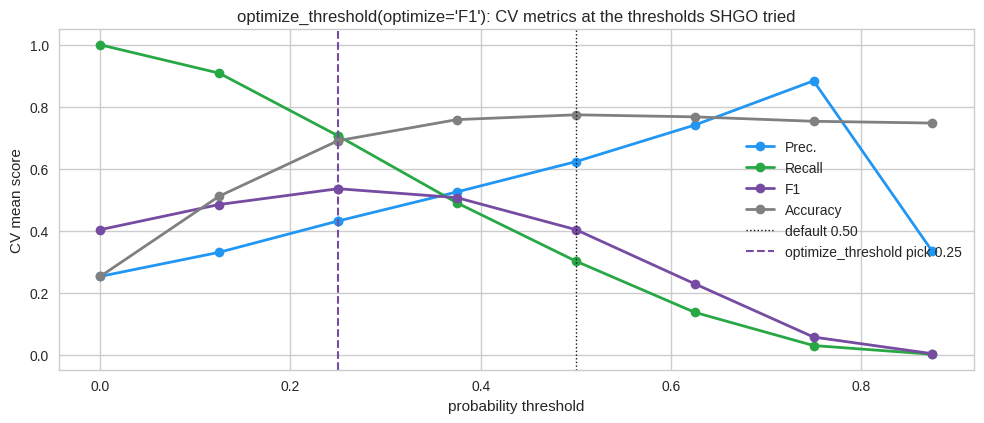

F1 at the pick: 0.536  |  each dot is one 3-fold cross-validation


In [ ]:
wide = thr_data.pivot_table(index="probability_threshold", columns="variable", values="value")
fig, ax = plt.subplots(figsize=(10, 4.4))
for col, color in zip(["Prec.", "Recall", "F1", "Accuracy"], ["#2196F3", "#28a745", "#764ba2", "gray"]):
    if col in wide:
        ax.plot(wide.index, wide[col], marker="o", lw=2, color=color, label=col)
ax.axvline(0.5, color="k", ls=":", lw=1, label="default 0.50")
ax.axvline(t_f1, color="#764ba2", ls="--", lw=1.5, label=f"optimize_threshold pick {t_f1:.2f}")
ax.set(xlabel="probability threshold", ylabel="CV mean score", title="optimize_threshold(optimize='F1'): CV metrics at the thresholds SHGO tried")
ax.legend(loc="center right")
plt.tight_layout(); plt.show()
print(f"F1 at the pick: {wide.loc[wide.index[np.argmin(np.abs(wide.index - t_f1))], 'F1']:.3f}  |  each dot is one 3-fold cross-validation")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one full cross-validation at one cut-off. Recall (green) falls and precision (blue) rises as the threshold moves right; F1 (purple) peaks in between and the dashed line marks the optimiser's pick. The dots are sparse because the SHGO budget was kept small; a finer curve costs one more cross-validation per dot.

**The common misread:** taking the F1 pick as the business threshold. F1 prices a missed churner and a wasted retention call the same; Part 5 chooses a threshold by *cost* instead.

</div>

## 4.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Squeezing a model, in this order

1. **Tune** when the model is expressive and its defaults were not chosen for your data (tree ensembles usually gain little; a kernel SVM or KNN can gain a lot). Cost: `n_iter × fold` fits. Keep `choose_better=True`.
2. **Bag** a jumpy, high-variance model (a deep tree); **boost** a weak, shallow one (a stump, a depth-3 tree). Cost: 10 fits per fold. On an already-ensembled model (a forest, LightGBM) neither gains much.
3. **Blend** three *diverse* members (linear + bagged + boosted). Cost: the sum of the members at prediction time; `method="soft"` needs `predict_proba` on every member.
4. **Stack** when members disagree a lot or there are many of them. Cost: `1 + members` models at prediction time and `meta_model_fold` extra fits per member in training.
5. **Calibrate** before any expected-value decision; **optimize the threshold** whenever the metric that matters is not accuracy.

**The one gotcha:** every number in this Part is cross-validation on the training partition except the two `report_card` rows. Choose on CV, report on the held-out set once, or the reported number is optimistic by about the fold-to-fold std printed above.

</div>

## 4.7 Task 5 Summary

**✅ Key Takeaways**
- Six calls, one line each: `tune_model`, `ensemble_model`, `blend_models`, `stack_models`, `calibrate_model`, `optimize_threshold`; each leaves its CV table in `pull()`.
- Ensembling pays most on a weak base model; tuning and blending strong models move AUC by hundredths, inside fold-to-fold noise.
- `choose_better=True` returns the original (or the best member) when the improvement loses on CV.
- Calibration changes what a probability means, the threshold changes what is flagged; neither changes AUC.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `churn`, `churn_train`, `churn_test`, `make_churn()` | the regenerated churn table and its 75/25 split |
| `exp4` | the `ClassificationExperiment` for this Part (`test_data=churn_test`) |
| `lgbm`, `lgbm_t`, `tuner`, `lgbm_cv`, `tuned_cv` | LightGBM before and after tuning, the searcher, their per-fold tables |
| `dt`, `dt_bag`, `dt_boost`, `dt_full`, `lr`, `rf`, `blended`, `stacked` | the depth-3 tree and its ensembles, the full-depth tree, the members, the blend and the stack |
| `step_table`, `cv_row()` | the chain in one table and the helper that fills it |
| `lgbm_cal`, `lgbm_t_cal`, `cal_probs`, `cal_table` | sigmoid-calibrated default and tuned LightGBM, their held-out probabilities, the before/after table |
| `lgbm_thr`, `thr_data`, `t_f1` | the thresholded classifier, the threshold curve data, the F1-optimal cut-off |
| `holdout()`, `y_ho`, `final_card` | held-out scorer, the held-out labels, the two-cut-off `report_card` |

**➡️ Next Up:** Part 5 — when the positive class is 1.5% of the rows, accuracy lies and the threshold is a business decision.


# Part 5 · Rare Events: Card Fraud ⭐⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

When the positive class is a percent or two of the rows, three things change and PyCaret has a knob for each: the **training data** can be re-balanced inside every fold (`setup(fix_imbalance=True)`), the **metric** must be one that sees the rare class (`add_metric` for PR-AUC, `sort=` by it), and the **threshold** becomes the decision that matters (`optimize_threshold`, or a cost curve of your own applied through `predict_model(probability_threshold=)`).

</div>

# Task 6 · Rare events with `fix_imbalance` and a cost-aware threshold

## 5.1 ❓ The problem

A card issuer's fraud team sees thousands of transactions an hour and can review a few. A **missed fraud costs the transaction amount**; **every review costs about 5 units** of an analyst's time, fraud or not. The question is not "is this transaction fraud" but "**which transactions are worth a review**", and a model that says "legit" to everything is right on almost every row while catching nothing.


## 5.2 📥 The input

Twenty thousand card transactions with seven columns and a label at about 1.5%. Most frauds follow a pattern (large amount, night hours, far from home, a burst of transactions on a young card, electronics or travel), but about a third of them look like ordinary traffic, so the problem is hard but not hopeless. The rows are split three ways: **train** (the experiment's training partition), **valid** (handed to `setup` as `test_data=`, used to choose the threshold) and **test** (never seen until the final report).


📥 card transactions: 20,000 rows x 8 columns | label = 'is_fraud'


,amount,hour,merchant_category,distance_km,txn_last_hour,card_age_days,online,is_fraud
0,63.32,13,grocery,5.7,1,2515,True,0
1,2.95,15,grocery,3.1,0,2967,True,0
2,80.48,17,restaurant,12.2,0,2019,False,0
3,30.33,7,restaurant,2.0,0,1304,False,0
4,13.10,14,grocery,2.9,1,2717,True,0


column types: {'amount': 'numeric', 'hour': 'numeric', 'merchant_category': 'text/category', 'distance_km': 'numeric', 'txn_last_hour': 'numeric', 'card_age_days': 'numeric', 'online': 'boolean', 'is_fraud': 'numeric'}
label distribution: {0: 0.984, 1: 0.016}


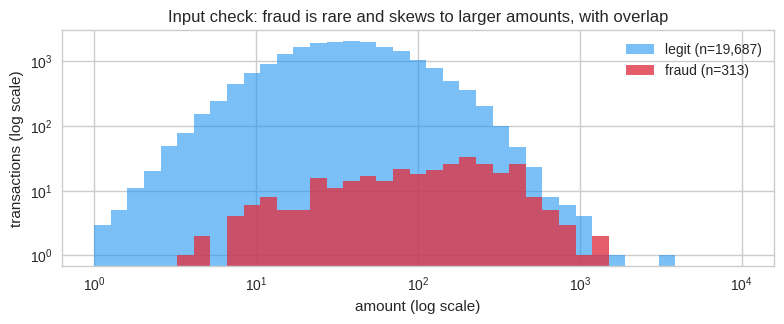

train 12,000 | valid 4,000 | test 4,000 rows;  frauds: 188 / 63 / 62;  fraud rate 1.57%
'always legit' accuracy on this data: 98.43%   |   median amount: legit 36, fraud 132


In [ ]:
def make_fraud(n=20000, rate=0.015, seed=RANDOM_STATE):
    # Card transactions; ~65% of frauds follow the textbook pattern, the rest hide inside normal traffic.
    rng = np.random.default_rng(seed)
    y = (rng.random(n) < rate).astype(int); is_f = y == 1
    typical = is_f & (rng.random(n) < 0.65); k = int(typical.sum())
    amount = np.exp(rng.normal(3.6, 0.9, n)); amount[typical] = np.exp(rng.normal(5.3, 0.7, k))
    day_p = np.array([1, 1, 1, 1, 1, 2, 4, 7, 10, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 9, 7, 5, 3, 2], float); day_p /= day_p.sum()
    night_p = np.array([12, 12, 12, 12, 10, 6, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 6, 8, 10], float); night_p /= night_p.sum()
    hour = rng.choice(24, n, p=day_p); hour[typical] = rng.choice(24, k, p=night_p)
    dist = np.exp(rng.normal(1.6, 1.0, n)); dist[typical] = np.exp(rng.normal(4.0, 1.2, k))
    txn = rng.poisson(0.6, n); txn[typical] = rng.poisson(3.5, k)
    cats = ["grocery", "fuel", "restaurant", "retail", "electronics", "travel"]
    cat = rng.choice(cats, n, p=[0.30, 0.15, 0.20, 0.15, 0.10, 0.10]); cat[typical] = rng.choice(cats, k, p=[0.05, 0.05, 0.05, 0.15, 0.45, 0.25])
    age = rng.integers(30, 3000, n); age[typical] = rng.integers(1, 200, k)
    online = rng.random(n) < 0.35; online[typical] = rng.random(k) < 0.8
    return pd.DataFrame({"amount": amount.round(2), "hour": hour, "merchant_category": cat, "distance_km": dist.round(1),
                         "txn_last_hour": txn, "card_age_days": age, "online": online, "is_fraud": y})

fraud = make_fraud(20000)
fraud_train, rest = train_test_split(fraud, test_size=0.4, stratify=fraud["is_fraud"], random_state=RANDOM_STATE)
fraud_valid, fraud_test = train_test_split(rest, test_size=0.5, stratify=rest["is_fraud"], random_state=RANDOM_STATE)
fraud_train, fraud_valid, fraud_test = [d.reset_index(drop=True) for d in (fraud_train, fraud_valid, fraud_test)]
show_input(fraud, label="is_fraud", name="card transactions")

fig, ax = plt.subplots(figsize=(8, 3.4))
bins = np.logspace(0, 4, 40)
ax.hist(fraud.loc[fraud.is_fraud == 0, "amount"], bins=bins, color="#2196F3", alpha=0.6, label=f"legit (n={int((fraud.is_fraud == 0).sum()):,})")
ax.hist(fraud.loc[fraud.is_fraud == 1, "amount"], bins=bins, color="#dc3545", alpha=0.8, label=f"fraud (n={int(fraud.is_fraud.sum())})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("amount (log scale)"); ax.set_ylabel("transactions (log scale)")
ax.set_title("Input check: fraud is rare and skews to larger amounts, with overlap"); ax.legend()
plt.tight_layout(); plt.show()
print(f"train {len(fraud_train):,} | valid {len(fraud_valid):,} | test {len(fraud_test):,} rows;  frauds: "
      f"{int(fraud_train.is_fraud.sum())} / {int(fraud_valid.is_fraud.sum())} / {int(fraud_test.is_fraud.sum())};  fraud rate {fraud.is_fraud.mean():.2%}")
print(f"'always legit' accuracy on this data: {1 - fraud.is_fraud.mean():.2%}   |   median amount: legit {fraud.loc[fraud.is_fraud == 0, 'amount'].median():.0f}, fraud {fraud.loc[fraud.is_fraud == 1, 'amount'].median():.0f}")


| Column | Type | Meaning |
|---|---|---|
| `amount` | numeric | transaction value in units |
| `hour` | numeric | hour of day, 0-23 |
| `merchant_category` | category | grocery, fuel, restaurant, retail, electronics, travel |
| `distance_km` | numeric | distance from the card holder's home |
| `txn_last_hour` | numeric | transactions on the same card in the previous hour |
| `card_age_days` | numeric | days since the card was issued |
| `online` | boolean | card-not-present transaction |
| `is_fraud` | **label** | 1 if confirmed fraud |

`setup()` infers a binary target, one categorical column to one-hot encode, one boolean and five numeric columns. The printed "always legit" accuracy is the number to remember: any model must be judged against it, not against zero.

## 5.3 💻 One-line calls

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What `fix_imbalance=True` does, and what it does not

It adds a `balance` step to the preprocessing pipeline: **SMOTE** (Synthetic Minority Over-sampling TEchnique) from the `imbalanced-learn` package, which creates synthetic minority rows by interpolating between real ones until the two classes have equal counts. The step runs **only when the pipeline is fit**, so it re-samples the training folds and never the validation fold or the held-out set; the metrics stay honest. `fix_imbalance_method=` accepts any `imblearn` sampler (e.g. `RandomUnderSampler()`, `ADASYN()`).

What it does not do: change the ranking metrics much. A tree ensemble already ranks rare rows well; SMOTE mostly shifts the *probabilities* upward, which changes what the default 0.5 cut-off flags. The two experiments below make that visible.

</div>

Two experiments on the same split: one plain, one with `fix_imbalance=True`. `imblearn` is checked first; without it, the second experiment runs plain and says so.


In [ ]:
# !pip install imbalanced-learn -q     # PyCaret's fix_imbalance needs imblearn; PyCaret installs it as a dependency on Colab
try:
    import imblearn
    IMB_OK = True; imb_note = f"imblearn {imblearn.__version__}"
except ImportError:  # noqa: BLE001 - fall back to a plain setup and say so
    IMB_OK = False; imb_note = "imblearn not installed: fix_imbalance=False (the two experiments will match)"
print(imb_note)

COMMON = dict(target="is_fraud", test_data=fraud_valid, index=False, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False, fold=3)
exp_plain, exp_bal = ClassificationExperiment(), ClassificationExperiment()
with timer("two setups"):
    exp_plain.setup(fraud_train, fix_imbalance=False, **COMMON)
    exp_bal.setup(fraud_train, fix_imbalance=IMB_OK, **COMMON)

for name, e in [("plain", exp_plain), ("fix_imbalance", exp_bal)]:
    s = e.pull().set_index("Description")["Value"]
    print(f"\n{name:>14}: " + " | ".join(f"{k} = {s[k]}" for k in ["Fix imbalance", "Fix imbalance method", "Transformed train set shape"] if k in s.index))
    print(f"{'':>14}  pipeline steps: {[step for step, _ in e.pipeline.steps]}")


imblearn 0.13.0
⏱️ two setups: 2.4 s

         plain: Transformed train set shape = (12000, 13)
                pipeline steps: ['numerical_imputer', 'categorical_imputer', 'onehot_encoding']

 fix_imbalance: Fix imbalance = True | Fix imbalance method = SMOTE | Transformed train set shape = (23624, 13)
                pipeline steps: ['numerical_imputer', 'categorical_imputer', 'onehot_encoding', 'balance']


`compare_models` on both, with **PR-AUC** registered first through `add_metric` so the table carries the one ranking metric that only looks at the rare class. PR-AUC (average precision) is the area under the precision-recall curve; its floor is the positive rate, not 0.5. The sort stays on AUC as in every other Part, and the model with the best CV PR-AUC across both tables becomes the working model.


In [ ]:
INCLUDE = ["lr", "rf", "lightgbm", "et"]
tables, bests = {}, {}
for name, e in [("plain", exp_plain), ("fix_imbalance", exp_bal)]:
    if "pr_auc" in e.get_metrics().index:
        e.remove_metric("pr_auc")
    e.add_metric("pr_auc", "PR-AUC", average_precision_score, target="pred_proba", greater_is_better=True)
    with timer(f"compare_models ({name}), {len(INCLUDE)} models x 3 folds"):
        bests[name] = e.compare_models(include=INCLUDE, fold=3, sort="AUC", verbose=False)
    tables[name] = e.pull()
cmp_fraud = pd.concat(tables, names=["setup", "id"])
print(cmp_fraud[["Model", "Accuracy", "AUC", "PR-AUC", "Recall", "Prec.", "F1", "TT (Sec)"]].round(4).to_string())

win_setup, win_id = cmp_fraud["PR-AUC"].idxmax()
work_exp = {"plain": exp_plain, "fix_imbalance": exp_bal}[win_setup]
if win_id == tables[win_setup].index[0]:
    work_model = bests[win_setup]                                   # the AUC winner is also the PR-AUC winner: reuse it
else:
    work_model = work_exp.create_model(win_id, fold=3, verbose=False)
print(f"\nworking model: {win_id} from the '{win_setup}' setup (best CV PR-AUC = {cmp_fraud['PR-AUC'].max():.4f})")


⏱️ compare_models (plain), 4 models x 3 folds: 14.6 s
⏱️ compare_models (fix_imbalance), 4 models x 3 folds: 24.1 s
                                                  Model  Accuracy     AUC  PR-AUC  Recall   Prec.      F1  TT (Sec)
setup         id                                                                                                   
plain         rf               Random Forest Classifier    0.9923  0.8188  0.6398  0.5154  0.9905  0.6737    1.0100
              lightgbm  Light Gradient Boosting Machine    0.9930  0.8125  0.6415  0.5793  0.9609  0.7191    1.6700
              et                 Extra Trees Classifier    0.9922  0.8108  0.6264  0.5209  0.9730  0.6765    0.6067
              lr                    Logistic Regression    0.9910  0.8015  0.6018  0.4516  0.9419  0.6080    0.5067
fix_imbalance et                 Extra Trees Classifier    0.9920  0.8192  0.6093  0.5474  0.9033  0.6791    1.4000
              lightgbm  Light Gradient Boosting Machine    0.9922  0.819

The last call: `optimize_threshold(optimize="F1")` on the working model, bounded as in Part 4. It gives the F1-optimal cut-off; the cost-optimal one is computed by hand in 5.4 because PyCaret has no notion of the price of a mistake.


In [ ]:
with timer("optimize_threshold(optimize='F1'), bounded SHGO"), quiet_plotly():
    thr_fraud, work_thr = work_exp.optimize_threshold(work_model, optimize="F1", return_data=True, verbose=False,
                                                      n=8, options={"maxiter": 1, "f_tol": 1e-2},
                                                      minimizer_kwargs={"options": {"maxiter": 3, "ftol": 1e-2}})
t_f1_fraud = float(work_thr.probability_threshold)
print(f"F1-optimal threshold for {win_id}: {t_f1_fraud:.3f}  ({thr_fraud['probability_threshold'].nunique()} thresholds tried)")


⏱️ optimize_threshold(optimize='F1'), bounded SHGO: 32.6 s
F1-optimal threshold for lightgbm: 0.250  (10 thresholds tried)


## 5.4 📤 The output

Three outputs: the **compare tables** for both setups side by side, the **validation report** (`report_card` on the `valid` split with the "always legit" baseline as its floor), and the **decision**: a cost curve on `valid` that picks the threshold, then one `predict_model` per threshold on the untouched `test` split.


In [ ]:
display(pretty(cmp_fraud[["Accuracy", "AUC", "PR-AUC", "Recall", "Prec.", "F1", "MCC"]]))

def holdout_fraud(e, model, data=None, **kw):
    # (y_true, label, P(fraud)) on the experiment's held-out set (= fraud_valid) or on any frame passed as data=
    p = e.predict_model(model, data=data, raw_score=True, verbose=False, **kw)
    return p["is_fraud"].values, p["prediction_label"].values, p["prediction_score_1"].values, p

cards = []
y_v = fraud_valid["is_fraud"].values
cards.append(report_card(y_v, np.zeros_like(y_v), np.full(len(y_v), y_v.mean()), name="always legit (baseline)"))
valid_probs = {}
for name, e in [("plain", exp_plain), ("fix_imbalance", exp_bal)]:
    best_id = tables[name].index[0]
    yt, lab, prob, _ = holdout_fraud(e, bests[name]); valid_probs[f"{best_id} ({name})"] = prob
    cards.append(report_card(yt, lab, prob, name=f"{best_id} ({name}) @ 0.50"))
yt, lab, prob, _ = holdout_fraud(work_exp, work_thr); valid_probs["working"] = prob
cards.append(report_card(yt, lab, prob, name=f"{win_id} ({win_setup}) @ F1-optimal {t_f1_fraud:.2f}"))
valid_card = pd.concat(cards)
print("\nvalidation split, report_card:")
display(pretty(valid_card[["accuracy", "balanced_acc", "precision", "recall", "f1", "mcc", "roc_auc", "pr_auc"]]))
print(f"baseline accuracy {valid_card.iloc[0]['accuracy']:.4f} vs best model accuracy {valid_card['accuracy'].iloc[1:].max():.4f};  baseline pr_auc = positive rate = {y_v.mean():.4f}")



validation split, report_card:


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc
model,,,,,,,,
always legit (baseline),0.984,0.500,0.000,0.000,0.000,0.000,0.500,0.016
rf (plain) @ 0.50,0.994,0.802,1.000,0.603,0.752,0.774,0.829,0.721
et (fix_imbalance) @ 0.50,0.993,0.793,0.949,0.587,0.725,0.744,0.861,0.695
lightgbm (plain) @ F1-optimal 0.25,0.995,0.841,0.956,0.683,0.796,0.805,0.842,0.729


baseline accuracy 0.9842 vs best model accuracy 0.9945;  baseline pr_auc = positive rate = 0.0158


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📤 Reading the tables

- **Compare tables.** The `Accuracy` column is almost identical across all eight rows and almost identical to the baseline printed above: on a 1.5% target accuracy cannot tell the models apart. `AUC` and `PR-AUC` can; `PR-AUC` spreads them furthest because it only scores how the rare rows are ranked. Compare the `Recall` and `Prec.` columns across the two setups: with `fix_imbalance` the models flag more rows at 0.5 (recall up, precision down), because they learned on a 50/50 world and their probabilities sit higher.
- **Validation report.** The baseline row is the floor: its accuracy is one minus the fraud rate, its recall is zero, its `pr_auc` equals the fraud rate. Every model row must be read as lift over that. The last row applies the F1-optimal cut-off to the working model: `roc_auc` and `pr_auc` do not move, `recall`, `precision`, `f1` and `mcc` do.

**The common misread:** "the model is 98% accurate". So is a rock. Report `pr_auc`, `recall` at a chosen precision, or the cost below.

</div>

**The cost curve.** For every threshold $t$, on the validation split:

$$ \text{cost}(t) = \sum_{\text{missed frauds}} \text{amount}_i \;+\; 5 \times \#\{\text{flagged}\} $$

The two ends of the curve are the two do-nothing policies: at $t = 1$ nothing is flagged and every fraud's amount is lost; at $t = 0$ every transaction is reviewed at 5 units each. The threshold with the lowest cost is applied to the **test** split through `predict_model(..., probability_threshold=t)`, once per threshold, so the reported numbers are on rows that neither the model nor the threshold choice has seen.


In [ ]:
REVIEW_COST = 5.0
amt_v = fraud_valid["amount"].values; p_v = valid_probs["working"]
grid_t = np.round(np.linspace(0.0, 1.0, 201), 3)
sweep = []
for t in grid_t:
    flagged = p_v >= t
    missed = (~flagged) & (y_v == 1)
    sweep.append({"threshold": t, "lost amount": amt_v[missed].sum(), "review cost": REVIEW_COST * flagged.sum(),
                  "flag rate": flagged.mean(), "recall": recall_score(y_v, flagged.astype(int), zero_division=0),
                  "precision": precision_score(y_v, flagged.astype(int), zero_division=0)})
sweep = pd.DataFrame(sweep).set_index("threshold"); sweep["total cost"] = sweep["lost amount"] + sweep["review cost"]
t_cost = float(sweep["total cost"].idxmin())
print(f"validation: review nothing costs {sweep.loc[1.0, 'total cost']:,.0f} | review everything {sweep.loc[0.0, 'total cost']:,.0f} | "
      f"cost-optimal threshold {t_cost:.3f} costs {sweep['total cost'].min():,.0f} (flag rate {sweep.loc[t_cost, 'flag rate']:.1%})")

# apply the three thresholds to the untouched test split, one predict_model each
amt_t = fraud_test["amount"].values
rows, cards = [], []
for label, t in [("default 0.50", 0.5), (f"F1-optimal {t_f1_fraud:.2f}", t_f1_fraud), (f"cost-optimal {t_cost:.2f}", t_cost)]:
    yt, lab, prob, _ = holdout_fraud(work_exp, work_model, data=fraud_test, probability_threshold=t)
    missed = (lab == 0) & (yt == 1); fp = (lab == 1) & (yt == 0)
    rows.append({"threshold": label, "flagged": int(lab.sum()), "frauds caught": int(((lab == 1) & (yt == 1)).sum()), "frauds missed": int(missed.sum()),
                 "false alarms": int(fp.sum()), "lost amount": amt_t[missed].sum(), "review cost": REVIEW_COST * lab.sum()})
    cards.append(report_card(yt, lab, prob, name=label))
cost_test = pd.DataFrame(rows).set_index("threshold"); cost_test["total cost"] = cost_test["lost amount"] + cost_test["review cost"]
test_card = pd.concat(cards)
print(f"\ntest split ({len(fraud_test):,} rows, {int(fraud_test.is_fraud.sum())} frauds worth {amt_t[fraud_test.is_fraud.values == 1].sum():,.0f} units):")
print(cost_test.round(0).to_string())
display(pretty(test_card[["accuracy", "precision", "recall", "f1", "mcc", "roc_auc", "pr_auc"]]))


validation: review nothing costs 9,409 | review everything 20,000 | cost-optimal threshold 0.045 costs 1,357 (flag rate 1.6%)

test split (4,000 rows, 62 frauds worth 13,046 units):
                   flagged  frauds caught  frauds missed  false alarms  lost amount  review cost  total cost
threshold                                                                                                   
default 0.50            35             35             27             0       1714.0        175.0      1889.0
F1-optimal 0.25         38             37             25             1       1500.0        190.0      1690.0
cost-optimal 0.04       50             39             23            11       1358.0        250.0      1608.0


,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc
model,,,,,,,
default 0.50,0.993,1.000,0.565,0.722,0.749,0.830,0.645
F1-optimal 0.25,0.994,0.974,0.597,0.740,0.760,0.830,0.645
cost-optimal 0.04,0.992,0.780,0.629,0.696,0.696,0.830,0.645


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📤 Reading the decision table

Three rows, one per threshold, all on the test split. Read `total cost` first: it is the only column that prices a miss and a review in the same unit. Then read `flagged` as the analysts' workload and `frauds missed` as the losses. The `report_card` beneath shows `accuracy` and `precision` moving the other way from `recall` as the threshold drops, and `roc_auc` / `pr_auc` not moving at all.

**The common misread:** rejecting the cost-optimal row because its accuracy or precision is the lowest. Those columns price a missed 300-unit fraud and a 5-unit review the same; the cost column does not.

</div>

The last output is the one the fraud team actually reads every morning: **the review queue**, the twenty riskiest transactions of the test split by `prediction_score_1`, with the true label shown here only because this is a tour.


In [ ]:
_, _, _, scored = holdout_fraud(work_exp, work_model, data=fraud_test, probability_threshold=t_cost)
queue = (scored.sort_values("prediction_score_1", ascending=False)
               .head(20)[["prediction_score_1", "amount", "hour", "merchant_category", "distance_km", "txn_last_hour", "card_age_days", "online", "is_fraud"]]
               .rename(columns={"prediction_score_1": "P(fraud)"}).astype({"merchant_category": str}))
display(pretty(queue, fmt={"P(fraud)": "{:.3f}", "amount": "{:,.2f}", "distance_km": "{:.1f}"}, subset=[]))
print(f"top-20 queue: {int(queue['is_fraud'].sum())} of 20 are fraud (precision@20 = {queue['is_fraud'].mean():.0%}); "
      f"fraud rate in the test split is {fraud_test.is_fraud.mean():.2%}")


,P(fraud),amount,hour,merchant_category,distance_km,txn_last_hour,card_age_days,online,is_fraud
2850,1.000,817.67,2,electronics,56.4,6,145,True,1
2571,1.000,543.47,5,travel,547.5,5,106,True,1
279,1.000,527.00,4,travel,45.8,6,73,True,1
1706,1.000,242.83,23,travel,60.2,4,61,True,1
1323,1.000,292.06,23,retail,264.1,5,159,True,1
3334,1.000,577.57,5,retail,70.8,6,166,True,1
1172,1.000,189.42,2,fuel,276.1,5,98,True,1
2854,1.000,217.47,0,electronics,25.4,4,43,True,1
1326,1.000,196.11,2,electronics,95.8,3,36,True,1
2396,1.000,187.59,22,travel,19.7,5,184,True,1


top-20 queue: 20 of 20 are fraud (precision@20 = 100%); fraud rate in the test split is 1.55%


## 5.5 📊 The picture


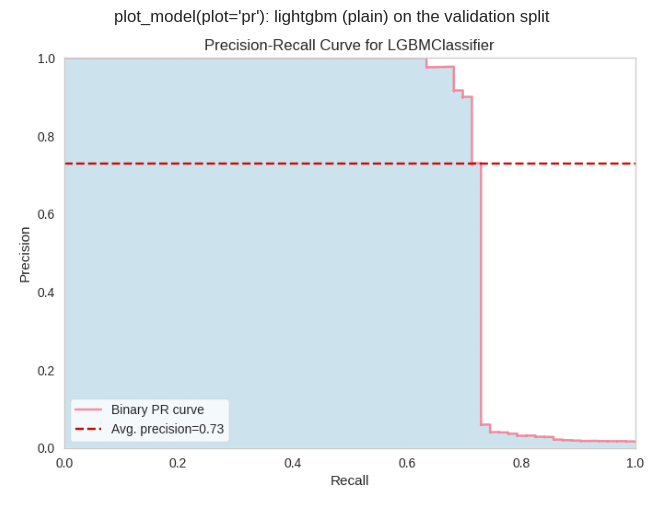

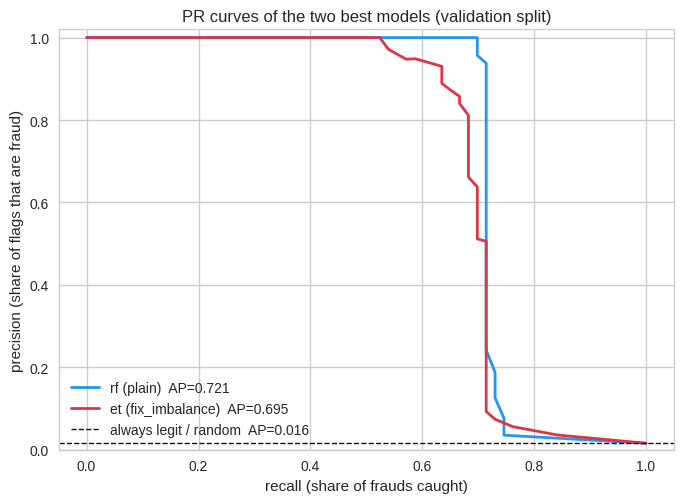

PR curve: the top-right corner is perfect; the dashed floor is the fraud rate, which is where a random ranking lives.


In [ ]:
from sklearn.metrics import precision_recall_curve

render(lambda **kw: work_exp.plot_model(work_model, plot="pr", verbose=False, **kw),
       title=f"plot_model(plot='pr'): {win_id} ({win_setup}) on the validation split", figsize=(7, 5.2))

fig, ax = plt.subplots(figsize=(7, 5.2))
for (name, p), color in zip([(k, v) for k, v in valid_probs.items() if k != "working"], ["#2196F3", "#dc3545"]):
    prec, rec, _ = precision_recall_curve(y_v, p)
    ax.plot(rec, prec, lw=2, color=color, label=f"{name}  AP={average_precision_score(y_v, p):.3f}")
ax.axhline(y_v.mean(), color="k", ls="--", lw=1, label=f"always legit / random  AP={y_v.mean():.3f}")
ax.set(xlabel="recall (share of frauds caught)", ylabel="precision (share of flags that are fraud)", ylim=(0, 1.02),
       title="PR curves of the two best models (validation split)")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()
print("PR curve: the top-right corner is perfect; the dashed floor is the fraud rate, which is where a random ranking lives.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

First, PyCaret's own precision-recall picture for the working model, drawn on the experiment's held-out partition (the validation split); the legend carries its average precision. Second, the same curve for the best model of each setup, on the same rows, with the baseline as a dashed floor at the fraud rate. Both curves stay near the top while the flags are the textbook frauds (large, at night, far from home), then fall off a cliff at the recall where those run out: the remaining frauds were planted to look like ordinary traffic and no ranking can lift them above it. Where the two curves sit relative to each other tells you what `fix_imbalance` bought on *ranking*: usually little, which is the point of the earlier callout.

**The common misread:** judging a rare-event model by its ROC curve. With thousands of negatives the false-positive rate barely moves and every model hugs the top-left corner; the PR curve is where the differences live.

</div>


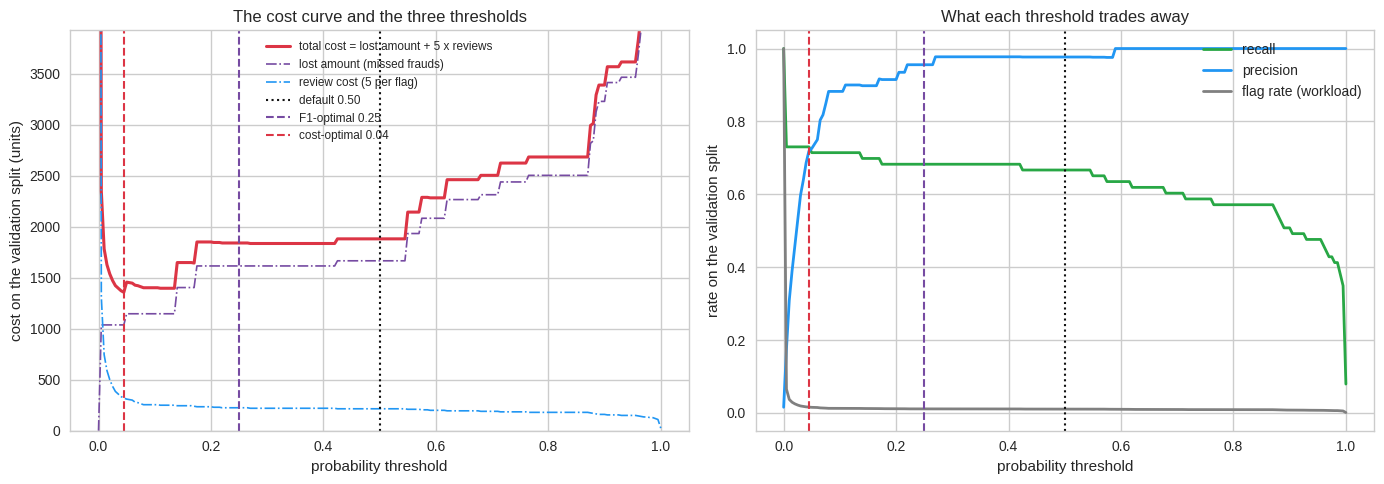

at the cost-optimal threshold the queue is 1.6% of transactions and catches 73% of frauds; at 0.50 it is 1.1% and 67%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(sweep.index, sweep["total cost"], color="#dc3545", lw=2.2, label="total cost = lost amount + 5 x reviews")
ax.plot(sweep.index, sweep["lost amount"], color="#764ba2", lw=1.2, ls="-.", label="lost amount (missed frauds)")
ax.plot(sweep.index, sweep["review cost"], color="#2196F3", lw=1.2, ls="-.", label="review cost (5 per flag)")
for label, t, color, ls in [("default 0.50", 0.5, "k", ":"), (f"F1-optimal {t_f1_fraud:.2f}", t_f1_fraud, "#764ba2", "--"), (f"cost-optimal {t_cost:.2f}", t_cost, "#dc3545", "--")]:
    ax.axvline(t, color=color, ls=ls, lw=1.5, label=label)
ax.set(xlabel="probability threshold", ylabel="cost on the validation split (units)", title="The cost curve and the three thresholds")
ax.set_ylim(0, sweep["total cost"].quantile(0.9) * 1.1); ax.legend(loc="upper center", fontsize=8.5)
ax = axes[1]
ax.plot(sweep.index, sweep["recall"], color="#28a745", lw=2, label="recall")
ax.plot(sweep.index, sweep["precision"], color="#2196F3", lw=2, label="precision")
ax.plot(sweep.index, sweep["flag rate"], color="gray", lw=2, label="flag rate (workload)")
for t, color, ls in [(0.5, "k", ":"), (t_f1_fraud, "#764ba2", "--"), (t_cost, "#dc3545", "--")]:
    ax.axvline(t, color=color, ls=ls, lw=1.5)
ax.set(xlabel="probability threshold", ylabel="rate on the validation split", title="What each threshold trades away"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()
print(f"at the cost-optimal threshold the queue is {sweep.loc[t_cost, 'flag rate']:.1%} of transactions and catches {sweep.loc[t_cost, 'recall']:.0%} of frauds; "
      f"at 0.50 it is {np.interp(0.5, sweep.index, sweep['flag rate']):.1%} and {np.interp(0.5, sweep.index, sweep['recall']):.0%}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the red total-cost curve is the sum of two curves that pull in opposite directions, the purple lost-amount curve that rises as the threshold rises (more frauds slip through) and the blue review-cost curve that falls (fewer flags). Its minimum is the cost-optimal threshold, marked in red. Both ends of the curve run off the top of the chart: the "review everything" and "review nothing" costs are printed in 5.4. The black dotted line is the default 0.5 and the purple dashed line is the F1 pick; the three do not coincide, because F1 does not know that a missed fraud is worth many reviews. Right: the same three thresholds against recall, precision and the flag rate (the analysts' queue as a share of all transactions); the flat stretch of the recall line is the cliff from the PR curve seen from the other side.

**The common misread:** reading the cost curve as a property of the model. It is a property of the model **and** the price list: change the review cost or the loss per miss and the minimum moves. Re-run the sweep whenever either changes.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ SMOTE moves the probabilities, so the threshold must be chosen after `fix_imbalance`, not before

A model trained on a re-balanced fold has seen a 50/50 world and scores everything higher than the true 1.5% rate warrants. The same 0.5 cut-off therefore flags a different share of transactions in the two setups (compare their `Recall` and `Prec.` in the tables). A threshold picked on one setup is meaningless on the other, and `calibrate_model` (Part 4) is the right repair if the probabilities themselves need to be believed.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: three splits for a threshold decision

Train, choose the threshold on a split the model did not train on, report on a third. The sweep above used the validation split; the test tables used the test split once per threshold. Sweeping and reporting on the same rows makes the reported cost optimistic; the gap grows as the positive class gets rarer, because a handful of frauds decide the minimum.

</div>

## 5.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Rare events: metric and threshold over model

- **Use `fix_imbalance=True`** when the positive class is a few percent or less and the model family is sensitive to class balance (linear models, neural networks, k-NN); tree ensembles gain little in ranking. Cost: `imbalanced-learn` as a dependency and SMOTE's runtime inside every fold.
- **Always register PR-AUC** (`add_metric`) and read it next to AUC; sort or `optimize=` by it when the job is to find the rare class.
- **Always add the do-nothing baseline** to every table: its accuracy is the floor the model must beat.
- **Decide the threshold by cost** when a miss and a false alarm have different prices, which is always; use `optimize_threshold` when there is no price list and a single metric must do.

**The one gotcha:** the threshold belongs to the model and the price list it was chosen with. Retrain the model, change the review cost, or switch `fix_imbalance` on or off, and the sweep must run again.

</div>

## 5.7 Task 6 Summary

**✅ Key Takeaways**
- `setup(fix_imbalance=True)` adds a SMOTE step that re-samples training folds only; it shifts probabilities more than it improves ranking.
- Accuracy cannot separate models on a 1.5% target; `PR-AUC` and `report_card` rows read against the "always legit" baseline can.
- The cost curve turns a threshold into a business decision; `predict_model(probability_threshold=t)` applies it and `optimize_threshold` gives a metric-optimal alternative.
- Three splits: train, choose on valid, report on test once.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `fraud`, `fraud_train`, `fraud_valid`, `fraud_test`, `make_fraud()` | the transactions and their 60/20/20 split |
| `exp_plain`, `exp_bal`, `IMB_OK` | the two experiments and whether `imblearn` imported |
| `cmp_fraud`, `tables` | the two compare tables (with PR-AUC) stacked, and per setup |
| `work_exp`, `work_model`, `win_id`, `win_setup` | the working model, its experiment and where it came from |
| `work_thr`, `thr_fraud`, `t_f1_fraud` | the F1-optimal thresholded classifier, the curve data, its cut-off |
| `holdout_fraud()`, `valid_probs`, `valid_card` | held-out scorer, validation probabilities, the validation `report_card` |
| `sweep`, `t_cost`, `REVIEW_COST` | the cost sweep on the validation split, the cost-optimal threshold, the review price |
| `cost_test`, `test_card`, `queue` | the decision table and `report_card` on the test split, the review queue |

**➡️ Next Up:** Part 6 drops the label entirely and asks which customers behave alike.


# Part 6 · Clustering: Customer Segments ⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

`pycaret.clustering` has no target column. `setup` builds the same preprocessing pipeline as the supervised modules (imputation, encoding, `normalize=True`), `create_model("kmeans", num_clusters=k)` fits one algorithm, `pull()` reports three **internal** metrics that need no labels, and `assign_model` hands back the input rows with a `Cluster` column. `"hclust"`, `"dbscan"` and eight other algorithms are the same two lines with a different id.

</div>

# Task 7 · Segments with `pycaret.clustering`

## 6.1 ❓ The problem

A retailer's marketing team has two thousand customers and no idea how many *kinds* of customer they have. They want a handful of **segments they can name** ("store regulars", "online bargain hunters") to write one campaign each, and a way to assign every new customer to one. There is no label to learn from; the answer has to come from the shape of the data.


## 6.2 📥 The input

Seven columns of behaviour per customer: five numeric habits and two categorical ones (`channel`, `plan`). The generator plants **five behaviours** and keeps the true segment in a hidden column that is split off before anything is fit; it comes back at the very end, as the honest check that no internal metric can give.


📥 customers (no label): 2,000 rows x 7 columns


,visits_per_month,avg_basket,online_share,tenure_months,returns_rate,channel,plan
0,7.24,99.24,0.74,28.19,0.37,app,plus
1,6.64,22.81,0.85,19.67,0.05,web,basic
2,6.44,22.63,0.87,5.56,0.06,app,basic
3,6.88,55.19,0.67,23.96,0.33,web,basic
4,7.16,24.97,0.11,31.33,0.06,store,premium


column types: {'visits_per_month': 'numeric', 'avg_basket': 'numeric', 'online_share': 'numeric', 'tenure_months': 'numeric', 'returns_rate': 'numeric', 'channel': 'text/category', 'plan': 'text/category'}


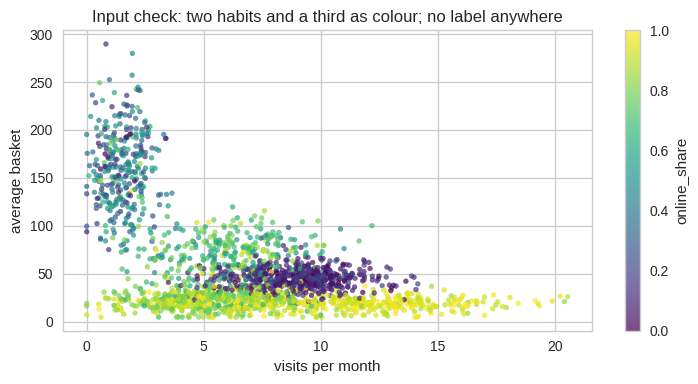

2,000 customers x 7 columns; channel mix {'web': 0.45, 'store': 0.31, 'app': 0.24}; plan mix {'basic': 0.44, 'plus': 0.39, 'premium': 0.17}


In [ ]:
SEGMENTS = {   # five planted behaviours: (mean, sd) per habit, and the channel / plan mix
    "store regulars":         dict(w=0.22, visits=(9, 1.8),   basket=(45, 10),  online=(0.10, 0.06), tenure=(48, 10), returns=(0.03, 0.02), channel=[0.15, 0.75, 0.10], plan=[0.30, 0.50, 0.20]),
    "online bargain hunters": dict(w=0.25, visits=(5, 2.0),   basket=(22, 8),   online=(0.85, 0.10), tenure=(14, 8),  returns=(0.08, 0.04), channel=[0.80, 0.10, 0.10], plan=[0.70, 0.25, 0.05]),
    "big-basket occasionals": dict(w=0.15, visits=(1.5, 0.8), basket=(160, 40), online=(0.40, 0.20), tenure=(30, 15), returns=(0.02, 0.02), channel=[0.40, 0.50, 0.10], plan=[0.20, 0.40, 0.40]),
    "serial returners":       dict(w=0.15, visits=(6, 2.0),   basket=(70, 20),  online=(0.70, 0.15), tenure=(24, 12), returns=(0.35, 0.10), channel=[0.70, 0.15, 0.15], plan=[0.50, 0.40, 0.10]),
    "new app adopters":       dict(w=0.15, visits=(12, 3.0),  basket=(18, 6),   online=(0.95, 0.05), tenure=(3, 2),   returns=(0.05, 0.03), channel=[0.10, 0.05, 0.85], plan=[0.40, 0.50, 0.10]),
}
HABITS = ["visits_per_month", "avg_basket", "online_share", "tenure_months", "returns_rate"]

def make_customers(n=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    names = list(SEGMENTS); w = np.array([SEGMENTS[s]["w"] for s in names])
    seg = rng.choice(names, n, p=w / w.sum())
    df = pd.DataFrame(index=range(n))
    for col, key, lo, hi in [("visits_per_month", "visits", 0, None), ("avg_basket", "basket", 5, None), ("online_share", "online", 0, 1),
                             ("tenure_months", "tenure", 0, None), ("returns_rate", "returns", 0, 1)]:
        vals = np.empty(n)
        for s in names:
            m = seg == s; mu, sd = SEGMENTS[s][key]; vals[m] = rng.normal(mu, sd, m.sum())
        df[col] = np.clip(vals, lo, hi).round(2)
    df["channel"] = [rng.choice(["web", "store", "app"], p=SEGMENTS[s]["channel"]) for s in seg]
    df["plan"] = [rng.choice(["basic", "plus", "premium"], p=SEGMENTS[s]["plan"]) for s in seg]
    df["segment"] = seg
    return df

customers = make_customers(2000)
true_segment = customers.pop("segment")          # hidden until 6.4; never shown to any model
show_input(customers, name="customers (no label)")

fig, ax = plt.subplots(figsize=(7.5, 4))
sc = ax.scatter(customers["visits_per_month"], customers["avg_basket"], c=customers["online_share"], cmap="viridis", s=12, alpha=0.7)
plt.colorbar(sc, ax=ax, label="online_share")
ax.set(xlabel="visits per month", ylabel="average basket", title="Input check: two habits and a third as colour; no label anywhere")
plt.tight_layout(); plt.show()
print(f"{len(customers):,} customers x {customers.shape[1]} columns; channel mix {customers['channel'].value_counts(normalize=True).round(2).to_dict()}; "
      f"plan mix {customers['plan'].value_counts(normalize=True).round(2).to_dict()}")


| Column | Type | Meaning |
|---|---|---|
| `visits_per_month` | numeric | store or site visits per month |
| `avg_basket` | numeric | average spend per visit |
| `online_share` | numeric | share of purchases made online (0-1) |
| `tenure_months` | numeric | months since the first purchase |
| `returns_rate` | numeric | share of purchases returned (0-1) |
| `channel` | category | web, store, app (preferred channel) |
| `plan` | category | basic, plus, premium |

There is no label column. `setup()` will infer five numeric and two categorical columns; the two categoricals are handed to `ignore_features=` here and used to *describe* the clusters later rather than to *form* them. 6.3 shows with a number why.

## 6.3 💻 One-line calls

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Three metrics that need no labels

- **Silhouette** (-1 to 1, higher is better): for each customer, how much closer it is to its own cluster than to the nearest other one, averaged. Around 0.5 on real behaviour data is good; near 0 means the clusters overlap.
- **Calinski-Harabasz** (higher is better): between-cluster spread divided by within-cluster spread. It grows with the number of rows, so compare it only across models on the same data.
- **Davies-Bouldin** (lower is better): for each cluster, the worst-case ratio of its scatter to its distance from another centre, averaged.

They score the **geometry** of a partition. They cannot say whether the partition means anything, and they cannot compare partitions with different numbers of clusters or with rows dropped as noise. `normalize=True` matters more here than anywhere: k-means uses Euclidean distance, and a column measured in months would otherwise outweigh one measured in shares.

</div>


In [ ]:
assert {"normalize", "ignore_features", "session_id", "n_jobs"} <= set(inspect.signature(ClusteringExperiment.setup).parameters)

clu = ClusteringExperiment()
with timer("clustering setup"):
    clu.setup(customers, normalize=True, ignore_features=["channel", "plan"],
              session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
s = clu.pull().set_index("Description")["Value"]
print(" | ".join(f"{k} = {s[k]}" for k in ["Original data shape", "Transformed data shape", "Numeric features", "Normalize", "Normalize method"] if k in s.index))
Xc = clu.get_config("X_transformed")
print(f"matrix the algorithms see: {Xc.shape}, columns {list(Xc.columns)}; column means {Xc.mean().abs().max():.2f}, stds {Xc.std().min():.2f}-{Xc.std().max():.2f} after z-scoring")
print("algorithms available:", list(clu.models().index))


⏱️ clustering setup: 0.1 s
Original data shape = (2000, 7) | Transformed data shape = (2000, 5) | Numeric features = 5 | Normalize = True | Normalize method = zscore
matrix the algorithms see: (2000, 5), columns ['visits_per_month', 'avg_basket', 'online_share', 'tenure_months', 'returns_rate']; column means 0.00, stds 1.00-1.00 after z-scoring
algorithms available: ['kmeans', 'ap', 'meanshift', 'sc', 'hclust', 'dbscan', 'optics', 'birch', 'kmodes']


In [ ]:
with timer("kmeans, k=5"):
    km = clu.create_model("kmeans", num_clusters=5, verbose=False)
km_metrics = clu.pull()[["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]]
print("pull() after create_model:"); print(km_metrics.round(4).to_string(index=False))

segments = clu.assign_model(km)                                   # the input rows + a "Cluster" column
segments["cluster"] = segments["Cluster"].str.replace("Cluster ", "").astype(int)
print("\ncolumns returned by assign_model:", list(segments.columns))
print("cluster sizes:", segments["cluster"].value_counts().sort_index().to_dict())
print("fitted estimator:", km)


⏱️ kmeans, k=5: 0.5 s
pull() after create_model:
 Silhouette  Calinski-Harabasz  Davies-Bouldin
     0.5228          2219.6702          0.6924

columns returned by assign_model: ['visits_per_month', 'avg_basket', 'online_share', 'tenure_months', 'returns_rate', 'Cluster', 'cluster']
cluster sizes: {0: 310, 1: 490, 2: 589, 3: 310, 4: 301}
fitted estimator: KMeans(algorithm='lloyd', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=5, n_init='auto', random_state=42, tol=0.0001, verbose=0)


Two more algorithms with the same two lines, plus one deliberate mistake for scale: a second experiment that keeps `channel` and `plan` as one-hot columns and z-scores them like everything else. **Hierarchical clustering** (`hclust`) merges the two closest groups repeatedly and cuts the tree at `num_clusters`; **DBSCAN** grows clusters from dense regions, needs no $k$ but does need a radius `eps` and `min_samples`, and marks sparse rows as noise (`Cluster -1`).


In [ ]:
rows = {"kmeans (k=5)": km_metrics.iloc[0]}
labels = {"kmeans (k=5)": segments["Cluster"]}
with timer("hclust + dbscan + kmeans with one-hot dummies"):
    hc = clu.create_model("hclust", num_clusters=5, verbose=False); rows["hclust (k=5)"] = clu.pull().iloc[0]
    labels["hclust (k=5)"] = clu.assign_model(hc)["Cluster"]
    db = clu.create_model("dbscan", eps=0.7, min_samples=10, verbose=False); rows["dbscan (eps=0.7)"] = clu.pull().iloc[0]
    labels["dbscan (eps=0.7)"] = clu.assign_model(db)["Cluster"]
    clu_ohe = ClusteringExperiment()
    clu_ohe.setup(customers, normalize=True, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)   # channel + plan one-hot, then z-scored
    km_ohe = clu_ohe.create_model("kmeans", num_clusters=5, verbose=False); rows["kmeans (k=5) + one-hot dummies"] = clu_ohe.pull().iloc[0]
    labels["kmeans (k=5) + one-hot dummies"] = clu_ohe.assign_model(km_ohe)["Cluster"]

algo_table = pd.DataFrame(rows).T[["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]].astype(float)
algo_table["n_clusters"] = [lab.nunique() - int((lab == "Cluster -1").any()) for lab in labels.values()]
algo_table["noise rows"] = [int((lab == "Cluster -1").sum()) for lab in labels.values()]
print(algo_table.round(3).to_string())
print(f"\nthe one-hot experiment clustered on {clu_ohe.get_config('X_transformed').shape[1]} columns instead of {Xc.shape[1]}")


⏱️ hclust + dbscan + kmeans with one-hot dummies: 1.9 s
                                Silhouette  Calinski-Harabasz  Davies-Bouldin  n_clusters  noise rows
kmeans (k=5)                         0.523           2219.670           0.692           5           0
hclust (k=5)                         0.519           2140.938           0.699           5           0
dbscan (eps=0.7)                     0.434            889.399           1.466           3         109
kmeans (k=5) + one-hot dummies       0.258            412.836           1.531           5           0

the one-hot experiment clustered on 11 columns instead of 5


## 6.4 📤 The output

Three outputs: the **metric rows** above (one per algorithm), the **profile** (mean of every habit per cluster, its size, and the channel and plan mix that were held back from the fit), and the same profile as **z-scores**, which is what turns a cluster into a name: "high online share, low tenure" is a segment; "0.93 and 3.1" is not. The z-score of cluster $c$ on habit $j$ is

$$ z_{cj} = \frac{\bar{x}_{cj} - \bar{x}_j}{s_j} $$

the cluster's mean minus the overall mean, in units of the overall standard deviation, so every habit is on the same scale.


In [ ]:
profile = segments.groupby("cluster")[HABITS].mean()
profile["n"] = segments["cluster"].value_counts().sort_index()
for ch in ["store", "web", "app"]:   # assign_model drops ignored columns, so channel / plan come from the original frame (same index)
    profile[f"channel={ch}"] = (customers["channel"] == ch).groupby(segments["cluster"]).mean()
profile["plan=premium"] = (customers["plan"] == "premium").groupby(segments["cluster"]).mean()
print("cluster profile (means; channel / plan were not used to form the clusters):")
display(pretty(profile, fmt="{:.2f}", subset=[]))

zprof = (profile[HABITS] - customers[HABITS].mean()) / customers[HABITS].std()
def auto_name(z):
    # a name from the two habits with the largest |z|
    top = z.abs().sort_values(ascending=False).index[:2]
    return ", ".join(f"{'high' if z[h] > 0 else 'low'} {h.replace('_', ' ')}" for h in top)
zprof["suggested name"] = [auto_name(zprof.loc[c, HABITS]) for c in zprof.index]
print("\nz-score profile and a machine-suggested name per cluster:")
print(zprof.round(2).to_string())


cluster profile (means; channel / plan were not used to form the clusters):


,visits_per_month,avg_basket,online_share,tenure_months,returns_rate,n,channel=store,channel=web,channel=app,plan=premium
cluster,,,,,,,,,,
0,12.44,18.93,0.94,3.16,0.05,310.00,0.05,0.11,0.84,0.09
1,8.99,44.86,0.10,48.52,0.03,490.00,0.72,0.18,0.10,0.20
2,5.14,23.00,0.85,13.50,0.08,589.00,0.09,0.76,0.15,0.05
3,1.54,160.10,0.41,29.17,0.02,310.00,0.49,0.41,0.10,0.44
4,6.16,71.42,0.69,23.74,0.36,301.00,0.16,0.70,0.14,0.12



z-score profile and a machine-suggested name per cluster:
         visits_per_month  avg_basket  online_share  tenure_months  returns_rate                            suggested name
cluster                                                                                                                   
0                    1.46       -0.73          1.03          -1.13         -0.38  high visits per month, low tenure months
1                    0.56       -0.22         -1.42           1.28         -0.55      low online share, high tenure months
2                   -0.43       -0.65          0.77          -0.58         -0.12         high online share, low avg basket
3                   -1.37        2.02         -0.53           0.25         -0.61     high avg basket, low visits per month
4                   -0.17        0.29          0.29          -0.04          2.16        high returns rate, high avg basket


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📤 Reading the profile

Read one row at a time and look for the habits that stand out. A row with a large positive z on `online_share` and a large negative one on `tenure_months` is a young, online-only group; a row with a large positive `avg_basket` and a large negative `visits_per_month` shops rarely but big. The `channel=` and `plan=` columns were never seen by k-means, so if they differ sharply between rows, the clusters capture something real about the customers and not just about the five columns used.

**The common misread:** treating a cluster's mean as the description of its members. A cluster is a region, not a type: half of its members sit below every mean in its row. The z-scores describe the centre, the silhouette says how much the members agree with it.

</div>

The hidden column comes back for the last table. **Adjusted Rand index** (ARI) scores how well a partition agrees with the planted segments, 0 for a random partition, 1 for a perfect match, and does not care how the clusters are numbered.


In [ ]:
from sklearn.metrics import adjusted_rand_score

print("k-means clusters vs the planted segments (rows are clusters):")
xt = pd.crosstab(segments["cluster"], true_segment); print(xt.to_string())
algo_table["ARI vs planted"] = [adjusted_rand_score(true_segment, lab) for lab in labels.values()]
print("\nevery algorithm against the planted segments:")
display(pretty(algo_table, subset=["Silhouette", "ARI vs planted"]))
best_internal = algo_table["Silhouette"].idxmax(); best_truth = algo_table["ARI vs planted"].idxmax()
print(f"best by silhouette: {best_internal}  |  best by agreement with the planted segments: {best_truth}")
print(f"k-means with one-hot dummies: silhouette {algo_table.loc['kmeans (k=5) + one-hot dummies', 'Silhouette']:.3f}, ARI {algo_table.loc['kmeans (k=5) + one-hot dummies', 'ARI vs planted']:.3f} "
      f"vs numeric-only {algo_table.loc['kmeans (k=5)', 'Silhouette']:.3f}, ARI {algo_table.loc['kmeans (k=5)', 'ARI vs planted']:.3f}")


k-means clusters vs the planted segments (rows are clusters):
segment  big-basket occasionals  new app adopters  online bargain hunters  serial returners  store regulars
cluster                                                                                                    
0                             0               297                      13                 0               0
1                             1                 0                       0                 0             489
2                             2                44                     526                17               0
3                           309                 0                       0                 1               0
4                             0                 0                       0               301               0

every algorithm against the planted segments:


,Silhouette,Calinski-Harabasz,Davies-Bouldin,n_clusters,noise rows,ARI vs planted
kmeans (k=5),0.523,2219.670,0.692,5.000,0.000,0.903
hclust (k=5),0.519,2140.938,0.699,5.000,0.000,0.881
dbscan (eps=0.7),0.434,889.399,1.466,3.000,109.000,0.516
kmeans (k=5) + one-hot dummies,0.258,412.836,1.531,5.000,0.000,0.583


best by silhouette: kmeans (k=5)  |  best by agreement with the planted segments: kmeans (k=5)
k-means with one-hot dummies: silhouette 0.258, ARI 0.583 vs numeric-only 0.523, ARI 0.903


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ One-hot columns hijack k-means

The last printed line is the mistake made on purpose. `setup` one-hot encodes `channel` and `plan` into six 0/1 columns and, with `normalize=True`, z-scores them like the habits. A z-scored dummy jumps by two or three standard deviations between a 0 and a 1, so six of them dominate the Euclidean distance and k-means ends up grouping customers by *channel and plan* instead of by behaviour: the ARI against the planted segments drops although the silhouette does not tell you anything is wrong. Keep categoricals out of the distance (`ignore_features=`) and profile them afterwards, or use a distance built for mixed data (Gower, k-prototypes) outside PyCaret.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: validate clusters with something the model never saw

Internal metrics rank geometry, not meaning. Two warnings from the tables: DBSCAN's silhouette is computed only over the rows it did not discard as noise, so it is not comparable with the others; and in 6.5 the silhouette sweep and the elbow disagree about $k$ by one, with the planted truth on one side. In practice there is no planted column, so hold back a variable you care about (`channel`, `plan`, next-quarter revenue, churn) and check that it differs across clusters, as the `channel=` columns of the profile do here. If nothing you care about differs, the clustering is not wrong, it is useless.

</div>

## 6.5 📊 The picture

`plot_model(plot="elbow")` fits k-means for a range of $k$ and draws the within-cluster sum of squares; `plot="silhouette"` draws every customer's silhouette, sorted within its cluster. Both are matplotlib pictures (through the `yellowbrick` library), so they render anywhere through `render_grid`. `plot="cluster"` and `plot="tsne"` are plotly figures that need a browser; the PCA scatter after them is the same picture drawn with matplotlib.


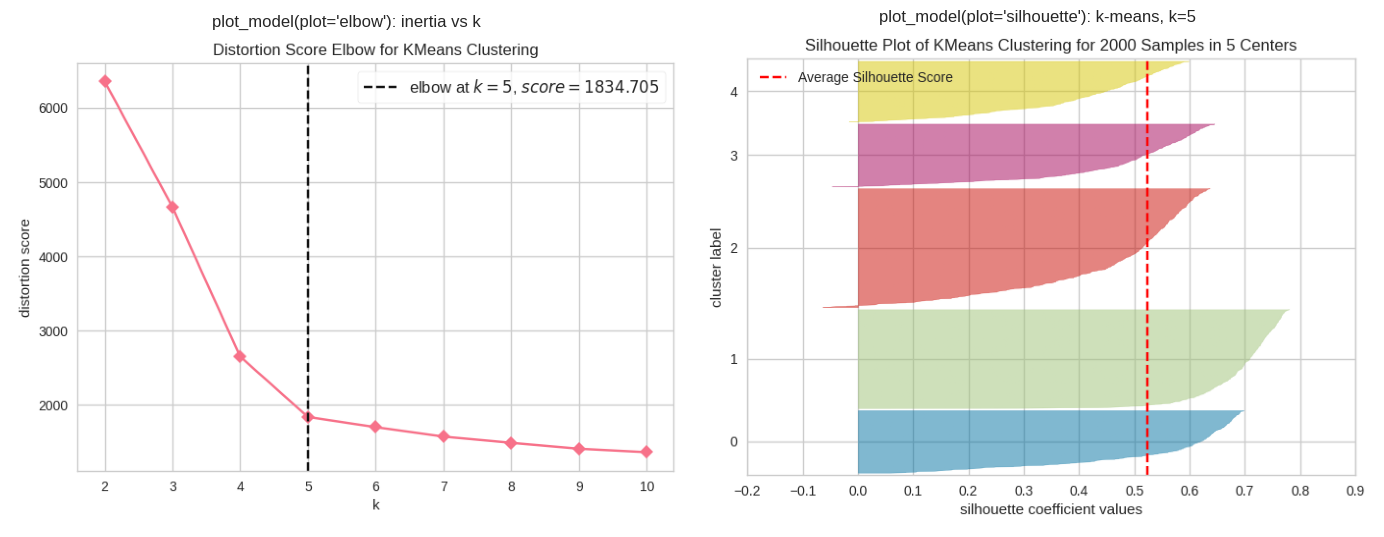

⏱️ elbow + silhouette plots: 2.3 s
mean silhouette by k (own sweep, same matrix): {2: 0.396, 3: 0.476, 4: 0.539, 5: 0.523, 6: 0.485, 7: 0.406, 8: 0.384} -> peak at k = 4


In [ ]:
with timer("elbow + silhouette plots"):
    files = render_grid([("plot_model(plot='elbow'): inertia vs k", lambda **kw: clu.plot_model(km, plot="elbow", verbose=False, **kw), {}),
                         ("plot_model(plot='silhouette'): k-means, k=5", lambda **kw: clu.plot_model(km, plot="silhouette", verbose=False, **kw), {})],
                        ncols=2, figsize=(14, 5.4))
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sil_by_k = {k: silhouette_score(Xc, KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xc)) for k in range(2, 9)}
print("mean silhouette by k (own sweep, same matrix):", {k: round(v, 3) for k, v in sil_by_k.items()}, "-> peak at k =", max(sil_by_k, key=sil_by_k.get))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: inertia (the within-cluster sum of squares) always falls as $k$ grows, because more centres are always closer to the rows; the "elbow" is where the fall flattens, and yellowbrick marks its own guess with a dashed line (its "knee" rule). Right: one horizontal bar per customer, its silhouette, sorted and stacked by cluster; the dashed vertical line is the mean. Wide, tall shapes are good clusters; a cluster whose shape tapers towards zero or dips below it holds customers that sit closer to a neighbouring centre. The printed sweep gives the mean silhouette for every $k$; its peak is one short of the elbow's pick and of the five the generator planted, because two of the planted behaviours are close neighbours in habit space (the crosstab in 6.4 shows which two trade members) and one tighter cluster covering both scores a better silhouette than two that touch.

**The common misread:** treating the elbow or the silhouette peak as the answer. They are heuristics on geometry; when they disagree with each other or with the hidden check, the profile decides which segments a campaign can actually use.

</div>


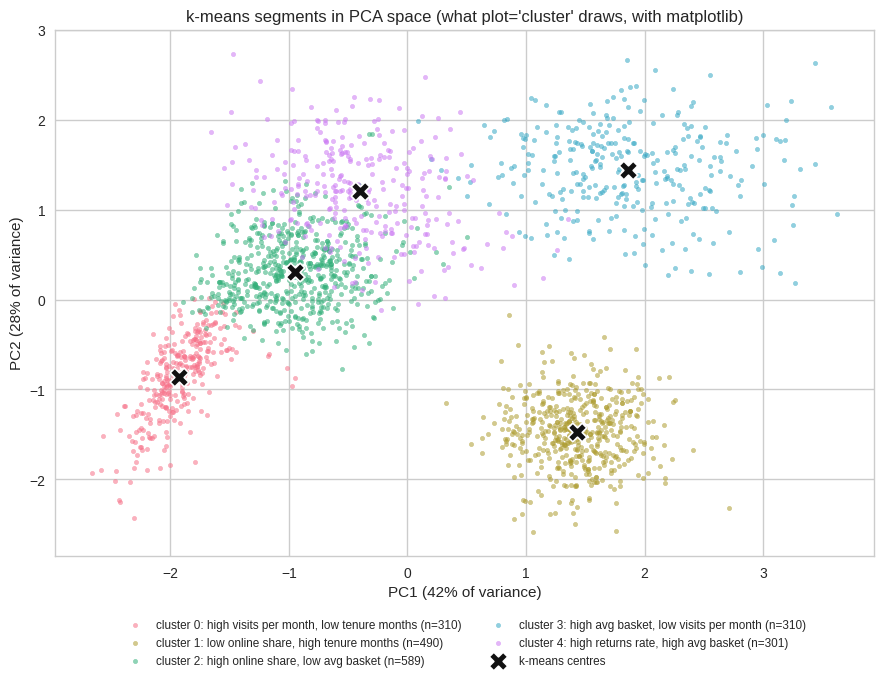

loadings (which habits each axis mixes):
                   PC1   PC2
visits_per_month -0.27 -0.67
avg_basket        0.45  0.49
online_share     -0.60  0.29
tenure_months     0.57 -0.28
returns_rate     -0.18  0.40


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xc)
Z = pca.transform(Xc); centres = pca.transform(km.cluster_centers_)
palette = sns.color_palette("husl", 5)
fig, ax = plt.subplots(figsize=(9, 7))
for c in sorted(segments["cluster"].unique()):
    m = (segments["cluster"] == c).values
    ax.scatter(Z[m, 0], Z[m, 1], s=10, alpha=0.55, color=palette[c], label=f"cluster {c}: {zprof.loc[c, 'suggested name']} (n={m.sum()})")
ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=180, color="k", edgecolor="w", lw=1.2, label="k-means centres", zorder=5)
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)", ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)",
       title="k-means segments in PCA space (what plot='cluster' draws, with matplotlib)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8.5)
plt.tight_layout(); plt.show()
loads = pd.DataFrame(pca.components_.T, index=Xc.columns, columns=["PC1", "PC2"]).round(2)
print("loadings (which habits each axis mixes):"); print(loads.to_string())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is a customer placed by its first two principal components (the two directions along which the z-scored habits vary most); the loadings printed underneath say what each axis mixes, so a large positive loading of `online_share` on PC1 means "moving right is more online". The black crosses are the k-means centres. Clusters that are separate islands here are separate in the full five-dimensional space too; clusters that overlap here may still be separated along a habit the picture threw away.

**The common misread:** judging the clustering by how neat the blobs look. PCA keeps the two largest directions of variance, which are not necessarily the directions that separate the segments; the silhouette plot above is computed in all five dimensions and is the fairer judge.

</div>


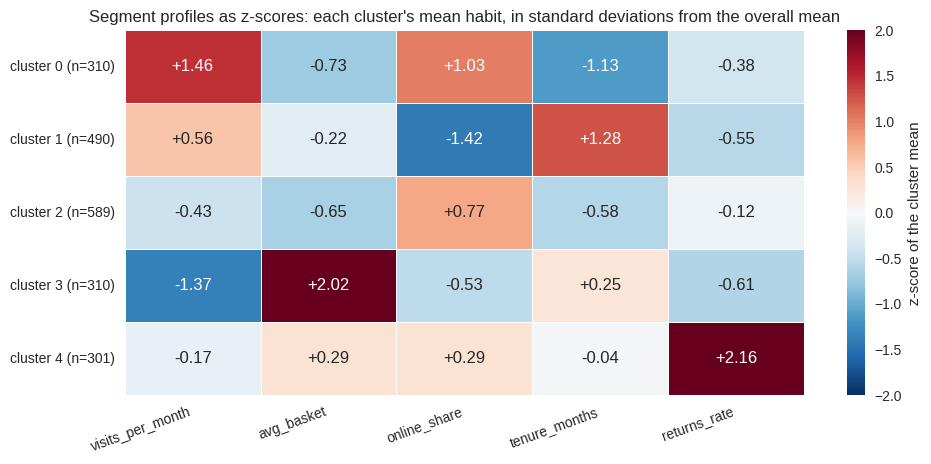

cluster 0: high visits per month, low tenure months  |  channel mix store/web/app = 5%/11%/84%, premium plan 9%
cluster 1: low online share, high tenure months  |  channel mix store/web/app = 72%/18%/10%, premium plan 20%
cluster 2: high online share, low avg basket  |  channel mix store/web/app = 9%/76%/15%, premium plan 5%
cluster 3: high avg basket, low visits per month  |  channel mix store/web/app = 49%/41%/10%, premium plan 44%
cluster 4: high returns rate, high avg basket  |  channel mix store/web/app = 16%/70%/14%, premium plan 12%


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.8))
heat = zprof[HABITS].copy(); heat.index = [f"cluster {c} (n={int(profile.loc[c, 'n'])})" for c in heat.index]
sns.heatmap(heat, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, vmin=-2, vmax=2, linewidths=0.5, cbar_kws={"label": "z-score of the cluster mean"}, ax=ax)
ax.set_title("Segment profiles as z-scores: each cluster's mean habit, in standard deviations from the overall mean")
ax.set_xlabel(""); ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout(); plt.show()
for c in zprof.index:
    print(f"cluster {c}: {zprof.loc[c, 'suggested name']}  |  channel mix store/web/app = "
          f"{profile.loc[c, 'channel=store']:.0%}/{profile.loc[c, 'channel=web']:.0%}/{profile.loc[c, 'channel=app']:.0%}, premium plan {profile.loc[c, 'plan=premium']:.0%}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One row per cluster, one column per habit, colour and number both the z-score of the cluster's mean. Red is "more than the average customer", blue is "less"; white is ordinary. Reading across a row gives the segment's fingerprint and the machine-suggested name printed under the chart; reading down a column shows which habit separates the segments most (the column with the strongest colours). The channel and plan mix printed per cluster, which the model never saw, is the sanity check that the fingerprints correspond to real groups of people.

**The common misread:** reading a +2 as "twice as much". It is two standard deviations above the overall mean; the profile table in 6.4 has the actual units (visits, currency, months).

</div>

## 6.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Clustering: when there are no labels and the segments must be named

- **Use it** for segmentation, for exploring a new table before any target exists, and as a feature (`assign_model`'s `Cluster` column) for a later supervised model. Cost: seconds for thousands of rows, minutes for millions; `hclust` is quadratic in memory and stops being practical around a hundred thousand rows.
- **k-means** for round, similar-sized groups on numeric habits; **hclust** when a tree of segments is wanted or the groups are elongated; **dbscan** when noise rows must be separated and the number of groups is unknown, at the price of choosing `eps`.
- **Judge by the profile and a held-back variable**, then by silhouette; never by silhouette alone, and never across different $k$ or different noise handling.

**The one gotcha:** distances. Every choice that changes the distance (scaling, one-hot columns, a log transform of a skewed habit) changes the clusters more than the choice of algorithm does. Decide the feature space first, the algorithm second.

</div>

## 6.7 Task 7 Summary

**✅ Key Takeaways**
- `ClusteringExperiment().setup(df, normalize=True)` → `create_model(id, num_clusters=k)` → `pull()` (silhouette, Calinski-Harabasz, Davies-Bouldin) → `assign_model` (the `Cluster` column).
- The elbow and silhouette curves narrow $k$; the z-score profile names the segments; a held-back variable (here the planted one, in practice channel, plan or revenue) is the only honest validation.
- One-hot dummies in the distance hijack k-means; keep categoricals out with `ignore_features=` and profile them afterwards.
- `hclust` and `dbscan` are one-line swaps whose metrics are not comparable to k-means when $k$ or the noise handling differ.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `customers`, `true_segment`, `HABITS`, `SEGMENTS`, `make_customers()` | the table, its hidden planted segment, the five habit columns, the generator |
| `clu`, `Xc` | the `ClusteringExperiment` on the habits only, and its z-scored matrix |
| `km`, `km_metrics`, `segments` | k-means (k=5), its metric row, the rows with `Cluster` / `cluster` columns |
| `hc`, `db`, `clu_ohe`, `km_ohe`, `labels`, `algo_table` | hierarchical, DBSCAN, the one-hot experiment, every labelling, the comparison table with ARI |
| `profile`, `zprof`, `auto_name()` | the cluster profile in units and in z-scores, with a suggested name each |
| `sil_by_k`, `pca`, `Z`, `loads`, `heat` | the silhouette sweep, the PCA projection, its loadings, the heatmap table |

**➡️ Next Up:** Part 7 keeps the labels away and asks the opposite question: which rows are *unlike* everything else?


# Part 7 · Anomaly Detection · Transaction Outliers ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### No labels, only "does this row look strange?"

Part 5 had a `fraud` column and trained a classifier. This Part has **no label at all**. `pycaret.anomaly` scores every row by how unusual it is and flags the strangest few, which is the situation of any new screening problem: the fraud team has not investigated anything yet, the factory has not tagged defects, the log has never been reviewed. Same grammar as before: `setup → create_model → assign_model`, and the output is a score column, not a class.

</div>

# Task 8 · Score every transaction by how unusual it is

## 7.1 ❓ The problem

A card issuer processes thousands of transactions a day and wants a **daily review list**: the 3% of transactions that look least like the rest, ranked, for a human to check. Nobody has labelled anything yet, so a classifier is not possible. The question to the model is "which rows are hard to explain by the bulk of the data?", and a good answer changes which cases the reviewers open first.

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: how quickly can a row be isolated?

The **Isolation Forest** (`iforest`) plays a game: pick a random feature, pick a random split value, repeat until the row sits alone. A row deep inside the crowd takes many splits to isolate; a strange row takes few. The average number of splits over many random trees becomes the **anomaly score**. Two other detectors take other routes: the **local outlier factor** (`lof`) compares a row's local density with that of its neighbours, and the **k-nearest-neighbours** detector (`knn`) uses the distance to the $k$-th nearest neighbour directly. All three come from the `pyod` library that PyCaret wraps.

</div>


## 7.2 📥 The input

A feature table **without a target**. The generator plants a small share of anomalies (very large amounts, at odd hours, far from home, in a burst of activity) and keeps that flag in a separate Series, `planted`, which the model never sees. It is the partial ground truth used later to measure precision at $k$.


📥 transactions (no label column): 5,000 rows x 5 columns


,amount,hour,merchant_category,distance_km,txn_last_hour
0,37.09,13,online,0.2,0
1,14.47,13,grocery,6.9,2
2,50.67,11,online,13.4,0
3,57.88,16,grocery,11.9,0
4,7.65,15,fuel,5.8,2


column types: {'amount': 'numeric', 'hour': 'numeric', 'merchant_category': 'text/category', 'distance_km': 'numeric', 'txn_last_hour': 'numeric'}
planted anomalies kept aside for evaluation: 150 of 5000 (3.0%)


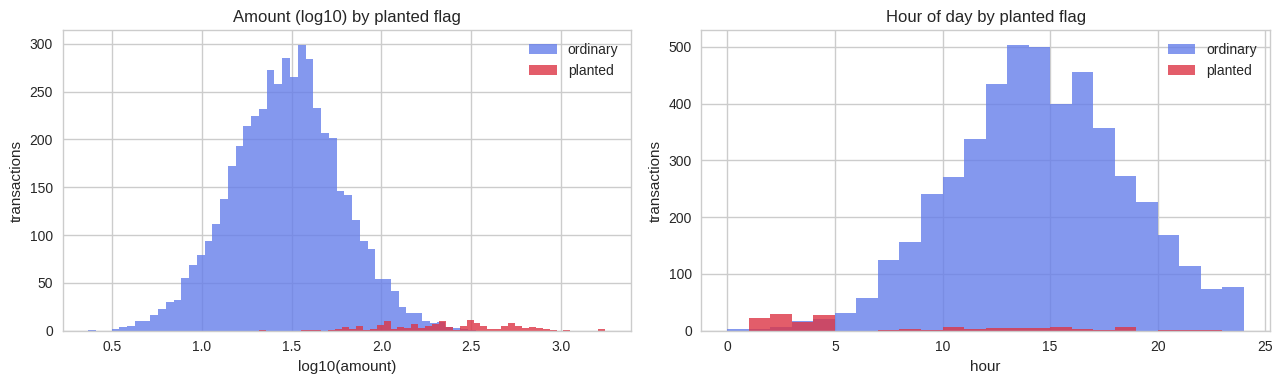

the model will see the five feature columns only; 'planted' is never passed to setup()


In [ ]:
def make_transactions(n=5000, planted_share=0.03, seed=RANDOM_STATE):
    """Card transactions: amount, hour, merchant_category, distance_km, txn_last_hour. Returns (features, planted flag)."""
    rng = np.random.default_rng(seed)
    n_bad = int(n * planted_share)
    amount = rng.lognormal(mean=3.4, sigma=0.7, size=n)                     # median ~30, long right tail
    hour = np.clip(rng.normal(14, 4.0, size=n), 0, 23).round().astype(int)   # daytime shopping
    merchant = rng.choice(["grocery", "fuel", "restaurant", "online", "travel", "pharmacy"], size=n, p=[.3, .15, .2, .2, .05, .1])
    distance = rng.exponential(scale=6.0, size=n)                            # km from home, mostly near
    burst = rng.poisson(lam=0.6, size=n)                                     # other transactions in the last hour
    bad = rng.choice(n, size=n_bad, replace=False)
    amount[bad] *= rng.uniform(3, 12, size=n_bad)                            # large amounts (3 to 12 times the usual)
    odd = rng.random(n_bad) < 0.6                                            # only 60% of them happen at odd hours ...
    hour[bad[odd]] = rng.integers(1, 5, size=odd.sum())                      # ... 1 am to 4 am
    distance[bad] = rng.uniform(40, 1200, size=n_bad)                        # far from home, some only moderately
    burst[bad] = rng.integers(2, 7, size=n_bad)                              # a burst of activity
    df = pd.DataFrame({"amount": amount.round(2), "hour": hour, "merchant_category": merchant,
                       "distance_km": distance.round(1), "txn_last_hour": burst})
    planted = pd.Series(np.isin(np.arange(n), bad).astype("int64"), name="planted")
    return df, planted

txn, planted = make_transactions()
show_input(txn, name="transactions (no label column)")
print(f"planted anomalies kept aside for evaluation: {planted.sum()} of {len(planted)} ({planted.mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.log10(txn.amount[planted == 0]), bins=50, color="#667eea", alpha=0.8, label="ordinary")
axes[0].hist(np.log10(txn.amount[planted == 1]), bins=50, color="#dc3545", alpha=0.8, label="planted")
axes[0].set_title("Amount (log10) by planted flag"); axes[0].set_xlabel("log10(amount)"); axes[0].set_ylabel("transactions"); axes[0].legend()
axes[1].hist(txn.hour[planted == 0], bins=24, range=(0, 24), color="#667eea", alpha=0.8, label="ordinary")
axes[1].hist(txn.hour[planted == 1], bins=24, range=(0, 24), color="#dc3545", alpha=0.8, label="planted")
axes[1].set_title("Hour of day by planted flag"); axes[1].set_xlabel("hour"); axes[1].set_ylabel("transactions"); axes[1].legend()
plt.tight_layout(); plt.show()
print("the model will see the five feature columns only; 'planted' is never passed to setup()")


| Column | Type | Meaning |
|---|---|---|
| `amount` | numeric | transaction value; long right tail, planted rows are 3 to 12 times larger |
| `hour` | numeric | hour of day 0-23; most planted rows sit at 1 am to 4 am |
| `merchant_category` | category (6 values) | one-hot encoded by `setup` |
| `distance_km` | numeric | distance from the home address |
| `txn_last_hour` | numeric | how many other transactions the card made in the previous hour |

`setup()` will infer four numeric columns and one categorical, impute nothing (there are no gaps), one-hot encode the category (the anomaly module reports `Maximum one-hot encoding: -1`, meaning every categorical is one-hot encoded whatever its cardinality) and, because `normalize=True` is passed, z-score every column. Normalising matters here: `lof` and `knn` are distance-based, and without it `amount` (hundreds) would drown `txn_last_hour` (single digits).

## 7.3 💻 One-line calls

`AnomalyExperiment().setup(data=...)` takes no target. `create_model("iforest", fraction=0.03)` fits the Isolation Forest and sets the flagging threshold so that 3% of rows are marked; `assign_model` returns the input rows plus two columns, `Anomaly` (0/1) and `Anomaly_Score`.


In [ ]:
sig = inspect.signature(AnomalyExperiment.setup)
print("setup arguments used are real:", all(k in sig.parameters for k in ["data", "normalize", "session_id", "n_jobs", "verbose", "html"]))

ano = AnomalyExperiment()
with timer("anomaly setup"):
    ano.setup(data=txn, normalize=True, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
print(ano.pull().to_string(index=False))
print("\ndetectors available:", ano.models().index.tolist())


setup arguments used are real: True
⏱️ anomaly setup: 0.2 s
             Description                Value
              Session id                   42
     Original data shape            (5000, 5)
  Transformed data shape           (5000, 10)
        Numeric features                    4
    Categorical features                    1
              Preprocess                 True
         Imputation type               simple
      Numeric imputation                 mean
  Categorical imputation                 mode
Maximum one-hot encoding                   -1
         Encoding method                 None
               Normalize                 True
        Normalize method               zscore
                CPU Jobs                    2
                 Use GPU                False
          Log Experiment                False
         Experiment Name anomaly-default-name
                     USI                 617e

detectors available: ['abod', 'cluster', 'cof', 'iforest', 'histo

In [ ]:
FRACTION = 0.03
with timer("iforest fit + assign"):
    iso = ano.create_model("iforest", fraction=FRACTION)
    iso_rows = ano.assign_model(iso)                         # the input rows + Anomaly (0/1) + Anomaly_Score
print("underlying estimator:", iso)
print("columns added by assign_model:", [c for c in iso_rows.columns if c not in txn.columns])
print(f"flagged: {iso_rows.Anomaly.sum()} rows = {iso_rows.Anomaly.mean():.1%} (fraction={FRACTION} by construction)")
print("\nthe five highest-scored transactions:")
display(iso_rows.sort_values("Anomaly_Score", ascending=False).head(5).round(3))


⏱️ iforest fit + assign: 0.9 s
underlying estimator: IForest(behaviour='new', bootstrap=False, contamination=0.03,
    max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=2,
    random_state=42, verbose=0)
columns added by assign_model: ['Anomaly', 'Anomaly_Score']
flagged: 150 rows = 3.0% (fraction=0.03 by construction)

the five highest-scored transactions:


,amount,hour,merchant_category,distance_km,txn_last_hour,Anomaly,Anomaly_Score
2287,1641.369995,1,restaurant,848.900024,5,1,0.149
1053,1759.189941,22,pharmacy,1037.800049,6,1,0.142
1345,837.719971,2,restaurant,567.000000,6,1,0.141
4462,707.729980,1,grocery,965.799988,4,1,0.141
2997,1086.449951,4,restaurant,982.200012,4,1,0.139


## 7.4 📤 The output

The output of an anomaly detector is a **ranking**. `Anomaly_Score` is the ranking; `Anomaly` is the ranking cut at `fraction`. The cell below runs two more detectors with the same `fraction`, measures how much their flagged sets overlap (the **Jaccard index**, $|A \cap B| / |A \cup B|$, 1 for identical sets and 0 for disjoint ones), and scores each ranking against the planted flag with **precision at $k$**: the share of the $k$ highest-scored rows that are planted anomalies. Precision at $k$ is the right metric when only the top of the list will ever be reviewed.


In [ ]:
detectors = {"iforest": iso_rows}
with timer("lof + knn"):
    for name in ["lof", "knn"]:
        detectors[name] = ano.assign_model(ano.create_model(name, fraction=FRACTION))
flags = {k: set(np.flatnonzero(v.Anomaly.values == 1)) for k, v in detectors.items()}
names = list(flags)
jac = pd.DataFrame([[len(flags[a] & flags[b]) / len(flags[a] | flags[b]) for b in names] for a in names], index=names, columns=names)

def precision_at_k(score, truth, k):
    top = np.argsort(-np.asarray(score))[:k]
    return float(np.asarray(truth)[top].mean())

ks = [50, 100, 150, 300]
pak = pd.DataFrame({name: [precision_at_k(det.Anomaly_Score.values, planted.values, k) for k in ks] for name, det in detectors.items()},
                   index=[f"precision@{k}" for k in ks])
pak["random"] = planted.mean()
print("Jaccard overlap of the flagged sets (same fraction):")
display(pretty(jac, fmt="{:.2f}"))
print("\nprecision at k against the planted flag (150 planted rows):")
display(pretty(pak, subset=names))
all3 = flags["iforest"] & flags["lof"] & flags["knn"]
print(f"flagged by all three detectors: {len(all3)} rows | best precision@150: {pak.loc['precision@150', names].idxmax()} = {pak.loc['precision@150', names].max():.2f}")


⏱️ lof + knn: 2.2 s
Jaccard overlap of the flagged sets (same fraction):


,iforest,lof,knn
iforest,1.00,0.12,0.94
lof,0.12,1.00,0.13
knn,0.94,0.13,1.00



precision at k against the planted flag (150 planted rows):


,iforest,lof,knn,random
precision@50,1.000,0.500,0.980,0.030
precision@100,1.000,0.300,0.990,0.030
precision@150,0.967,0.213,0.953,0.030
precision@300,0.500,0.120,0.497,0.030


flagged by all three detectors: 30 rows | best precision@150: iforest = 0.97


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `fraction` is an assumption, not a measurement

`fraction=0.03` did not discover that 3% of transactions are strange; it *decided* it. Here the generator happened to plant 3%, so the cut lands well; in real data the true share is unknown and the honest deliverable is the **ranked list** with the cut stated as a policy ("we review the top 150 a day"). Notice also that `lof` agrees least with the other two in the Jaccard table: it looks for rows that are sparse *relative to their neighbourhood*, which can be near the centre of the data, while `iforest` and `knn` both look for rows far from the bulk. Disagreement between detectors is information about what "strange" means, not a bug.

</div>

## 7.5 📊 The picture

PyCaret's own anomaly pictures, `plot_model(plot="tsne")` and `plot="umap"`, are interactive Plotly figures that need a browser, so they are **not run here**. The two panels below are drawn with matplotlib from the same numbers: the score histogram with the `fraction` cut, and the two features that matter most with the flagged rows on top.


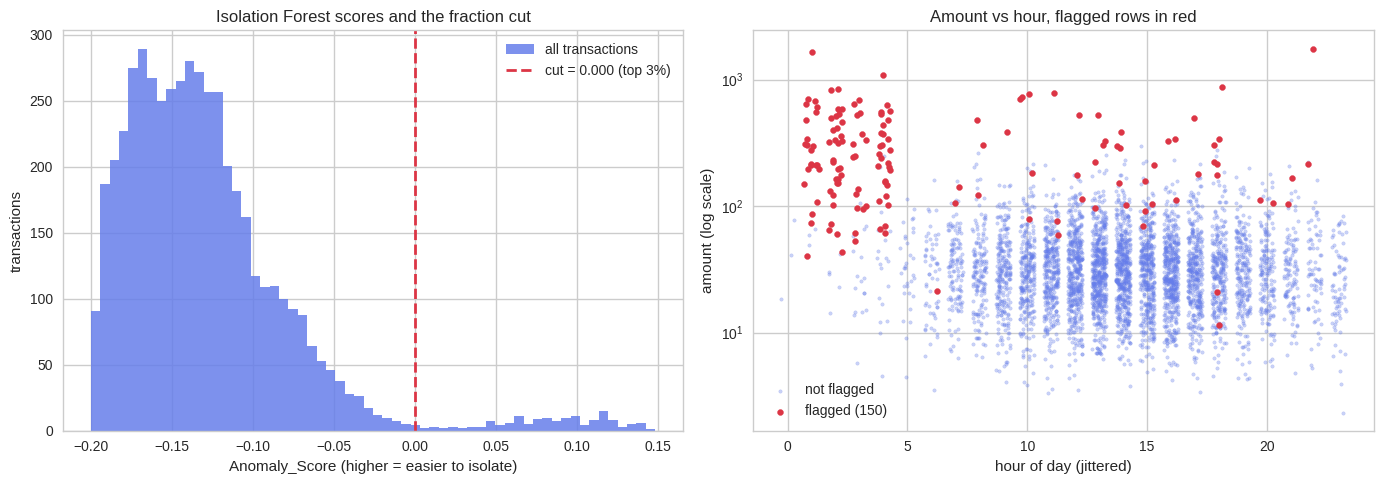

of the 150 flagged rows, 145 are planted anomalies and 5 are ordinary rows that happen to be extreme; 5 planted rows were missed


In [ ]:
flag = iso_rows.Anomaly.values == 1
cut = iso_rows.loc[flag, "Anomaly_Score"].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(iso_rows.Anomaly_Score, bins=60, color="#667eea", alpha=0.85, label="all transactions")
axes[0].axvline(cut, color="#dc3545", ls="--", lw=2, label=f"cut = {cut:.3f} (top {FRACTION:.0%})")
axes[0].set_title("Isolation Forest scores and the fraction cut"); axes[0].set_xlabel("Anomaly_Score (higher = easier to isolate)"); axes[0].set_ylabel("transactions"); axes[0].legend()
axes[1].scatter(txn.hour[~flag] + np.random.uniform(-0.3, 0.3, (~flag).sum()), txn.amount[~flag], s=6, alpha=0.35, color="#667eea", label="not flagged")
axes[1].scatter(txn.hour[flag] + np.random.uniform(-0.3, 0.3, flag.sum()), txn.amount[flag], s=18, color="#dc3545", label=f"flagged ({flag.sum()})")
axes[1].set_yscale("log"); axes[1].set_title("Amount vs hour, flagged rows in red"); axes[1].set_xlabel("hour of day (jittered)"); axes[1].set_ylabel("amount (log scale)"); axes[1].legend()
plt.tight_layout(); plt.show()
tp = int(planted.values[flag].sum())
print(f"of the {flag.sum()} flagged rows, {tp} are planted anomalies and {flag.sum() - tp} are ordinary rows that happen to be extreme; {int(planted.sum()) - tp} planted rows were missed")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the score distribution is one hump with a right tail, and the dashed line is wherever the top 3% begins. Nothing in the shape singles out that line; a different `fraction` would move it and flag a different set with equal confidence. Right: the flagged rows sit in the corner where large amounts meet small hours, exactly where the generator put the planted anomalies, plus a few ordinary rows with an unusually large amount at a normal hour. The printed line counts hits, false alarms and misses against the planted flag.

The common misread: reading the red points as "the fraud". They are the rows that are *easiest to isolate* on these five features. A fraudster who keeps amounts ordinary and shops at noon is invisible to this detector, and an honest traveller buying a flight at 2 am is not.

</div>


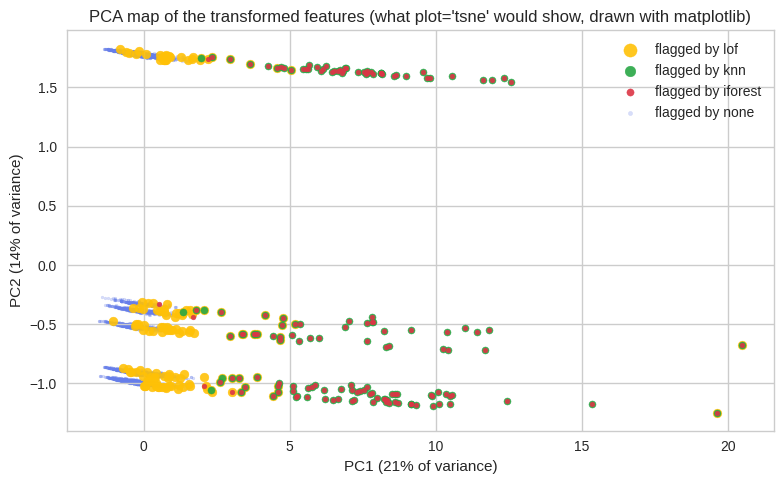

PC1 loadings: {'amount': 0.55, 'hour': -0.32, 'merchant_category_online': -0.01, 'merchant_category_grocery': 0.02, 'merchant_category_fuel': -0.04, 'merchant_category_pharmacy': 0.01, 'merchant_category_travel': 0.01, 'merchant_category_restaurant': 0.01, 'distance_km': 0.59, 'txn_last_hour': 0.5}


In [ ]:
from sklearn.decomposition import PCA

Xa = ano.get_config("X_transformed")                 # the normalised, one-hot encoded matrix setup() built
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xa)
Z = pca.transform(Xa)
fig, ax = plt.subplots(figsize=(8, 5))
for name, col, size in [("lof", "#ffc107", 40), ("knn", "#28a745", 26), ("iforest", "#dc3545", 12)]:
    m = np.zeros(len(Z), dtype=bool); m[list(flags[name])] = True
    ax.scatter(Z[m, 0], Z[m, 1], s=size, color=col, label=f"flagged by {name}", alpha=0.9)
rest = np.ones(len(Z), dtype=bool); rest[list(flags["iforest"] | flags["lof"] | flags["knn"])] = False
ax.scatter(Z[rest, 0], Z[rest, 1], s=4, alpha=0.25, color="#667eea", label="flagged by none", zorder=0)
ax.set_title("PCA map of the transformed features (what plot='tsne' would show, drawn with matplotlib)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)"); ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)"); ax.legend(markerscale=1.5)
plt.tight_layout(); plt.show()
print("PC1 loadings:", dict(zip(Xa.columns, np.round(pca.components_[0], 2))))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every transaction projected onto the two directions of largest variance in the normalised feature matrix. The planted anomalies form a detached cloud (large amount, small hour, large distance and burst all pull the same way, as the PC1 loadings show). `iforest` and `knn` flag that cloud almost completely, which is why their Jaccard overlap is high and their precision at $k$ is near 1. `lof` mostly does not: inside a cloud of 150 similar rows each row has neighbours of similar density, so its *local* outlier factor is ordinary, and `lof` spends its 3% on thin spots inside the main bulk instead. Same `fraction`, a different definition of strange, a different list.

The common misread: calling `lof` broken because its precision against the planted flag is low. It answers a different question ("is this row sparse *for its neighbourhood*?"), which is the right one when anomalies hide inside dense regions, for example a duplicate charge at a normal hour and amount. Pick the detector whose definition matches the anomaly you expect, and re-measure precision at $k$ once reviewers return labels.

</div>

## 7.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Unlabelled screening: fraud, defects, sensor faults, log lines

- **Reach for `pycaret.anomaly`** when there is a feature table, no labels, and a budget of cases a person can review. It gives a ranked list in three calls and twelve detectors to try with one string each.
- **What it costs:** seconds on thousands of rows; `lof` and `knn` grow with the square of the row count and need `normalize=True`. Nothing in the output is calibrated: a score of 0.6 is not a probability.
- **The gotcha:** `fraction` is an assumption. Report the ranking, state the cut, and measure precision at $k$ against whatever partial truth exists (planted cases, past investigations, a known defect rate). Once reviewers send labels back, Part 5's supervised route takes over.
- **Not this:** if labels exist, even a few hundred, a classifier with `fix_imbalance=True` (Part 5) will beat any unsupervised score.

</div>

## 7.7 Task 8 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Input: a feature table with no target; output: `Anomaly_Score` (a ranking) and `Anomaly` (the ranking cut at `fraction`).
- `AnomalyExperiment().setup(data, normalize=True) → create_model("iforest", fraction=0.03) → assign_model(...)`.
- `iforest`, `lof` and `knn` are one-string swaps; their Jaccard overlap says how much "strange" depends on the definition.
- Evaluate with precision at $k$ against a partial ground truth; here the planted flag the model never saw.
- `plot_model(plot="tsne")` / `"umap"` are Plotly and need a browser; a PCA map with matplotlib shows the same geometry anywhere.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `txn`, `planted` | the 5,000-row feature table and the hidden planted flag |
| `ano`, `iso`, `iso_rows`, `FRACTION` | the `AnomalyExperiment`, the Isolation Forest, its assigned rows, the cut |
| `detectors`, `flags`, `jac`, `pak` | assigned rows per detector, flagged index sets, their Jaccard overlap, precision at k |
| `Xa`, `Z` | the transformed feature matrix and its 2-D PCA projection |

### ➡️ Next Up

Part 8 changes the shape of the input entirely: one column indexed by time, plus a known driver, and the question "how many units next week?".

</div>


# Part 8 · Time Series · Store Demand with Exogenous Promos ⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Same grammar, time-aware rules

`pycaret.time_series` keeps `setup → compare_models → predict_model`, but underneath everything obeys time: the test set is the **last** `fh` days, cross-validation uses **expanding windows** that always end before the fold they score, and the baselines to beat are "repeat yesterday" and "repeat last week". The module is built on `sktime`. This Part adds one thing the lifecycle notebook did not: an **exogenous** column, a driver the store controls (promotions), which the forecast must take as an input for the days ahead.

</div>

# Task 9 · Forecast fourteen days of demand, promotions included

## 8.1 ❓ The problem

A store manager orders stock two weeks ahead and already knows which of those days will run a promotion. The question is "how many units per day for the next 14 days, **given** the promo calendar?", with a range, not just a number. A good answer changes the order quantity and, on promo days, prevents an empty shelf. This Part runs only when the time-series module imported (`TS_OK`); it needs `sktime`, which `pip install pycaret[models]` brings in.

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: an exogenous variable is a known future

A forecaster extends the past of one series. An **exogenous** variable (from *exo*, outside) is a second column that helps explain the series and whose **future values are known** when the forecast is made: a promo calendar, a public holiday, a planned price. The model learns "a promo day adds about this many units" from history and, at prediction time, is handed the promo plan for the days ahead. A variable whose future is *not* known (tomorrow's weather, competitor prices) is not exogenous in this sense; using it would require forecasting it first.

</div>

### 📐 The Math (gently): MASE

$$ \text{MASE} = \frac{\frac{1}{h}\sum_{t=1}^{h} |y_{T+t} - \hat{y}_{T+t}|}{\frac{1}{T-1}\sum_{t=2}^{T} |y_t - y_{t-1}|} $$

The mean absolute error of the forecast over the horizon $h$, divided by the in-sample mean absolute error of the one-step **naive** forecast ("repeat yesterday"). Below 1 beats naive on average; it is unit-free and is the first column to read in every table of this Part. RMSSE is the same idea with squared errors; MAPE and SMAPE are percentage errors, easy to read and unstable when the series passes near zero.


## 8.2 📥 The input

A `DataFrame` with a daily `DatetimeIndex` (frequency `D`), the target `units` and one extra column `promo` (0/1). In `pycaret.time_series` 3.3, **every non-target column in `data` is treated as exogenous**; the setup summary reports `Exogenous Variables: Present`. The generator plants weekly seasonality (weekends sell more), a yearly wave, a slow upward drift and a fixed lift on promo days.


📥 daily store demand: 730 rows x 3 columns


,date,units,promo
0,2024-01-01,223.0,0
1,2024-01-02,218.0,0
2,2024-01-03,209.0,0
3,2024-01-04,221.0,0
4,2024-01-05,235.0,0


column types: {'date': 'datetime64[ns]', 'units': 'numeric', 'promo': 'numeric'}
index: DatetimeIndex, freq=D, 2024-01-01 to 2025-12-30 | promo days: 50 (6.8%)
raw promo lift (mean on promo days minus mean on other days): +59.0 units; planted lift = 60


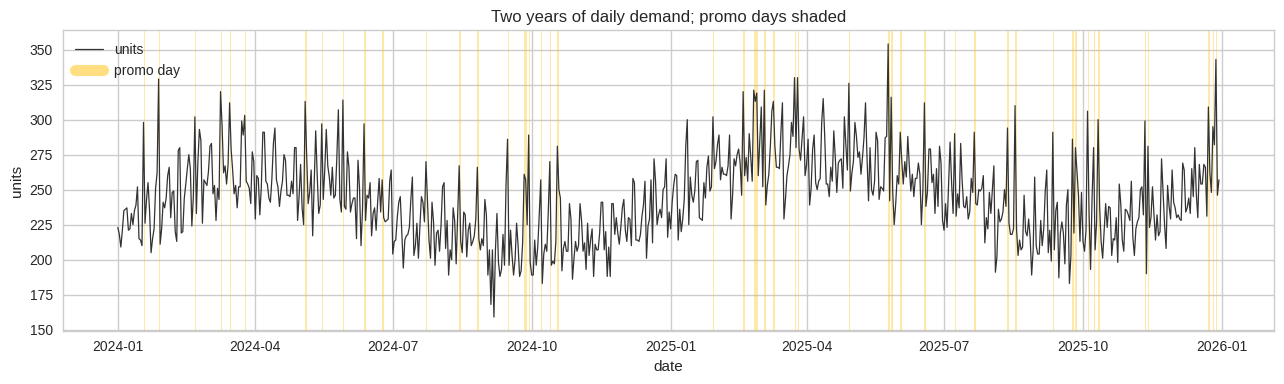

weekday means: {0: 229.0, 1: 239.0, 2: 239.0, 3: 237.0, 4: 239.0, 5: 264.0, 6: 264.0} (0 = Monday)


In [ ]:
def make_demand(days=365 * 2, promo_share=0.08, promo_lift=60, seed=RANDOM_STATE):
    """One store's daily units with weekly + yearly seasonality, drift, and a 0/1 promo column that lifts demand."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2024-01-01", periods=days, freq="D")
    t = np.arange(days)
    promo = (rng.random(days) < promo_share).astype(int)
    weekday = np.where(idx.dayofweek >= 5, 25, np.where(idx.dayofweek == 0, -10, 0))        # weekend up, Monday down
    units = 220 + 0.04 * t + 30 * np.sin(2 * np.pi * t / 365.25) + weekday + promo_lift * promo + rng.normal(0, 12, days)
    return pd.DataFrame({"units": np.clip(units, 0, None).round(0), "promo": promo.astype("int64")}, index=idx)

demand = make_demand()
show_input(demand.reset_index().rename(columns={"index": "date"}), name="daily store demand")
print(f"index: {type(demand.index).__name__}, freq={demand.index.freqstr}, {demand.index[0].date()} to {demand.index[-1].date()} | promo days: {demand.promo.sum()} ({demand.promo.mean():.1%})")
lift = demand.units[demand.promo == 1].mean() - demand.units[demand.promo == 0].mean()
print(f"raw promo lift (mean on promo days minus mean on other days): {lift:+.1f} units; planted lift = 60")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(demand.index, demand.units, color="#333", lw=0.9, label="units")
for d in demand.index[demand.promo == 1]:
    ax.axvspan(d, d + pd.Timedelta(days=1), color="#ffc107", alpha=0.35, lw=0)
ax.plot([], [], color="#ffc107", lw=8, alpha=0.5, label="promo day")
ax.set_title("Two years of daily demand; promo days shaded"); ax.set_xlabel("date"); ax.set_ylabel("units"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
print("weekday means:", demand.units.groupby(demand.index.dayofweek).mean().round(0).to_dict(), "(0 = Monday)")


| Column | Role | Meaning |
|---|---|---|
| index | time | daily `DatetimeIndex`, no gaps (PyCaret needs a regular frequency) |
| `units` | **target** | units sold that day |
| `promo` | **exogenous** | 1 on promotion days; its future values must be supplied at forecast time |

## 8.3 💻 One-line calls

`TSForecastingExperiment().setup(data=demand, target="units", fh=14, fold=3, seasonal_period=7, ...)`: `fh=14` holds out the last 14 days as the test window and sets the forecast horizon; `fold=3` builds three expanding windows; `seasonal_period=7` states the weekly cycle (the automatic test would pick 14, a harmonic, so telling it is better). `enforce_exogenous=False` matters: by default, when exogenous columns are present, `models()` lists **only** forecasters that accept them, and the naive baselines vanish; with `False`, univariate models are kept and simply ignore `promo`, which puts both kinds in one table.


In [ ]:
if TS_OK:
    sig = inspect.signature(TSForecastingExperiment.setup)
    print("setup arguments used are real:", all(k in sig.parameters for k in ["data", "target", "fh", "fold", "seasonal_period", "enforce_exogenous", "session_id", "n_jobs", "verbose", "html"]))
    tsx = TSForecastingExperiment()
    with timer("time-series setup"):
        tsx.setup(data=demand, target="units", fh=14, fold=3, seasonal_period=7, enforce_exogenous=False,
                  session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
    setup_tbl = tsx.pull()
    keep = ["Target", "Approach", "Exogenous Variables", "Original data shape", "Transformed train set shape", "Transformed test set shape",
            "Fold Generator", "Fold Number", "Primary Seasonality", "Seasonality Type", "Recommended d"]
    print(setup_tbl[setup_tbl.Description.isin(keep)].to_string(index=False))
    print(f"\ny_train: {len(tsx.get_config('y_train'))} days | y_test: {len(tsx.get_config('y_test'))} days | X_train columns: {tsx.get_config('X_train').columns.tolist()}")
    stats = tsx.check_stats()
    print("\ncheck_stats(): summary statistics and the stationarity / white-noise tests")
    print(stats[stats.Test.isin(["Summary", "Stationarity"])][["Test", "Test Name", "Property", "Value"]].to_string(index=False))
else:
    print("pycaret.time_series did not import (needs sktime); Part 8 is skipped in this runtime.")


setup arguments used are real: True
⏱️ time-series setup: 1.2 s
                Description                   Value
                     Target                   units
                   Approach              Univariate
        Exogenous Variables                 Present
        Original data shape                (730, 2)
Transformed train set shape                (716, 2)
 Transformed test set shape                 (14, 2)
             Fold Generator ExpandingWindowSplitter
                Fold Number                       3
        Primary Seasonality                       7
           Seasonality Type                     mul
              Recommended d                       1

y_train: 716 days | y_test: 14 days | X_train columns: ['promo']

check_stats(): summary statistics and the stationarity / white-noise tests
        Test  Test Name            Property       Value
     Summary Statistics              Length       730.0
     Summary Statistics    # Missing Values         0.0
  

In [ ]:
if TS_OK:
    wanted = ["naive", "snaive", "ets", "exp_smooth", "theta", "arima", "lr_cds_dt", "lightgbm_cds_dt"]
    available = tsx.models().index.tolist()
    include = [m for m in wanted if m in available]
    print("include:", include, "| not in this install:", [m for m in wanted if m not in available])
    with timer("compare_models (8 forecasters x 3 expanding folds)"):
        best_ts = tsx.compare_models(include=include, fold=3, sort="MASE")
    cmp_ts = tsx.pull()
    dropped = [m for m in include if m not in cmp_ts.index]
    print(f"rows in the table: {len(cmp_ts)} of {len(include)} requested; silently dropped (errored during CV): {dropped}")
    display(pretty(cmp_ts.drop(columns=["Model"]), highlight="min", subset=["MASE", "RMSSE", "MAE", "RMSE", "MAPE", "SMAPE"]))
    best_id = cmp_ts.index[0]
    print("best by MASE:", best_id, "->", cmp_ts.loc[best_id, "Model"])
else:
    print("skipped: time-series module not available")


include: ['naive', 'snaive', 'ets', 'exp_smooth', 'theta', 'arima', 'lr_cds_dt', 'lightgbm_cds_dt'] | not in this install: []


                                                             Model    MASE   RMSSE      MAE     RMSE    MAPE   SMAPE      R2  TT (Sec)
lightgbm_cds_dt  Light Gradient Boosting w/ Cond. Deseasonalize...  0.6013  0.5647  11.9706  15.7964  0.0492  0.0506  0.2444    1.6700
ets                                                            ETS  0.6698  0.6596  13.3192  18.4059  0.0537  0.0554   0.197    0.1967
exp_smooth                                   Exponential Smoothing  0.6698  0.6596  13.3194  18.4058  0.0537  0.0554   0.197    0.2200
theta                                             Theta Forecaster   0.684  0.6794  13.6019  18.9609  0.0547  0.0566  0.1422    0.0600
lr_cds_dt               Linear w/ Cond. Deseasonalize & Detrending    0.73  0.6579  14.5273  18.3913  0.0604  0.0615  0.0589    0.4733
arima                                                        ARIMA  0.7961   0.769  15.8484   21.511  0.0649  0.0671 -0.4148    0.3233
snaive                                   Seasonal Naive

,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
lightgbm_cds_dt,0.601,0.565,11.971,15.796,0.049,0.051,0.244,1.670
ets,0.670,0.660,13.319,18.406,0.054,0.055,0.197,0.197
exp_smooth,0.670,0.660,13.319,18.406,0.054,0.055,0.197,0.220
theta,0.684,0.679,13.602,18.961,0.055,0.057,0.142,0.060
lr_cds_dt,0.730,0.658,14.527,18.391,0.060,0.061,0.059,0.473
arima,0.796,0.769,15.848,21.511,0.065,0.067,-0.415,0.323
snaive,0.992,0.996,19.738,27.844,0.080,0.083,-1.116,0.090
naive,1.282,1.136,25.500,31.721,0.101,0.110,-1.460,0.387


best by MASE: lightgbm_cds_dt -> Light Gradient Boosting w/ Cond. Deseasonalize & Detrending


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `compare_models` drops a model that errors, without saying so

Count the rows. The printed line lists any id that was requested but is missing from the table; in the environment this notebook was built in, `ets` fails inside `sktime` on some `statsmodels` versions (`simulate()` rejects `random_state`) and vanishes from the results. A table that is one row shorter than the `include=` list is easy to miss and easy to misreport as "ETS was worse". Always compare the table's index with the list you asked for, and keep `exp_smooth` in the list as the exponential-smoothing model that does not depend on that code path.

</div>

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 Reading the comparison table

| Column | What it is | Read it as |
|---|---|---|
| **MASE** | MAE scaled by the in-sample one-step naive MAE | below 1 beats "repeat yesterday" |
| **RMSSE** | RMSE scaled the same way | like MASE, big misses weigh more |
| **MAE**, **RMSE** | errors in units sold | for the store manager |
| **MAPE**, **SMAPE** | percentage errors; SMAPE symmetrises over- and under-forecast | easy to read, unstable near zero |
| **R2** | one minus error variance over series variance on each window | often negative on short windows; never rank by it |
| **TT (Sec)** | fit time | the price of the model |

Every value is the mean over the three expanding-window folds on the *training* part; the 14-day test window has not been touched yet. The `_cds_dt` models are scikit-learn regressors on lagged values after a conditional deseasonalise-and-detrend step, and they, with `arima`, are the rows that can read `promo`; `naive`, `snaive`, `exp_smooth` and `theta` cannot.

</div>

## 8.4 📤 The output

Two things come out: the **test-window score** of the best model (`predict_model` without new data forecasts the held-out 14 days, using the held-out `promo` values automatically, and `pull()` gives the metrics), and the **value of the exogenous column**, measured by fitting the same model once more on `units` alone.


In [ ]:
if TS_OK:
    y_train, y_test, X_test = tsx.get_config("y_train"), tsx.get_config("y_test"), tsx.get_config("X_test")
    test_fc = tsx.predict_model(best_ts, verbose=False)              # forecasts the held-out window; X_test (promo) is used automatically
    test_metrics_best = tsx.pull()
    print("forecast frame from predict_model (index is a PeriodIndex; y_pred in units):")
    display(test_fc.head(5))
    print("test-window metrics of the best model:"); print(test_metrics_best.to_string(index=False))

    # the same model family on units alone: what does 'promo' buy?
    with timer("univariate re-fit of the best model family"):
        tsu = TSForecastingExperiment()
        tsu.setup(data=demand[["units"]], target="units", fh=14, fold=3, seasonal_period=7, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
        uni_model = tsu.create_model(best_id, verbose=False); cv_uni = tsu.pull()
        tsu.predict_model(uni_model, verbose=False); test_uni = tsu.pull()
    cv_ex = cmp_ts.loc[best_id]
    promo_value = pd.DataFrame({
        "CV MASE (3 folds)": [cv_uni.loc["Mean", "MASE"], cv_ex["MASE"]],
        "CV MAE": [cv_uni.loc["Mean", "MAE"], cv_ex["MAE"]],
        "test MASE (14 days)": [test_uni["MASE"].iloc[0], test_metrics_best["MASE"].iloc[0]],
        "test MAE": [test_uni["MAE"].iloc[0], test_metrics_best["MAE"].iloc[0]],
    }, index=[f"{best_id} on units only", f"{best_id} with promo"]).astype(float)
    display(pretty(promo_value, highlight="min"))
    print(f"promo days inside the 14-day test window: {int(X_test.promo.sum())}")
else:
    print("skipped: time-series module not available")


forecast frame from predict_model (index is a PeriodIndex; y_pred in units):


,y_pred
2025-12-17,238.5809
2025-12-18,233.5837
2025-12-19,237.0652
2025-12-20,259.0034
2025-12-21,267.2109


test-window metrics of the best model:
        Model   MASE  RMSSE     MAE    RMSE   MAPE  SMAPE     R2
LGBMRegressor 0.5472 0.4974 10.8311 13.8514 0.0407  0.042 0.7551
⏱️ univariate re-fit of the best model family: 3.7 s


,CV MASE (3 folds),CV MAE,test MASE (14 days),test MAE
lightgbm_cds_dt on units only,0.686,13.650,1.031,20.401
lightgbm_cds_dt with promo,0.601,11.971,0.547,10.831


promo days inside the 14-day test window: 3


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: measure what the exogenous column is worth, and keep `naive` / `snaive` in the table

The two-row table is the argument for collecting the promo calendar: same model, same folds, same test window, one column more. When that gap is small, the driver is not worth the operational cost of supplying its future values every day. And the two naive rows in the comparison table are the scale of everything else; a forecaster that does not beat `snaive` by a clear margin on a weekly series should be replaced by `snaive`, which cannot overfit and needs no explanation.

</div>

## 8.5 📊 The picture

`plot_model(plot="forecast")` and `plot="diagnostics"` draw with Plotly (they write HTML, not PNG, when saved), so `render` cannot show them and they are **not run here**. The cells below draw the same content with matplotlib: history, the held-out window with the best model's forecast, and the **next 14 days** forecast from a finalized model handed the future promo plan through `X=`. Two details matter. First, the future `X` must carry a **`PeriodIndex`** (`pd.period_range(..., freq="D")`): PyCaret converts the data's `DatetimeIndex` to periods internally, and a `DatetimeIndex` `X` errors for `arima` and, worse, is silently **misaligned** by the reduction models, so the promo lift lands on the wrong days. Second, the `_cds_dt` reduction forecasters return no prediction interval (`lower` / `upper` come back `NaN`); `arima`, which also reads `promo`, does, so the shaded band comes from it whichever model won.


In [ ]:
if TS_OK:
    future_idx = pd.date_range(demand.index[-1] + pd.Timedelta(days=1), periods=14, freq="D")
    PLAN = [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]                                        # the promo plan the manager already knows
    future_promo = pd.DataFrame({"promo": PLAN}, index=future_idx.to_period("D"))            # PeriodIndex: the index type PyCaret uses internally
    pm_sig = inspect.signature(tsx.predict_model).parameters
    print("predict_model accepts X / return_pred_int / coverage:", all(k in pm_sig for k in ["X", "return_pred_int", "coverage"]))
    print("experiment index type:", type(tsx.get_config("y_train").index).__name__, "| future X index type:", type(future_promo.index).__name__)
    with timer("finalize best + arima, forecast 14 days ahead"):
        final_best = tsx.finalize_model(best_ts)                                     # refit on all 730 days
        fc_best = tsx.predict_model(final_best, X=future_promo, return_pred_int=True, verbose=False)
        arima = tsx.create_model("arima", verbose=False); arima_cv = tsx.pull()
        final_arima = tsx.finalize_model(arima)
        fc_arima = tsx.predict_model(final_arima, X=future_promo, return_pred_int=True, coverage=0.9, verbose=False)
    # the mistake: the same plan on a DatetimeIndex. ARIMA raises; the reduction models accept it and misalign the promo days.
    try:
        fc_wrong = tsx.predict_model(final_best, X=pd.DataFrame({"promo": PLAN}, index=future_idx), verbose=False)
        wrong_note = f"accepted, promo-day mean {fc_wrong.y_pred.values[np.array(PLAN) == 1].mean():.1f} vs {fc_best.y_pred.values[np.array(PLAN) == 1].mean():.1f} with the PeriodIndex (misaligned)"
    except Exception as err:
        wrong_note = f"raised {type(err).__name__} (the safe outcome)"
    print(f"DatetimeIndex X on {best_id}: {wrong_note}")
    fc_best.index = fc_best.index.to_timestamp(); fc_arima.index = fc_arima.index.to_timestamp()
    print(f"best model ({best_id}) returned an interval: {not fc_best[['lower', 'upper']].isna().all().all()} | arima returned an interval: {not fc_arima[['lower', 'upper']].isna().all().all()}")
    print("\nthe 14-day forecast frame (best model point forecast, ARIMA point forecast and 90% interval):")
    out = pd.DataFrame({"promo": PLAN, f"{best_id}": fc_best.y_pred.values,
                        "arima": fc_arima.y_pred.values, "arima_lower": fc_arima["lower"].values, "arima_upper": fc_arima["upper"].values}, index=future_idx.date)
    display(out.round(1))
    print(f"mean forecast on future promo days minus other days ({best_id}): {out.loc[out.promo == 1, best_id].mean() - out.loc[out.promo == 0, best_id].mean():+.1f} units (planted lift 60, on top of the weekday pattern)")
else:
    print("skipped: time-series module not available")


predict_model accepts X / return_pred_int / coverage: True
experiment index type: PeriodIndex | future X index type: PeriodIndex
⏱️ finalize best + arima, forecast 14 days ahead: 5.8 s
DatetimeIndex X on lightgbm_cds_dt: accepted, promo-day mean 276.3 vs 333.4 with the PeriodIndex (misaligned)
best model (lightgbm_cds_dt) returned an interval: False | arima returned an interval: True

the 14-day forecast frame (best model point forecast, ARIMA point forecast and 90% interval):


,promo,lightgbm_cds_dt,arima,arima_lower,arima_upper
2025-12-31,0,259.6,263.6,235.4,291.8
2026-01-01,0,256.2,248.5,220.0,277.0
2026-01-02,1,320.4,295.3,266.9,323.8
2026-01-03,1,341.5,344.1,315.6,372.6
2026-01-04,0,296.9,281.6,253.1,310.0
2026-01-05,0,258.5,246.3,217.8,274.8
2026-01-06,0,270.5,257.3,228.8,285.8
2026-01-07,0,263.4,264.0,223.9,304.0
2026-01-08,0,267.4,248.8,208.5,289.1
2026-01-09,0,268.5,233.9,193.6,274.2


mean forecast on future promo days minus other days (lightgbm_cds_dt): +65.3 units (planted lift 60, on top of the weekday pattern)


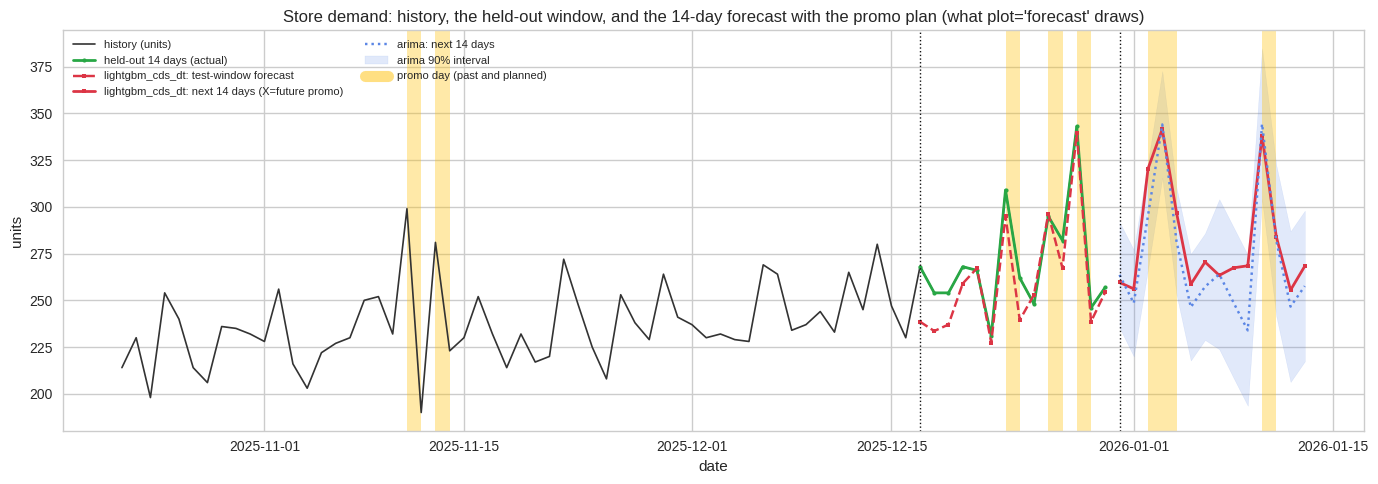

test-window MAE of lightgbm_cds_dt: 10.8 units | ARIMA CV MASE: 0.796 | interval width on day 1 vs day 14: 56 -> 81 units


In [ ]:
if TS_OK:
    hist = demand.iloc[-70:]                                      # the last ten weeks of history, for readability
    t_test = y_test.index.to_timestamp(); fc_test = test_fc.copy(); fc_test.index = fc_test.index.to_timestamp()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(hist.index, hist.units, color="#333", lw=1.2, label="history (units)")
    ax.plot(t_test, y_test.values, color="#28a745", lw=2, marker="o", ms=3, label="held-out 14 days (actual)")
    ax.plot(fc_test.index, fc_test.y_pred, color="#dc3545", ls="--", marker="s", ms=3, label=f"{best_id}: test-window forecast")
    ax.plot(fc_best.index, fc_best.y_pred, color="#dc3545", lw=2, marker="s", ms=3, label=f"{best_id}: next 14 days (X=future promo)")
    ax.plot(fc_arima.index, fc_arima.y_pred, color="#5b86e5", ls=":", label="arima: next 14 days")
    ax.fill_between(fc_arima.index, fc_arima["lower"], fc_arima["upper"], color="#5b86e5", alpha=0.18, label="arima 90% interval")
    for d in list(hist.index[hist.promo == 1]) + list(future_idx[np.array(PLAN) == 1]):
        ax.axvspan(d, d + pd.Timedelta(days=1), color="#ffc107", alpha=0.35, lw=0)
    ax.plot([], [], color="#ffc107", lw=8, alpha=0.5, label="promo day (past and planned)")
    ax.axvline(t_test[0], color="k", ls=":", lw=1); ax.axvline(future_idx[0], color="k", ls=":", lw=1)
    ax.set_title("Store demand: history, the held-out window, and the 14-day forecast with the promo plan (what plot='forecast' draws)")
    ax.set_xlabel("date"); ax.set_ylabel("units"); ax.legend(loc="upper left", fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()
    print(f"test-window MAE of {best_id}: {test_metrics_best['MAE'].iloc[0]:.1f} units | ARIMA CV MASE: {arima_cv.loc['Mean', 'MASE']:.3f} | interval width on day 1 vs day 14: "
          f"{(fc_arima['upper'] - fc_arima['lower']).iloc[0]:.0f} -> {(fc_arima['upper'] - fc_arima['lower']).iloc[-1]:.0f} units")
else:
    print("skipped: time-series module not available")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Black is the last ten weeks of history with promo days shaded; the weekly sawtooth (weekends up, Mondays down) is visible. Between the two dotted lines is the held-out window: green actuals against the red dashed forecast the best model made from the training cut, using the known promo flags of those days. After the second dotted line is the real product: fourteen days that have not happened, forecast by the model refit on everything, with the planned promo days shaded and the forecast stepping up on exactly those days. The blue band is ARIMA's 90% interval; the printed widths show it widening with the horizon.

The common misread: reading the red line's promo bumps as a prediction of the promo. They are a *consequence of an input*: the model was told the plan through `X=future_promo`. Change the plan and the forecast changes with it, which is the whole point of an exogenous variable.

</div>


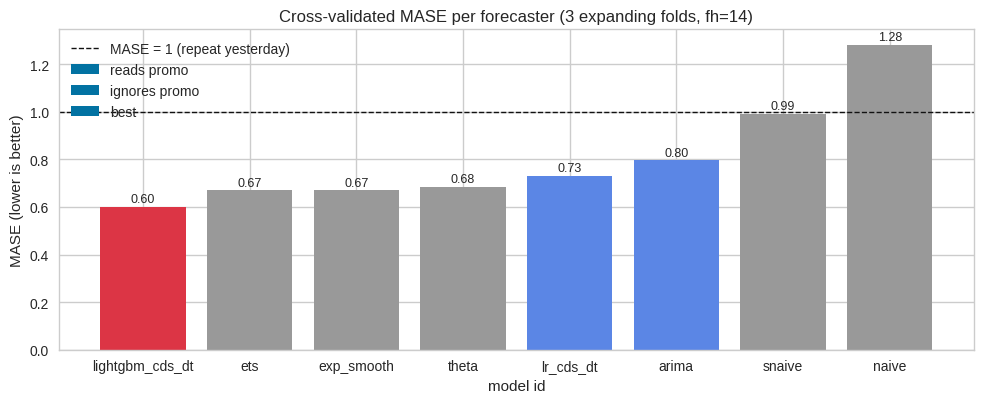

MASE by model: {'lightgbm_cds_dt': 0.601, 'ets': 0.67, 'exp_smooth': 0.67, 'theta': 0.684, 'lr_cds_dt': 0.73, 'arima': 0.796, 'snaive': 0.992, 'naive': 1.282}


In [ ]:
if TS_OK:
    fig, ax = plt.subplots(figsize=(10, 4.2))
    exo_ok = {"arima", "lr_cds_dt", "lightgbm_cds_dt"}
    colors = ["#dc3545" if i == best_id else ("#5b86e5" if i in exo_ok else "#999") for i in cmp_ts.index]
    mase_vals = cmp_ts.MASE.astype(float)                       # compare_models returns object columns; cast before drawing
    ax.bar(cmp_ts.index, mase_vals, color=colors)
    ax.axhline(1.0, color="k", ls="--", lw=1, label="MASE = 1 (repeat yesterday)")
    for i, v in enumerate(mase_vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
    ax.bar([], [], color="#5b86e5", label="reads promo"); ax.bar([], [], color="#999", label="ignores promo"); ax.bar([], [], color="#dc3545", label="best")
    ax.set_title("Cross-validated MASE per forecaster (3 expanding folds, fh=14)"); ax.set_xlabel("model id"); ax.set_ylabel("MASE (lower is better)"); ax.legend()
    plt.tight_layout(); plt.show()
    print("MASE by model:", mase_vals.round(3).to_dict())
else:
    print("skipped: time-series module not available")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One bar per forecaster, the dashed line at 1 is "as good as repeating yesterday". `naive` sits above it because a weekly sawtooth punishes "repeat yesterday"; `snaive` (repeat last week) is close to 1 and is the bar every other model has to clear. The blue bars can see `promo`, the grey ones cannot; the best model is among the blue ones, and the univariate `theta` is competitive because most of the signal is the calendar, which it captures without any driver.

The common misread: reading a MASE gap of a few hundredths as a ranking. Each bar is a mean over three windows of 14 days; the `SD` row that `create_model` prints per fold is of the same order. Prefer the simpler model when the bars are that close.

</div>

## 8.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ One or a few series with drivers you control

- **Reach for `pycaret.time_series`** for a handful of regularly spaced series, with or without exogenous columns, when you want the classic and the reduced-regression forecasters in one table with time-respecting cross-validation and intervals from the statistical models.
- **What it costs:** a clean regular index (no gaps, one frequency), the future values of every exogenous column at prediction time, and `sktime`. Setup and eight models on two years of daily data take well under a minute.
- **The gotcha:** with exogenous columns present, `models()` hides the univariate baselines unless `enforce_exogenous=False`; the future `X` must carry a `PeriodIndex` or the promo days land on the wrong dates; reduction models give no interval; a model that errors is dropped from `compare_models` silently.
- **Not this:** thousands of related series (every product in every store) want a global model, `AutoGluon TimeSeries` or the Nixtla libraries, or a pretrained foundation model (Chronos, TimesFM), which Part 11's capability map places.

</div>

## 8.7 Task 9 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Input: a `DataFrame` with a regular `DatetimeIndex`, the target, and any extra columns as exogenous drivers; output: a forecast frame (`y_pred`, `lower`, `upper`) over a `PeriodIndex`.
- `setup(data, target, fh=14, fold=3, seasonal_period=7, enforce_exogenous=False)` → `compare_models(include=[...], sort="MASE")` → `finalize_model` → `predict_model(final, X=future_exog, return_pred_int=True)` with `future_exog` on a `PeriodIndex`.
- MASE below 1 beats "repeat yesterday"; `snaive` is the bar on a weekly series; count the rows of the compare table against the `include=` list.
- The value of an exogenous column is one two-row table: same model with and without it.
- The Plotly plots need a browser; matplotlib draws the forecast, intervals and promo shading anywhere.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `demand`, `make_demand` | two years of daily `units` with a `promo` column |
| `tsx`, `setup_tbl`, `stats` | the `TSForecastingExperiment`, its setup summary, `check_stats()` |
| `include`, `cmp_ts`, `best_ts`, `best_id` | the requested ids, the comparison table, the winner |
| `test_fc`, `test_metrics_best`, `promo_value` | test-window forecast and metrics; the with/without-promo table |
| `future_promo`, `final_best`, `fc_best`, `fc_arima`, `out` | the promo plan, the finalized models and the 14-day forecasts |

### ➡️ Next Up

Part 9 puts a column of free text next to numbers and shows what PyCaret does with it by default, and what to do instead.

</div>


# Part 9 · Text in Tables · Product Reviews ⭐⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### A text column is not a category

Most business tables carry a free-text column somewhere: a review, a ticket description, a doctor's note. PyCaret is a tabular tool, and left to itself it treats that column as one more categorical variable with thousands of levels. This Part shows that default and its weakness, then the two routes that work: PyCaret's built-in `text_features=` TF-IDF option, and the recipe of engineering text features yourself before `setup`.

</div>

# Task 10 · Predict which reviews readers mark as helpful

## 9.1 ❓ The problem

A marketplace shows a few reviews at the top of each product page and wants to put the **helpful** ones first before anybody has voted. The input is the review text, the star rating, the product's price and whether the purchase was verified. A good answer is a probability of "helpful" for every new review; it changes the ordering of the page.

## 9.2 📥 The input

The generator writes templated reviews: a sentiment phrase tied to the star rating, plus zero to three concrete details ("battery lasts long", "the strap is thin"). Helpfulness is planted to depend on **how many details** a review gives, on a few concrete words, on verified purchase and on how extreme the rating is, and *against* exclamation marks. Most of that signal lives inside the text.


In [ ]:
def make_reviews(n=2000, seed=RANDOM_STATE):
    """Product reviews with templated text; the label 'helpful' depends mostly on what the text says."""
    rng = np.random.default_rng(seed)
    POS = ["works great", "love it", "excellent quality", "highly recommend", "exceeded expectations", "very happy with it"]
    NEG = ["broke after a week", "terrible product", "waste of money", "stopped working", "poor quality", "very disappointed"]
    NEU = ["arrived on time", "as described", "ok for the price", "does the job", "nothing special", "it is fine"]
    DETAILS = ["battery lasts long", "the strap is thin", "setup took a while", "packaging was nice", "colour differs from the photo",
               "manual is unclear", "fits well", "a bit heavy", "zipper feels cheap", "screen is bright", "runs small", "customer service replied fast"]
    CONCRETE = ("battery", "strap", "zipper", "screen", "fits", "runs small")
    star = rng.choice([1, 2, 3, 4, 5], size=n, p=[.10, .10, .15, .30, .35])
    n_details = rng.choice([0, 1, 2, 3], size=n, p=[.35, .35, .20, .10])
    texts = []
    for s, k in zip(star, n_details):
        pool = POS if s >= 4 else (NEG if s <= 2 else NEU)
        parts = [str(rng.choice(pool))] + [str(d) for d in rng.choice(DETAILS, size=k, replace=False)]
        if rng.random() < 0.25:
            parts[0] += "!"
        texts.append(". ".join(parts) + ".")
    verified = rng.random(n) < 0.7
    concrete = np.array([any(w in t for w in CONCRETE) for t in texts])
    exclaim = np.array(["!" in t for t in texts])
    logit = -1.9 + 1.0 * n_details + 0.7 * verified + 0.3 * np.abs(star - 3) + 0.8 * concrete - 0.7 * exclaim
    helpful = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype("int64")
    return pd.DataFrame({"review_text": texts, "star_rating": star.astype("int64"), "price": rng.lognormal(3.2, 0.5, n).round(2),
                         "verified": verified, "helpful": helpful})

reviews = make_reviews()
show_input(reviews, label="helpful", name="product reviews")
print(f"distinct review strings: {reviews.review_text.nunique():,} of {len(reviews):,} rows | words per review: {reviews.review_text.str.split().str.len().mean():.1f} on average")
print("\nthree reviews and their labels:")
for _, r in reviews.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"  [{r.helpful}] {r.star_rating}★ verified={r.verified}: {r.review_text}")
rev_train, rev_test = train_test_split(reviews, test_size=0.25, stratify=reviews.helpful, random_state=RANDOM_STATE)
rev_train, rev_test = rev_train.reset_index(drop=True), rev_test.reset_index(drop=True)
print(f"\nsplit: {len(rev_train)} train / {len(rev_test)} test rows (the same test rows score every route below)")


📥 product reviews: 2,000 rows x 5 columns | label = 'helpful'


,review_text,star_rating,price,verified,helpful
0,highly recommend. packaging was nice. a bit he...,5,25.57,True,1
1,excellent quality. setup took a while.,4,58.65,False,0
2,highly recommend!. battery lasts long. the str...,5,26.34,False,1
3,love it. a bit heavy.,5,25.06,False,1
4,very disappointed.,1,25.83,True,1


column types: {'review_text': 'text/category', 'star_rating': 'numeric', 'price': 'numeric', 'verified': 'boolean', 'helpful': 'numeric'}
label distribution: {1: 0.528, 0: 0.472}
distinct review strings: 879 of 2,000 rows | words per review: 5.8 on average

three reviews and their labels:
  [0] 4★ verified=True: works great!. zipper feels cheap.
  [0] 4★ verified=False: works great!. customer service replied fast.
  [1] 5★ verified=False: love it.

split: 1500 train / 500 test rows (the same test rows score every route below)


| Column | Type | Meaning |
|---|---|---|
| `review_text` | free text | one to four short sentences; more than a thousand distinct strings |
| `star_rating` | numeric (1-5) | the rating |
| `price` | numeric | product price |
| `verified` | boolean | verified purchase |
| `helpful` | **label** | 1 if readers marked the review helpful |

`setup()` will see `review_text` as an `object` column with far more than 25 distinct values, so instead of one-hot encoding it falls back to a **target encoder** (each string replaced by the smoothed mean label of rows with that exact string). For text that is nearly useless: an unseen review string gets the global mean.

## 9.3 💻 One-line calls

Three routes on the same train/test rows and the same short `include=` list. **Route A** hands the raw table to `setup`. **Route B** declares the column with `text_features=["review_text"]`, and PyCaret builds a TF-IDF matrix inside the pipeline (`text_features_method="tf-idf"`). **Route C** engineers text features before PyCaret: TF-IDF → `TruncatedSVD(20)` plus plain text statistics, joined to the table, then `setup` + `compare_models` as in Part 1.


In [ ]:
INCLUDE_TXT = ["lr", "rf", "lightgbm"]
routes = {}

expA = ClassificationExperiment()
with timer("route A: raw text column"):
    expA.setup(rev_train, target="helpful", test_data=rev_test, index=False, fold=3, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
    tblA = expA.pull()
    print(tblA[tblA.Description.isin(["Original data shape", "Transformed data shape", "Numeric features", "Categorical features", "Maximum one-hot encoding"])].to_string(index=False))
    print("encoder chosen for review_text:", type(expA.pipeline.named_steps["rest_encoding"].transformer).__name__)
    bestA = expA.compare_models(include=INCLUDE_TXT, fold=3, sort="AUC")
cmpA = expA.pull(); routes["A: raw text as category"] = (expA, bestA, rev_test, cmpA)
display(pretty(cmpA.drop(columns=["Model"])))


             Description     Value
     Original data shape (2000, 5)
  Transformed data shape (2000, 5)
        Numeric features         2
    Categorical features         1
Maximum one-hot encoding        25
encoder chosen for review_text: TargetEncoder


                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
lr                    Logistic Regression    0.6507  0.6724  0.7345  0.6490  0.6889  0.2939  0.2972    0.0733
rf               Random Forest Classifier    0.5647  0.5987  0.4589  0.6167  0.5261  0.1396  0.1446    0.3233
lightgbm  Light Gradient Boosting Machine    0.5680  0.5931  0.4716  0.6195  0.5351  0.1451  0.1502    0.1467
⏱️ route A: raw text column: 4.5 s


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,0.651,0.672,0.735,0.649,0.689,0.294,0.297,0.073
rf,0.565,0.599,0.459,0.617,0.526,0.140,0.145,0.323
lightgbm,0.568,0.593,0.472,0.620,0.535,0.145,0.150,0.147


In [ ]:
sig = inspect.signature(ClassificationExperiment.setup)
print("text_features / text_features_method are real setup arguments:", "text_features" in sig.parameters and "text_features_method" in sig.parameters,
      "| default method:", sig.parameters["text_features_method"].default)
expB = ClassificationExperiment()
with timer("route B: text_features= (PyCaret's built-in TF-IDF)"):
    expB.setup(rev_train, target="helpful", test_data=rev_test, index=False, text_features=["review_text"], text_features_method="tf-idf",
               fold=3, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
    tblB = expB.pull()
    print(tblB[tblB.Description.isin(["Transformed data shape", "Text features", "Text features embedding method"])].to_string(index=False))
    bestB = expB.compare_models(include=INCLUDE_TXT, fold=3, sort="AUC")
cmpB = expB.pull(); routes["B: PyCaret text_features (tf-idf)"] = (expB, bestB, rev_test, cmpB)
display(pretty(cmpB.drop(columns=["Model"])))
print(f"columns after the TF-IDF step: {expB.get_config('X_train_transformed').shape[1]} (one per vocabulary term)")


text_features / text_features_method are real setup arguments: True | default method: tf-idf
                   Description      Value
        Transformed data shape (2000, 76)
                 Text features          1
Text features embedding method     tf-idf


                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
lr                    Logistic Regression    0.7060  0.7581  0.7408  0.7128  0.7263  0.4089  0.4096    0.1167
lightgbm  Light Gradient Boosting Machine    0.6673  0.7287  0.6852  0.6844  0.6844  0.3326  0.3331    1.7567
rf               Random Forest Classifier    0.6487  0.7041  0.7029  0.6558  0.6782  0.2922  0.2935    0.4300
⏱️ route B: text_features= (PyCaret's built-in TF-IDF): 11.5 s


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,0.706,0.758,0.741,0.713,0.726,0.409,0.410,0.117
lightgbm,0.667,0.729,0.685,0.684,0.684,0.333,0.333,1.757
rf,0.649,0.704,0.703,0.656,0.678,0.292,0.293,0.430


columns after the TF-IDF step: 75 (one per vocabulary term)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: turn the text into a few numbers the model can use

**TF-IDF** (term frequency times inverse document frequency) turns each review into a long sparse vector: one entry per vocabulary term, large when the term is frequent in this review and rare across reviews. **Truncated SVD** compresses those thousands of columns into twenty dense directions that keep most of the variation (the same idea as PCA, for sparse matrices). Add a handful of **plain text statistics** (length, sentence count, exclamation marks, counts of positive and negative words) and the text becomes twenty-six numeric columns that sit next to `star_rating` and `price` like any other feature. The vectoriser and the SVD are fitted on the training rows only and *applied* to the test rows, exactly like any preprocessing.

</div>


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

POS_WORDS = ["great", "love", "excellent", "recommend", "exceeded", "happy", "fast", "bright", "well"]
NEG_WORDS = ["broke", "terrible", "waste", "stopped", "poor", "disappointed", "cheap", "unclear", "thin", "heavy"]

def text_stats(s):
    s = s.fillna("")
    low = s.str.lower()
    return pd.DataFrame({"n_chars": s.str.len(), "n_words": s.str.split().str.len(), "n_sentences": s.str.count(r"\."),
                         "n_exclaim": s.str.count("!"),
                         "n_pos_words": sum(low.str.count(rf"\b{w}\b") for w in POS_WORDS),
                         "n_neg_words": sum(low.str.count(rf"\b{w}\b") for w in NEG_WORDS)})

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, stop_words="english", sublinear_tf=True)
svd = TruncatedSVD(n_components=20, random_state=RANDOM_STATE)
with timer("TF-IDF + SVD(20) + text statistics"):
    T_train = tfidf.fit_transform(rev_train.review_text); T_test = tfidf.transform(rev_test.review_text)
    S_train = svd.fit_transform(T_train); S_test = svd.transform(T_test)
    svd_cols = [f"svd_{i:02d}" for i in range(svd.n_components)]

def enrich(df, S):
    return pd.concat([df.drop(columns=["review_text"]).reset_index(drop=True), text_stats(df.review_text).reset_index(drop=True),
                      pd.DataFrame(S, columns=svd_cols)], axis=1)

trC, teC = enrich(rev_train, S_train), enrich(rev_test, S_test)
print(f"TF-IDF vocabulary: {len(tfidf.vocabulary_):,} terms -> SVD keeps {svd.explained_variance_ratio_.sum():.0%} of the variance in {svd.n_components} columns")
print(f"enriched frame: {trC.shape[1] - 1} features (was {rev_train.shape[1] - 1}); new columns: {list(text_stats(rev_train.review_text.head(1)).columns)} + {svd_cols[0]}..{svd_cols[-1]}")
display(trC.head(3).round(3))


⏱️ TF-IDF + SVD(20) + text statistics: 0.1 s
TF-IDF vocabulary: 312 terms -> SVD keeps 65% of the variance in 20 columns
enriched frame: 29 features (was 4); new columns: ['n_chars', 'n_words', 'n_sentences', 'n_exclaim', 'n_pos_words', 'n_neg_words'] + svd_00..svd_19


,star_rating,price,verified,helpful,n_chars,n_words,n_sentences,n_exclaim,n_pos_words,n_neg_words,...,svd_10,svd_11,svd_12,svd_13,svd_14,svd_15,svd_16,svd_17,svd_18,svd_19
0,4,12.99,False,0,22,2,1,0,1,0,...,-0.063,0.022,0.047,-0.012,-0.044,-0.001,0.009,0.012,-0.020,0.010
1,3,34.75,True,1,11,3,1,0,0,0,...,0.021,-0.006,-0.022,0.007,0.019,0.008,-0.005,-0.004,0.022,-0.007
2,1,35.11,False,1,24,4,2,0,1,1,...,0.027,-0.012,-0.015,-0.015,-0.067,0.019,-0.021,-0.166,0.083,-0.086


In [ ]:
expC = ClassificationExperiment()
with timer("route C: engineered text features"):
    expC.setup(trC, target="helpful", test_data=teC, index=False, fold=3, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
    tblC = expC.pull()
    print(tblC[tblC.Description.isin(["Original data shape", "Transformed data shape", "Numeric features", "Categorical features"])].to_string(index=False))
    bestC = expC.compare_models(include=INCLUDE_TXT, fold=3, sort="AUC")
cmpC = expC.pull(); routes["C: engineered text features"] = (expC, bestC, teC, cmpC)
display(pretty(cmpC.drop(columns=["Model"])))


           Description      Value
   Original data shape (2000, 30)
Transformed data shape (2000, 30)
      Numeric features         28


                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
lr                    Logistic Regression    0.7127  0.7784  0.7041  0.7384  0.7206  0.4252  0.4259    0.1167
lightgbm  Light Gradient Boosting Machine    0.6560  0.7241  0.6928  0.6685  0.6799  0.3083  0.3091    1.0067
rf               Random Forest Classifier    0.6640  0.7110  0.7206  0.6684  0.6934  0.3229  0.3242    0.4867
⏱️ route C: engineered text features: 7.8 s


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,0.713,0.778,0.704,0.738,0.721,0.425,0.426,0.117
lightgbm,0.656,0.724,0.693,0.668,0.680,0.308,0.309,1.007
rf,0.664,0.711,0.721,0.668,0.693,0.323,0.324,0.487


## 9.4 📤 The output

Each route's best model scores the **same 500 held-out reviews** through `predict_model(best, data=test, raw_score=True)`, which adds `prediction_label` and `prediction_score_1` (the probability of "helpful"). `report_card` puts the three on one row each, and the cross-validated AUC from each compare table sits beside the test AUC so that the two agree or disagree in plain sight.


In [ ]:
cards, preds = [], {}
for name, (exp_r, best_r, test_r, cmp_r) in routes.items():
    p = exp_r.predict_model(best_r, data=test_r, raw_score=True, verbose=False)
    preds[name] = p
    card = report_card(test_r.helpful, p.prediction_label, p.prediction_score_1, name=name)
    card.insert(0, "best model", cmp_r.index[0]); card.insert(1, "CV AUC", cmp_r.AUC.iloc[0])
    cards.append(card)
route_tbl = pd.concat(cards)
display(pretty(route_tbl, subset=["CV AUC", "accuracy", "balanced_acc", "f1", "mcc", "roc_auc", "pr_auc"]))
gain = route_tbl.roc_auc.iloc[2] - route_tbl.roc_auc.iloc[0]
print(f"test AUC: raw text as category {route_tbl.roc_auc.iloc[0]:.3f} | built-in tf-idf {route_tbl.roc_auc.iloc[1]:.3f} | engineered {route_tbl.roc_auc.iloc[2]:.3f} (gain over raw {gain:+.3f})")
print("prediction frame columns (route C):", [c for c in preds["C: engineered text features"].columns if c.startswith("prediction")])


ValueError: Unknown format code 'f' for object of type 'str'

test AUC: raw text as category 0.727 | built-in tf-idf 0.793 | engineered 0.802 (gain over raw +0.075)
prediction frame columns (route C): ['prediction_label', 'prediction_score_0', 'prediction_score_1']


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Route A looks like it "used" the text; it did not

The target encoder replaced each distinct review string by the mean label of the training rows that had that exact string, smoothed towards the global mean. Any test review that was never seen word-for-word (almost all of them, with more than a thousand distinct strings) gets the global mean, so on the held-out rows the text column carries no information and the model runs on `star_rating`, `price` and `verified` alone. Its CV AUC can even sit a little above its test AUC for the same reason: inside cross-validation, duplicate strings leak the label. Watch for a categorical column whose cardinality is close to the row count; it is text, an id, or a leak.

</div>

## 9.5 📊 The picture


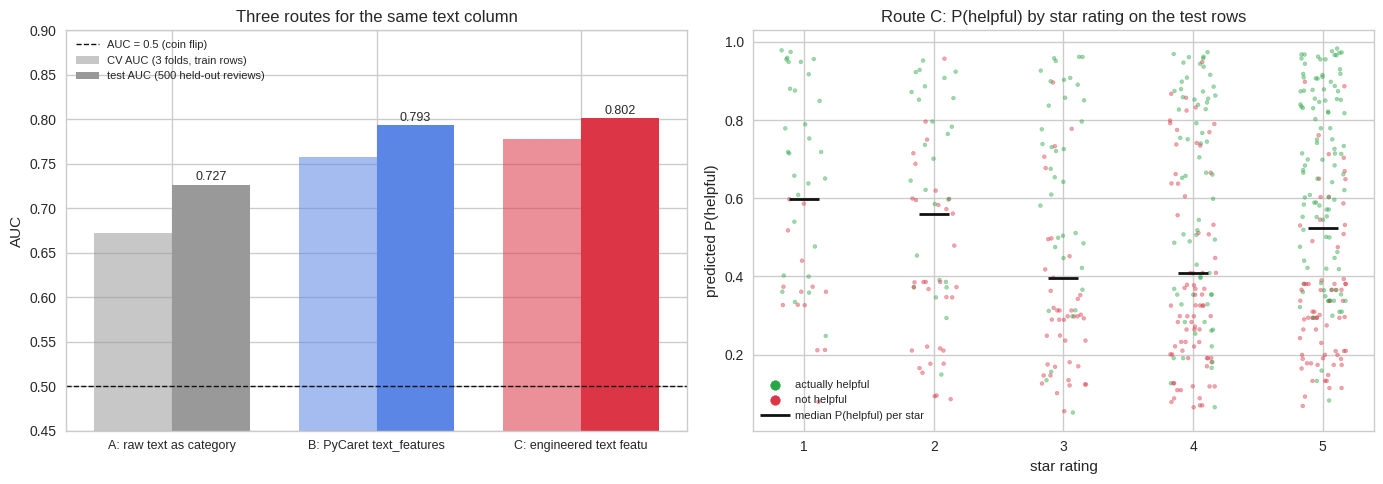

median P(helpful) per star (route C): {1: 0.597, 2: 0.561, 3: 0.396, 4: 0.408, 5: 0.525}


In [ ]:
pC = preds["C: engineered text features"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ["#999", "#5b86e5", "#dc3545"]
x = np.arange(len(route_tbl)); w = 0.38
axes[0].bar(x - w / 2, route_tbl["CV AUC"], w, color=cols, alpha=0.55, label="CV AUC (3 folds, train rows)")
axes[0].bar(x + w / 2, route_tbl["roc_auc"], w, color=cols, label="test AUC (500 held-out reviews)")
for i in x:
    axes[0].text(i + w / 2, route_tbl["roc_auc"].iloc[i] + 0.005, f"{route_tbl['roc_auc'].iloc[i]:.3f}", ha="center", fontsize=9)
axes[0].axhline(0.5, color="k", ls="--", lw=1, label="AUC = 0.5 (coin flip)")
axes[0].set_xticks(x); axes[0].set_xticklabels([n.split(":")[0] + ":" + n.split(":")[1][:22] for n in route_tbl.index], fontsize=9)
axes[0].set_ylim(0.45, max(0.9, route_tbl.roc_auc.max() + 0.05)); axes[0].set_title("Three routes for the same text column"); axes[0].set_ylabel("AUC"); axes[0].legend(loc="upper left", fontsize=8)

for s in range(1, 6):
    m = pC.star_rating.values == s
    axes[1].scatter(np.full(m.sum(), s) + np.random.uniform(-0.18, 0.18, m.sum()), pC.prediction_score_1[m], s=8, alpha=0.45,
                    color=np.where(pC.helpful[m] == 1, "#28a745", "#dc3545"))
axes[1].scatter([], [], color="#28a745", label="actually helpful"); axes[1].scatter([], [], color="#dc3545", label="not helpful")
med = pC.groupby("star_rating").prediction_score_1.median()
axes[1].plot(med.index, med.values, color="k", marker="_", ms=22, ls="", mew=2, label="median P(helpful) per star")
axes[1].set_title("Route C: P(helpful) by star rating on the test rows"); axes[1].set_xlabel("star rating"); axes[1].set_ylabel("predicted P(helpful)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("median P(helpful) per star (route C):", med.round(3).to_dict())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the three routes on the same held-out reviews. Route A (raw string as a category) sits lowest: on unseen strings its text column is a constant, so it runs on `star_rating`, `price` and `verified` alone, and those carry only part of the signal. Route B (PyCaret's built-in TF-IDF) and route C (engineered features) read the words and pull clear of it. The lighter bar is the cross-validated AUC on the training rows, the darker one the test AUC; where they agree the estimate is trustworthy. Right: route C's probability against the star rating, one dot per test review, green if it was in fact helpful. Within a single star the dots spread from low to high: the *rating* alone does not decide helpfulness, the *words* do, which is exactly what route A could not see.

The common misread: taking route B's gain over route A as "PyCaret handles text". It builds a bag-of-words that a linear model can use, and that is enough for templated reviews; it knows nothing of word order, negation ("not great") or meaning. For real reviews that is where a transformer embedding takes over.

</div>


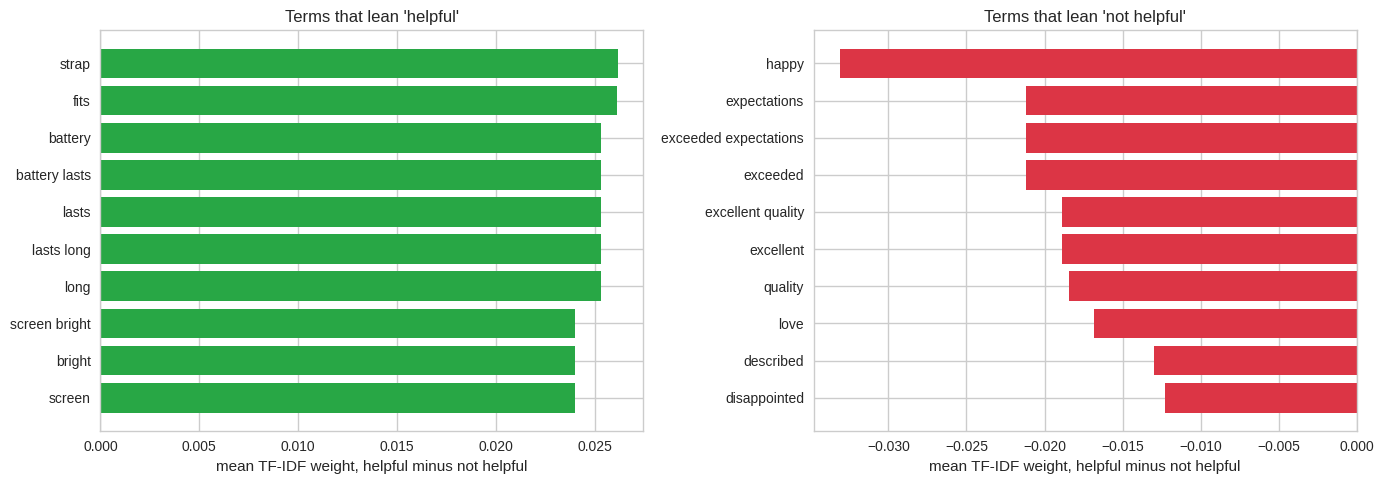

leaning helpful: ['strap', 'fits', 'battery', 'battery lasts', 'lasts', 'lasts long'] | leaning not helpful: ['happy', 'expectations', 'exceeded expectations', 'exceeded', 'excellent quality', 'excellent']


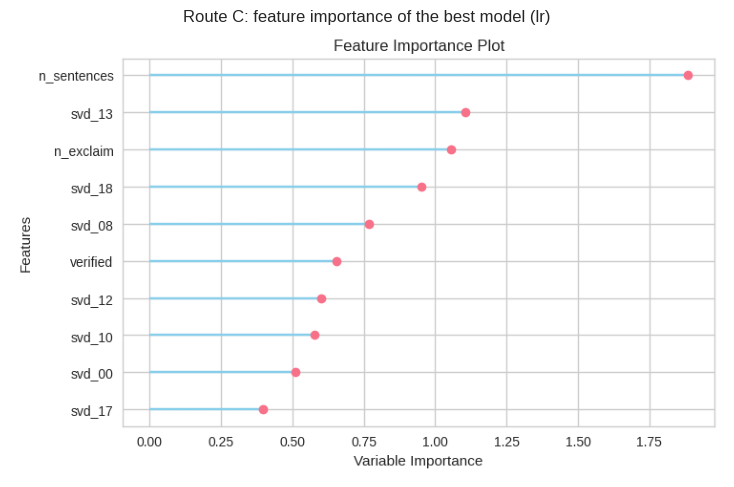

'/tmp/pctour_x_iz1mwp/plots/Feature Importance.png'

In [ ]:
terms = np.array(tfidf.get_feature_names_out())
Tt = T_train.toarray()
y_tr = rev_train.helpful.values
diff = Tt[y_tr == 1].mean(axis=0) - Tt[y_tr == 0].mean(axis=0)          # mean TF-IDF weight, helpful minus not helpful
top_h, top_n = np.argsort(-diff)[:10], np.argsort(diff)[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(terms[top_h][::-1], diff[top_h][::-1], color="#28a745"); axes[0].set_title("Terms that lean 'helpful'"); axes[0].set_xlabel("mean TF-IDF weight, helpful minus not helpful")
axes[1].barh(terms[top_n][::-1], diff[top_n][::-1], color="#dc3545"); axes[1].set_title("Terms that lean 'not helpful'"); axes[1].set_xlabel("mean TF-IDF weight, helpful minus not helpful")
plt.tight_layout(); plt.show()
print("leaning helpful:", list(terms[top_h][:6]), "| leaning not helpful:", list(terms[top_n][:6]))
render(lambda **kw: expC.plot_model(bestC, plot="feature", **kw), title=f"Route C: feature importance of the best model ({cmpC.index[0]})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top: the terms whose average TF-IDF weight differs most between helpful and unhelpful reviews. Concrete nouns from the detail phrases (battery, strap, zipper, screen) lean helpful, because the generator made detailed reviews helpful; short sentiment-only phrases and exclamation marks lean the other way. Bottom: PyCaret's `plot_model(plot="feature")` for route C's best model (for a logistic regression it draws the coefficients). `n_sentences`, which counts the detail phrases, and `n_exclaim` rank at the top, with several SVD directions and `verified` behind them; the model is using the text through the features that were built from it.

The common misread: treating an SVD column's importance as a named effect. `svd_03` is a mixture of terms with no label; to explain *why* a review scored high, go back to the terms (this figure) or to a SHAP plot on the enriched frame (Part 10).

</div>

## 9.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Text next to numbers: engineer first, then PyCaret

- **Reach for PyCaret** when the table is the main signal and the text is one column of it: `text_features=` for a quick bag-of-words baseline; TF-IDF + SVD + text statistics joined to the table when you want control over the vocabulary, n-grams and the number of columns, and features you can name.
- **What it costs:** seconds; the vectoriser and SVD must be fitted on training rows only and saved with the model, because PyCaret's pipeline does not contain them in route C. Route B keeps everything inside `save_model`.
- **The gotcha:** a raw text column is silently target-encoded as a categorical (route A) and looks fine in the setup summary. Check the cardinality of every `object` column against the row count.
- **Not this:** long documents, sentiment that depends on word order, or multilingual text want a sentence-transformer embedding or a fine-tuned transformer; the AutoGluon MultiModal notebook takes the same reviews down that road.

</div>

## 9.7 Task 10 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Input: a table with a free-text column; output: the usual `prediction_label` / `prediction_score_1`, but only after the text has been turned into numbers.
- Route A (raw): `setup` target-encodes the strings, unseen reviews get the global mean, and the model runs on the numeric columns alone.
- Route B (`text_features=["review_text"]`, `text_features_method="tf-idf"`): a built-in bag-of-words that lives inside the saved pipeline.
- Route C (TF-IDF → `TruncatedSVD(20)` + text statistics, then `setup`): the strongest and the most explainable; fit the transformers on training rows only.
- One table, three routes, same test rows: the comparison is the deliverable, not any single AUC.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `reviews`, `rev_train`, `rev_test` | the 2,000 reviews and the fixed 75/25 split |
| `expA`, `expB`, `expC`, `bestA`, `bestB`, `bestC`, `cmpA`, `cmpB`, `cmpC` | one experiment, winner and compare table per route |
| `tfidf`, `svd`, `text_stats`, `enrich`, `trC`, `teC` | the text-feature recipe and the enriched frames |
| `routes`, `preds`, `route_tbl` | the three routes, their test predictions and the one-row-per-route report card |

### ➡️ Next Up

Part 10 opens the models: SHAP summaries, reason codes for a single customer, fairness checks and the dashboards.

</div>


# Part 10 · Interpretability · SHAP, Reason Codes, Fairness ⭐⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The capability

Every Part so far produced a number per row. This Part asks the model **why**. PyCaret's `interpret_model` opens a tree model with SHAP in one call; the same SHAP values, read row by row, become **reason codes** a customer-service agent can say out loud; `permutation_importance` checks what the deployed model really relies on; and `check_fairness` asks whether the model treats one contract type worse than another. The Part trains its own LightGBM on a fresh churn table, so it stands alone.

</div>


# Task 11 · Explain the Churn Model

## 11.1 ❓ The problem

The retention team has a churn score per customer (Part 1). Three people now want more than the score. The **agent on the phone** wants three reasons for this customer's score, in plain words. The **model owner** wants to know which columns the model leans on, and whether that matches what the business knows. The **compliance officer** wants proof that the model does not flag one contract type far more often than its real churn rate justifies. A good answer changes which customers get a call, what the agent says, and whether the model is allowed to run at all.

## 11.2 📥 The input

The same telecom churn shape as Part 1, regenerated here: one row per customer, six behaviour columns, two categoricals, one boolean, and a 0/1 label. The label is planted on the contract type, tenure, support calls and payment method, so the explanations have a known truth to be checked against.


📥 churn (train split): 2,100 rows x 8 columns | label = 'churned'


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,churned
0,65,68.97,month-to-month,card,1,False,79.9,0
1,57,65.68,two-year,mail,3,True,197.9,0
2,37,53.55,month-to-month,e-check,0,False,51.2,0
3,68,105.41,one-year,bank,0,False,163.2,0
4,31,77.95,month-to-month,card,0,True,107.8,0


column types: {'tenure_months': 'numeric', 'monthly_charge': 'numeric', 'contract': 'text/category', 'payment_method': 'text/category', 'num_support_calls': 'numeric', 'streaming': 'boolean', 'total_gb': 'numeric', 'churned': 'numeric'}
label distribution: {0: 0.761, 1: 0.239}


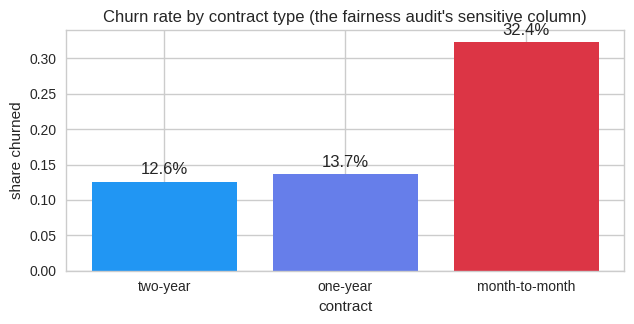

train 2,100 rows / test 900 rows | churn rate 23.9% | by contract: two-year 12.6%, one-year 13.7%, month-to-month 32.4%


In [ ]:
# ============================================================
#  Input: a compact churn table with planted structure (one row per customer)
# ============================================================
def make_churn_small(n=3000, seed=RANDOM_STATE, charge_mult=1.0, extra_calls=0):
    # charge_mult and extra_calls exist for Part 11, which needs a "drifted month" of the same table
    rng = np.random.default_rng(seed)
    tenure = rng.integers(1, 72, n)
    contract = rng.choice(["month-to-month", "one-year", "two-year"], n, p=[0.55, 0.25, 0.20])
    payment = rng.choice(["card", "bank", "e-check", "mail"], n, p=[0.35, 0.25, 0.25, 0.15])
    monthly = np.round((rng.normal(70, 22, n).clip(20, 140) + (contract == "month-to-month") * 8) * charge_mult, 2)
    calls = rng.poisson(1.2, n) + extra_calls
    streaming = rng.random(n) < 0.45
    total_gb = np.round(rng.gamma(2.5, 40, n) + streaming * 60, 1)
    logit = (-1.6 + 1.3 * (contract == "month-to-month") - 0.03 * tenure + 0.012 * (monthly - 70)
             + 0.45 * calls + 0.5 * (payment == "e-check") - 0.4 * streaming)
    churned = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return pd.DataFrame({"tenure_months": tenure, "monthly_charge": monthly, "contract": contract, "payment_method": payment,
                         "num_support_calls": calls, "streaming": streaming, "total_gb": total_gb, "churned": churned})

churn10 = make_churn_small(3000)
train10, test10 = train_test_split(churn10, test_size=0.3, stratify=churn10["churned"], random_state=RANDOM_STATE)
train10, test10 = train10.reset_index(drop=True), test10.reset_index(drop=True)
show_input(train10, label="churned", name="churn (train split)")

rate = churn10.groupby("contract")["churned"].mean().sort_values()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(rate.index, rate.values, color=["#2196F3", "#667eea", "#dc3545"][:len(rate)])
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_title("Churn rate by contract type (the fairness audit's sensitive column)"); ax.set_ylabel("share churned"); ax.set_xlabel("contract")
plt.tight_layout(); plt.show()
print(f"train {len(train10):,} rows / test {len(test10):,} rows | churn rate {churn10.churned.mean():.1%} | by contract: " + ", ".join(f"{k} {v:.1%}" for k, v in rate.items()))


| Column | Type | Meaning |
|---|---|---|
| `tenure_months` | numeric | months since sign-up |
| `monthly_charge` | numeric | current monthly bill |
| `contract` | categorical | `month-to-month`, `one-year`, `two-year` — the **sensitive column** for the fairness audit |
| `payment_method` | categorical | `card`, `bank`, `e-check`, `mail` |
| `num_support_calls` | numeric (count) | support calls in the last quarter |
| `streaming` | boolean | has a streaming add-on |
| `total_gb` | numeric | data used last month |
| `churned` | label 0/1 | left within the quarter |

`setup()` will infer a **binary** target, five numeric columns (the boolean counts as numeric after encoding) and two categoricals that it one-hot encodes. The explanations below belong to the **encoded** columns (`contract_month-to-month`, not `contract`), which is the first thing to know when reading them.

## 11.3 💻 One-line calls

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: four calls, four questions

| Question | Call | Who answers |
|---|---|---|
| Which features matter, and in which direction? | `exp.interpret_model(model, plot="summary")` | SHAP, on the transformed training rows |
| Why did *this* customer get *this* score? | `shap.TreeExplainer(model).shap_values(X_test_transformed)` → top-3 per row | SHAP, by hand for reason codes |
| What does the deployed model actually need? | `permutation_importance(model, X_test_transformed, y_test)` | scikit-learn |
| Is any contract type treated worse? | `exp.check_fairness(model, sensitive_features=["contract"])` | fairlearn (or the by-hand gaps below) |

`interpret_model` works for **tree models** (LightGBM, XGBoost, random forest, extra trees, decision tree) because it uses `shap.TreeExplainer`; on a logistic regression it raises. That is a scope, not a bug.

</div>


In [ ]:
# ============================================================
#  Call 1: one LightGBM to explain (setup with a held-out set, create_model, predict_model)
# ============================================================
exp10 = ClassificationExperiment()
with timer("setup + create_model('lightgbm', fold=3)"):
    exp10.setup(train10, target="churned", test_data=test10, index=False, fold=3,
                session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
    lgbm10 = exp10.create_model("lightgbm", fold=3, verbose=False)
cv10 = exp10.pull()
pred10 = exp10.predict_model(lgbm10, raw_score=True, verbose=False)       # no data= : scores the held-out test rows
card10 = report_card(pred10["churned"], pred10["prediction_label"], pred10["prediction_score_1"], name="LightGBM (Part 10)")
display(pretty(card10))
print(f"CV AUC (3 folds) {cv10.loc['Mean', 'AUC']:.3f} ± {cv10.loc['Std', 'AUC']:.3f} | held-out AUC {card10['roc_auc'].iloc[0]:.3f} | held-out rows {len(pred10):,}")


⏱️ setup + create_model('lightgbm', fold=3): 2.5 s


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
LightGBM (Part 10),0.753,0.584,0.471,0.260,0.335,0.212,0.706,0.427,0.555,0.174


CV AUC (3 folds) 0.715 ± 0.015 | held-out AUC 0.706 | held-out rows 900


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

A **Shapley value** $\phi_i$ is feature $i$'s fair share of the gap between this row's prediction and the average prediction, averaged over every order in which the features could be revealed:

$$ \phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\,\big[ f(S \cup \{i\}) - f(S) \big] $$

The shares are **additive**: $\text{base} + \sum_i \phi_i$ equals the model's output for that row (for LightGBM, the log-odds of churn). Additivity is what turns SHAP from a score into an explanation: the bars for one customer sum to that customer's prediction, and the cell below checks it to floating-point precision.

</div>


In [ ]:
# ============================================================
#  Call 2: SHAP by hand on the transformed held-out rows -> reason codes for two customers
# ============================================================
import shap
X10_te = exp10.get_config("X_test_transformed")       # exactly the columns the model saw (one-hot contract_*, payment_method_*)
y10_te = exp10.get_config("y_test").to_numpy()
explainer10 = shap.TreeExplainer(lgbm10)
sv10 = explainer10.shap_values(X10_te)
sv10 = sv10[1] if isinstance(sv10, list) else sv10     # older shap returns [class0, class1]; keep the positive class
base10 = explainer10.expected_value[1] if np.ndim(explainer10.expected_value) else explainer10.expected_value
margin10 = lgbm10.predict(X10_te, raw_score=True)
additivity_gap = float(np.abs(base10 + sv10.sum(axis=1) - margin10).max())
mean_abs10 = pd.Series(np.abs(sv10).mean(axis=0), index=X10_te.columns).sort_values(ascending=False)

p10 = pred10["prediction_score_1"].to_numpy(); y10 = pred10["churned"].to_numpy()
i_hi = int(np.argmax(p10))                             # the riskiest customer in the held-out set
i_fn = int(np.argmin(np.where(y10 == 1, p10, 2)))      # a churner the model was most sure would stay

def reason_codes(i, k=3):
    # the top-k SHAP contributions for held-out row i, with direction and the value the model saw
    row = pd.Series(sv10[i], index=X10_te.columns)
    top = row.reindex(row.abs().sort_values(ascending=False).index).head(k)
    return pd.DataFrame({"feature": top.index, "value_seen": [X10_te.iloc[i][f] for f in top.index],
                         "shap_log_odds": top.values, "direction": ["raises churn risk" if v > 0 else "lowers churn risk" for v in top.values]})

print(f"transformed held-out matrix {X10_te.shape} | base log-odds {base10:.3f} = P(churn) {1 / (1 + np.exp(-base10)):.3f}")
print(f"additivity: max |base + sum(SHAP) - log-odds| = {additivity_gap:.1e}")
print("mean |SHAP| top 6:", ", ".join(f"{k}={v:.3f}" for k, v in mean_abs10.head(6).items()))
print(f"customers to explain: row {i_hi} (riskiest, P={p10[i_hi]:.3f}, actual {y10[i_hi]}) and row {i_fn} (missed churner, P={p10[i_fn]:.3f}, actual {y10[i_fn]})")


transformed held-out matrix (900, 12) | base log-odds -1.970 = P(churn) 0.122
additivity: max |base + sum(SHAP) - log-odds| = 1.2e-14
mean |SHAP| top 6: tenure_months=0.907, contract_month-to-month=0.840, monthly_charge=0.549, num_support_calls=0.456, total_gb=0.357, streaming=0.149
customers to explain: row 386 (riskiest, P=0.943, actual 1) and row 538 (missed churner, P=0.001, actual 1)


In [ ]:
# ============================================================
#  Call 3: split importance (what LightGBM counted) vs permutation importance (what the deployed model needs)
# ============================================================
from sklearn.inspection import permutation_importance
with timer("permutation_importance, 10 shuffles per column, held-out rows"):
    pi10 = permutation_importance(lgbm10, X10_te, y10_te, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
imp10 = pd.DataFrame({"split_gain": pd.Series(lgbm10.booster_.feature_importance(importance_type="gain"), index=lgbm10.booster_.feature_name()),
                      "perm_drop_auc": pd.Series(pi10.importances_mean, index=X10_te.columns),
                      "perm_std": pd.Series(pi10.importances_std, index=X10_te.columns),
                      "mean_abs_shap": mean_abs10})
imp10["rank_split"] = imp10.split_gain.rank(ascending=False).astype(int)
imp10["rank_perm"] = imp10.perm_drop_auc.rank(ascending=False).astype(int)
imp10 = imp10.sort_values("perm_drop_auc", ascending=False)
unneeded = imp10.index[imp10.perm_drop_auc - imp10.perm_std <= 0].tolist()
print(f"columns whose permutation drop overlaps zero (the deployed model does not need them): {unneeded or 'none'}")
print("rank disagreements of 2+ places between split and permutation:", imp10.index[(imp10.rank_split - imp10.rank_perm).abs() >= 2].tolist() or "none")


⏱️ permutation_importance, 10 shuffles per column, held-out rows: 1.8 s
columns whose permutation drop overlaps zero (the deployed model does not need them): ['payment_method_mail', 'contract_two-year', 'contract_one-year', 'payment_method_e-check', 'monthly_charge', 'total_gb']
rank disagreements of 2+ places between split and permutation: ['tenure_months', 'contract_month-to-month', 'payment_method_bank', 'payment_method_card', 'payment_method_mail', 'contract_two-year', 'contract_one-year', 'monthly_charge', 'total_gb']


In [ ]:
# ============================================================
#  Call 4: fairness by contract type: check_fairness (fairlearn) if installed, and the two classic gaps by hand
# ============================================================
# !pip install -q fairlearn   # pycaret[analysis] installs it; check_fairness needs it
SENSITIVE10 = "contract"
try:
    plt.close("all")
    fair10 = exp10.check_fairness(lgbm10, sensitive_features=[SENSITIVE10])   # per-group metrics via fairlearn MetricFrame; draws a bar grid
    plt.close("all")                                                            # the grid is redrawn as one gap chart in 11.5
    FAIR_STATUS = "check_fairness ran (fairlearn installed)"
except ModuleNotFoundError:
    fair10 = None; FAIR_STATUS = "fairlearn not installed; by-hand audit only"

grp = {}
for g, d in pred10.groupby(SENSITIVE10):
    y, yhat, p = d["churned"].to_numpy(), d["prediction_label"].to_numpy(), d["prediction_score_1"].to_numpy()
    grp[g] = {"n": len(d), "base_rate": y.mean(), "selection_rate": yhat.mean(),
              "TPR": recall_score(y, yhat, zero_division=0), "FPR": ((yhat == 1) & (y == 0)).sum() / max((y == 0).sum(), 1),
              "precision": precision_score(y, yhat, zero_division=0), "roc_auc": roc_auc_score(y, p)}
by_group10 = pd.DataFrame(grp).T
gaps10 = pd.Series({"demographic parity (selection-rate gap)": by_group10.selection_rate.max() - by_group10.selection_rate.min(),
                    "equal opportunity (TPR gap)": by_group10.TPR.max() - by_group10.TPR.min(),
                    "FPR gap": by_group10.FPR.max() - by_group10.FPR.min(),
                    "base-rate gap (the data itself)": by_group10.base_rate.max() - by_group10.base_rate.min()})
print(FAIR_STATUS)
print("gaps across contract types:\n" + gaps10.round(3).to_string())


                             Model  Accuracy     AUC  Recall   Prec.      F1  Kappa     MCC
0  Light Gradient Boosting Machine    0.7533  0.7061  0.2605  0.4706  0.3353  0.199  0.2121
check_fairness ran (fairlearn installed)
gaps across contract types:
demographic parity (selection-rate gap)    0.198
equal opportunity (TPR gap)                0.325
FPR gap                                    0.143
base-rate gap (the data itself)            0.188


## 11.4 📤 The output

Three tables come out of the four calls: the **reason codes** for two customers (the artefact the phone agent reads), the **importance table** with three views of the same model, and the **per-group fairness table** with its gaps.


In [ ]:
# ============================================================
#  Output 1: reason codes for two held-out customers, as tables
# ============================================================
for label, i in [("RISKIEST CUSTOMER", i_hi), ("MISSED CHURNER", i_fn)]:
    print(f"{label}: held-out row {i}, P(churn) = {p10[i]:.3f}, actual = {y10[i]}")
    display(reason_codes(i).style.format({"value_seen": "{:.2f}", "shap_log_odds": "{:+.3f}"}))
print("value_seen is on the transformed scale (one-hot columns are 0/1); shap_log_odds are additive on top of the base log-odds")


RISKIEST CUSTOMER: held-out row 386, P(churn) = 0.943, actual = 1


,feature,value_seen,shap_log_odds,direction
0,num_support_calls,5.00,+2.326,raises churn risk
1,total_gb,22.70,+1.031,raises churn risk
2,contract_month-to-month,1.00,+0.923,raises churn risk


MISSED CHURNER: held-out row 538, P(churn) = 0.001, actual = 1


,feature,value_seen,shap_log_odds,direction
0,tenure_months,63.00,-2.164,lowers churn risk
1,contract_month-to-month,0.00,-1.572,lowers churn risk
2,monthly_charge,28.14,-0.862,lowers churn risk


value_seen is on the transformed scale (one-hot columns are 0/1); shap_log_odds are additive on top of the base log-odds


In [ ]:
# ============================================================
#  Output 2: the three-way importance table, and the per-group fairness table
# ============================================================
display(pretty(imp10[["split_gain", "perm_drop_auc", "perm_std", "mean_abs_shap", "rank_split", "rank_perm"]].head(10), fmt="{:.3f}"))
if fair10 is not None:
    print("check_fairness (fairlearn MetricFrame, hard labels):")
    display(fair10.round(3))
print("by-hand audit per contract type (adds the base rate and a probability AUC):")
display(pretty(by_group10, fmt="{:.3f}"))
print(f"selection-rate gap {gaps10.iloc[0]:.3f} vs base-rate gap {gaps10.iloc[3]:.3f}: the model flags month-to-month customers more because they churn more")
print("TPR per group at the 0.5 threshold: " + ", ".join(f"{g} {v:.3f}" for g, v in by_group10.TPR.items()) + f" -> equal-opportunity gap {gaps10.iloc[1]:.3f}; roc_auc per group: " + ", ".join(f"{g} {v:.3f}" for g, v in by_group10.roc_auc.items()))


,split_gain,perm_drop_auc,perm_std,mean_abs_shap,rank_split,rank_perm
tenure_months,1773.569,0.080,0.015,0.907,3.000,1.000
contract_month-to-month,625.270,0.054,0.011,0.840,5.000,2.000
num_support_calls,709.749,0.048,0.008,0.456,4.000,3.000
payment_method_bank,149.652,0.005,0.003,0.094,7.000,4.000
streaming,247.266,0.004,0.003,0.149,6.000,5.000
payment_method_card,113.222,0.003,0.002,0.042,8.000,6.000
payment_method_mail,59.141,0.000,0.002,0.039,10.000,7.000
contract_two-year,33.569,-0.000,0.001,0.030,11.000,8.000
contract_one-year,23.361,-0.001,0.001,0.023,12.000,9.000
payment_method_e-check,102.101,-0.003,0.002,0.090,9.000,10.000


check_fairness (fairlearn MetricFrame, hard labels):


,Samples,Accuracy,AUC,Recall,Precision,F1,Kappa,MCC,Selection Rate
contract,,,,,,,,,
month-to-month,499,0.673347,0.581379,0.325,0.485981,0.389513,0.178356,0.185083,0.214429
one-year,220,0.854545,0.551289,0.129032,0.444444,0.2,0.145838,0.180177,0.040909
two-year,181,0.850829,0.490446,0.0,0.0,0.0,-0.030361,-0.050758,0.016575


by-hand audit per contract type (adds the base rate and a probability AUC):


,n,base_rate,selection_rate,TPR,FPR,precision,roc_auc
month-to-month,499.000,0.321,0.214,0.325,0.162,0.486,0.649
one-year,220.000,0.141,0.041,0.129,0.026,0.444,0.666
two-year,181.000,0.133,0.017,0.000,0.019,0.000,0.716


selection-rate gap 0.198 vs base-rate gap 0.188: the model flags month-to-month customers more because they churn more
TPR per group at the 0.5 threshold: month-to-month 0.325, one-year 0.129, two-year 0.000 -> equal-opportunity gap 0.325; roc_auc per group: month-to-month 0.649, one-year 0.666, two-year 0.716


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `check_fairness` feeds fairlearn hard labels

The `AUC` column in the `check_fairness` table is computed from `prediction_label`, so it is a balanced accuracy in disguise. The by-hand table's `roc_auc` uses `prediction_score_1` and is the real ranking quality per group. Read the two tables side by side; the numbers differ for a reason.

</div>

## 11.5 📊 The picture


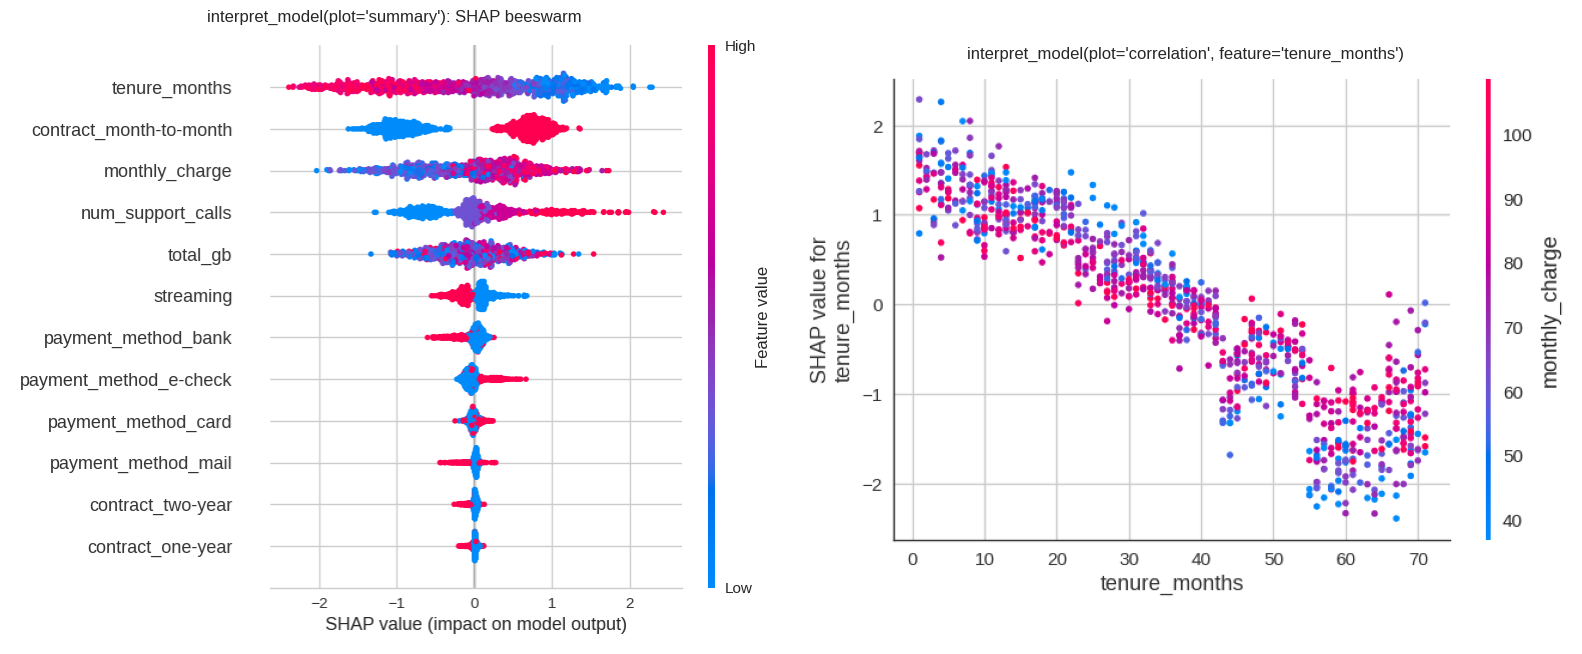

interpret_model uses shap.TreeExplainer on the transformed training rows; save=True wrote 2 PNGs under PLOTS and render_grid showed them


In [ ]:
# ============================================================
#  Picture 1: interpret_model's beeswarm and a dependence plot, rendered from the PNGs PyCaret saves
# ============================================================
pngs10 = render_grid([
    ("interpret_model(plot='summary'): SHAP beeswarm", lambda **kw: exp10.interpret_model(lgbm10, plot="summary", **kw), None),
    ("interpret_model(plot='correlation', feature='tenure_months')", lambda **kw: exp10.interpret_model(lgbm10, plot="correlation", feature="tenure_months", **kw), None),
], ncols=2, figsize=(16, 6.5))
print(f"interpret_model uses shap.TreeExplainer on the transformed training rows; save=True wrote {len(pngs10)} PNGs under PLOTS and render_grid showed them")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, the **beeswarm**: one row per encoded feature, sorted by mean |SHAP|; each dot is a training customer, its horizontal position the push on that customer's churn log-odds, its colour the feature's value (red high, blue low). `contract_month-to-month` and `tenure_months` sit on top with clean colour splits: red (month-to-month = 1) pushes right, and red (long tenure) pushes left. Right, the **dependence plot** for `tenure_months`: SHAP value against tenure, coloured by the feature that interacts with it most; the downward slope is the planted "longer tenure, lower risk" effect, and the vertical spread at one tenure is the interaction.

**The common misread:** reading the beeswarm as a causal ranking ("give customers longer tenure"). SHAP describes the model's arithmetic, not the world; a feature can rank high because it proxies something the table does not contain.

</div>


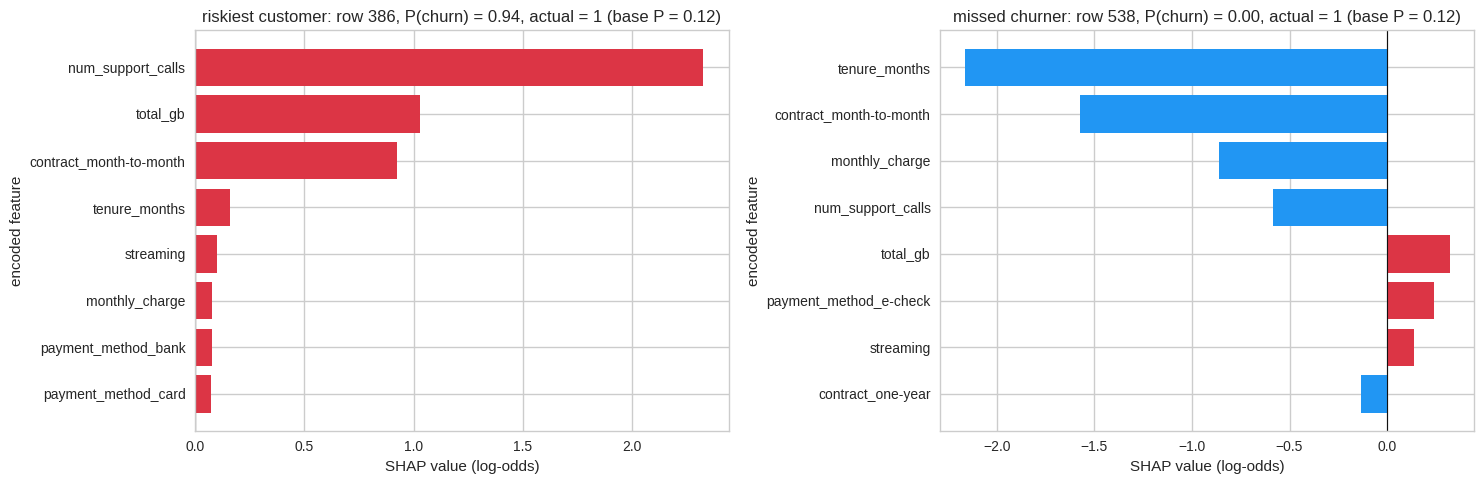

each panel's bars plus the base log-odds -1.970 sum to that customer's predicted log-odds; the top three bars are the reason codes


In [ ]:
# ============================================================
#  Picture 2: reason-code bars for the two customers (red raises churn risk, blue lowers it)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, i, ttl in zip(axes, [i_hi, i_fn], ["riskiest customer", "missed churner"]):
    row = pd.Series(sv10[i], index=X10_te.columns)
    top = row.reindex(row.abs().sort_values(ascending=False).index).head(8)[::-1]
    ax.barh(top.index, top.values, color=["#dc3545" if v > 0 else "#2196F3" for v in top.values])
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{ttl}: row {i}, P(churn) = {p10[i]:.2f}, actual = {y10[i]} (base P = {1 / (1 + np.exp(-base10)):.2f})")
    ax.set_xlabel("SHAP value (log-odds)"); ax.set_ylabel("encoded feature")
plt.tight_layout(); plt.show()
print(f"each panel's bars plus the base log-odds {base10:.3f} sum to that customer's predicted log-odds; the top three bars are the reason codes")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two customers, eight bars each. For the riskiest customer every bar points right: the support calls and the month-to-month contract carry most of the push, and the model is right to be confident. One of the top three reason codes is a *low* `total_gb`. The generator never planted that effect; the model learned it from noise, and Picture 3 shows the deployed model does not need the column at all. A reason code can be a real pattern or a learned habit, and permutation importance is how to tell them apart before an agent reads it out. For the missed churner the big bars all point left: a long tenure, a fixed-term contract, a low bill and no support calls said "stays", the customer left anyway, and nothing in the row hinted at it. That is the signature of an unpredictable event, not of a broken model.

**The common misread:** expecting the explanation of a wrong prediction to look wrong. SHAP explains what the model did with the inputs it had; a coherent explanation of a miss says the *inputs* were missing something.

</div>


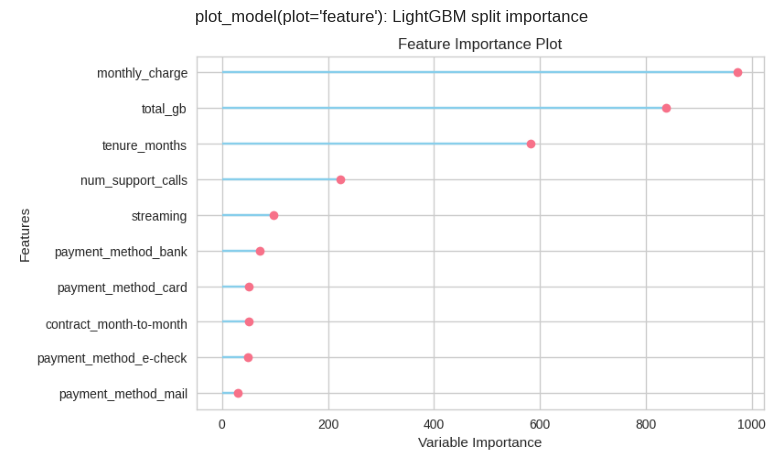

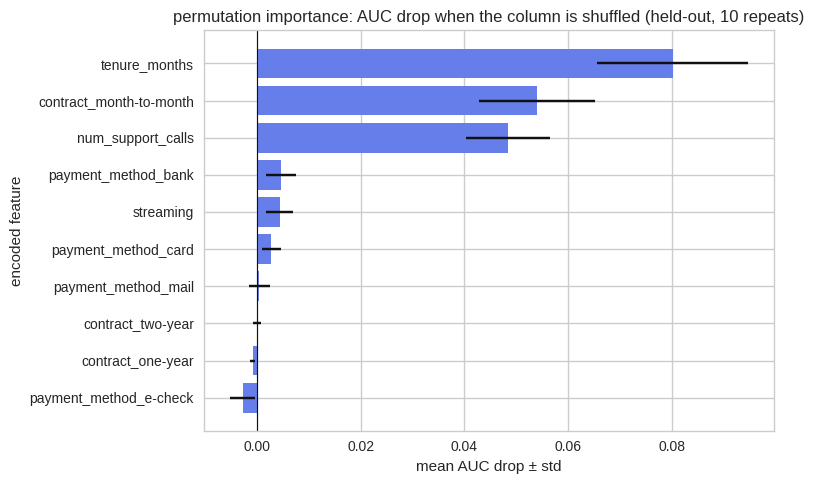

split importance ranks 'monthly_charge' first; permutation ranks 'tenure_months' first


In [ ]:
# ============================================================
#  Picture 3: plot_model(plot="feature") next to permutation importance with its error bars
# ============================================================
render(lambda **kw: exp10.plot_model(lgbm10, plot="feature", **kw), title="plot_model(plot='feature'): LightGBM split importance", figsize=(8, 5))
top_p = imp10.head(10)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_p.index, top_p.perm_drop_auc, xerr=top_p.perm_std, color="#667eea")
ax.axvline(0, color="k", lw=0.8)
ax.set_title("permutation importance: AUC drop when the column is shuffled (held-out, 10 repeats)")
ax.set_xlabel("mean AUC drop ± std"); ax.set_ylabel("encoded feature")
plt.tight_layout(); plt.show()
print(f"split importance ranks '{imp10.split_gain.idxmax()}' first; permutation ranks '{imp10.perm_drop_auc.idxmax()}' first")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

First, what LightGBM **counted during training**: `plot_model(plot="feature")` draws `feature_importances_`, the number of splits per column (the table in 11.4 uses split *gain*; both put the same two columns on top). Split importance favours continuous columns with many candidate split points (`monthly_charge`, `total_gb`), whether or not those splits helped on new data. Second, what the **deployed model needs**: shuffle one column on the held-out rows and measure the AUC drop. The error bars are real because permutation importance is a random experiment; a bar that overlaps zero belongs to a column the model could lose without noticing, and the cell in 11.3 listed them. The importance table in 11.4 makes the disagreement exact: the split ranking's top two columns are the permutation ranking's bottom two.

**The common misread:** "importance zero means the column is useless." It means *this model* does not need it, often because a correlated column carries the same information; drop both and the score falls.

</div>


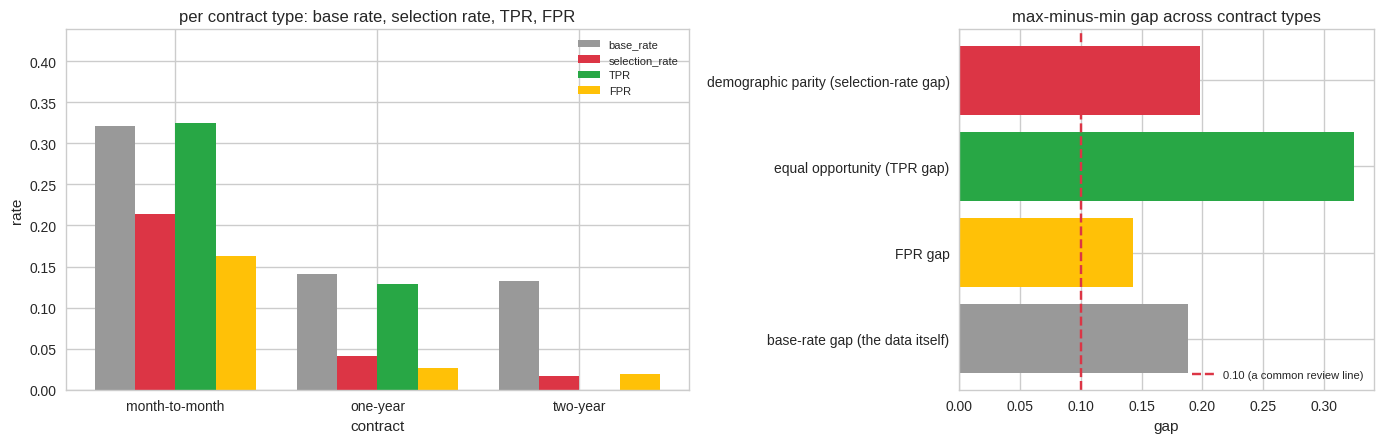

selection-rate gap 0.198 | TPR gap 0.325 | FPR gap 0.143 | base-rate gap 0.188


In [ ]:
# ============================================================
#  Picture 4: the fairness-gap chart: selection rate, TPR and FPR per contract type, with the base rate as the honest reference
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [3, 2]})
cols = ["base_rate", "selection_rate", "TPR", "FPR"]
x = np.arange(len(by_group10)); w = 0.2
for j, (c, colr) in enumerate(zip(cols, ["#999999", "#dc3545", "#28a745", "#ffc107"])):
    axes[0].bar(x + (j - 1.5) * w, by_group10[c].astype(float), w, label=c, color=colr)
axes[0].set_xticks(x); axes[0].set_xticklabels(by_group10.index); axes[0].set_ylim(0, min(1.0, float(by_group10[cols].to_numpy().max()) * 1.35))
axes[0].set_title("per contract type: base rate, selection rate, TPR, FPR"); axes[0].set_ylabel("rate"); axes[0].set_xlabel("contract"); axes[0].legend(fontsize=8)
axes[1].barh(gaps10.index[::-1], gaps10.values[::-1], color=["#999999", "#ffc107", "#28a745", "#dc3545"])
axes[1].axvline(0.1, ls="--", color="#dc3545", label="0.10 (a common review line)")
axes[1].set_title("max-minus-min gap across contract types"); axes[1].set_xlabel("gap"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"selection-rate gap {gaps10.iloc[0]:.3f} | TPR gap {gaps10.iloc[1]:.3f} | FPR gap {gaps10.iloc[2]:.3f} | base-rate gap {gaps10.iloc[3]:.3f}")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, four rates per contract type. The grey bar (base rate) is the truth in the data; the red bar (selection rate) is what the model does with it. Month-to-month customers are flagged far more often, and their grey bar is far taller too: the selection-rate gap is almost the same size as the base-rate gap, so the model follows the data. Right, the gaps. The **demographic-parity** gap (selection rate) is large *because the base-rate gap is large*. The **equal-opportunity** gap (TPR) is the real finding: it is the largest bar, and the per-group table shows why. Almost no customer on a one-year or two-year contract scores above 0.5, so at that threshold the model finds hardly any of *their* churners, while the per-group `roc_auc` says it ranks them fine. That is a **threshold** problem, not a ranking problem, and the fix is a lower or per-group threshold (`optimize_threshold`, Part 4), not a new model.

**The common misread:** treating a large selection-rate gap as proof of bias, or a similar-looking AUC as proof of fairness. A model that flags a group more because that group churns more is accurate, not unfair; the errors per group decide, and here they say the single threshold is what treats the long-contract churners worse.

</div>

## 11.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Use it for every model that faces a person**: a churn call, a credit decision, a claim. `interpret_model` costs one line and a few seconds on a tree model; reason codes cost the SHAP matrix on the held-out rows and a `head(3)` per customer; permutation importance costs `n_repeats` passes over the held-out set; `check_fairness` costs a `groupby`. All four together ran in well under a minute here.

**The gotcha:** SHAP values belong to the **encoded** columns. Sum the one-hot columns that came from one original feature (`contract_*`) before reporting "contract" to a person, and never read a dependence plot outside the range where the data has rows.

**Mentioned, not run:** `exp.dashboard(model)` opens an interactive explainerdashboard (SHAP, what-if, per-row explanations) in the browser; `interpret_model(plot="reason", observation=i)` draws shap's interactive force plot; `interpret_model(plot="pdp")` needs the optional `interpret` package. There is no `deep_check` function in PyCaret 3.3.2; the checks it would suggest are `check_fairness` (above) and `check_drift` (Part 11, by hand).

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: bring the fairness table *with the base rate* to the review

`check_fairness` shows selection rate and metrics per group but not the base rate. The by-hand table adds it, and that one column changes the conversation from "the model flags month-to-month customers far more often" to "month-to-month customers churn far more often, and the model's *ranking* is as good for the other groups, but the shared 0.5 threshold gives them almost no recall." The first sentence starts an argument about the model; the second starts a fix for the threshold.

</div>

## 11.7 Task 11 Summary

**✅ Key Takeaways**
- `interpret_model(plot="summary" | "correlation")` is SHAP on tree models in one line; `render` shows the PNG it saves.
- Reason codes are the top-3 SHAP contributions of one row, and their additivity (base + sum = log-odds) was checked to floating-point precision.
- Split importance rewards columns with many split points; permutation importance measures what the deployed model needs and comes with error bars.
- The fairness audit needs the base rate next to the selection rate; demographic parity and equal opportunity answer different questions, and here the equal-opportunity gap pointed at the shared threshold, not the model.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `make_churn_small`, `churn10`, `train10`, `test10` | the churn generator (with drift knobs for Part 11) and its split |
| `exp10`, `lgbm10`, `cv10`, `pred10`, `card10` | the experiment, its LightGBM, the CV table, held-out predictions and the report card |
| `X10_te`, `y10_te`, `explainer10`, `sv10`, `base10`, `mean_abs10`, `additivity_gap` | the transformed held-out matrix, the TreeExplainer, the SHAP matrix, base log-odds, global importance and the additivity check |
| `reason_codes(i)`, `i_hi`, `i_fn` | the reason-code builder and the two explained customers |
| `pi10`, `imp10`, `unneeded` | permutation importance, the three-way importance table, and the columns the model does not need |
| `fair10`, `FAIR_STATUS`, `by_group10`, `gaps10`, `SENSITIVE10` | the `check_fairness` table (or `None`), the by-hand per-group table and its gaps |

**➡️ Next Up:** Part 11 ships the model — finalize, save, load, an API file, logging, drift — and closes the tour with the capability map.


# Part 11 · Deployment and the Capability Map 🔬

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The last capability, and the map

Every Part ended with a model in memory. This Part turns one into an artefact: `finalize_model` refits on every labelled row, `save_model` / `load_model` move the whole pipeline, `predict_model` scores rows the model has never seen, `create_api` writes a FastAPI file, `log_experiment` records the run, and a by-hand PSI check watches the inputs for drift. Then the tour closes with the **capability map**: for any new business question, which module, which calls, what input, what output, which metric, and which Part to reopen.

</div>


# Task 12 · Ship It, Watch It, and Pick the Right Module

## 12.1 ❓ The problem

The retention team wants the churn model **scored every night** on the customers who signed up that day, wants the exact model that was reviewed (not a re-trained cousin), wants a service other teams can call, and wants an alarm when next month's customers stop looking like the ones the model learned from. A good answer is a saved pipeline, a scoring call, an API file, a run log, and one drift number per feature.

## 12.2 📥 The input

Two inputs: **five fresh customers** typed by hand in the original column layout (no preprocessing; the saved pipeline does it), and a **drifted month** from the same generator with two knobs turned: monthly charges 15% higher after a price change, and one extra support call per customer after an outage.


In [ ]:
# ============================================================
#  Input: five fresh customers (raw columns) and a drifted month of the same table
# ============================================================
fresh11 = pd.DataFrame({
    "tenure_months":     [2, 48, 11, 30, 6],
    "monthly_charge":    [95.0, 45.5, 80.0, 60.0, 110.0],
    "contract":          ["month-to-month", "two-year", "month-to-month", "one-year", "month-to-month"],
    "payment_method":    ["e-check", "bank", "card", "card", "e-check"],
    "num_support_calls": [4, 0, 1, 0, 3],
    "streaming":         [False, True, True, False, False],
    "total_gb":          [80.0, 210.0, 150.0, 95.0, 40.0],
})
show_input(fresh11, name="five fresh customers (no label yet)")

reference11 = test10.copy()                                                      # last month: the held-out rows the model never trained on
drifted11 = make_churn_small(len(test10), seed=RANDOM_STATE + 7, charge_mult=1.15, extra_calls=1)   # this month, after a price change and an outage
print(f"reference month {len(reference11):,} rows, churn {reference11.churned.mean():.1%} | drifted month {len(drifted11):,} rows, churn {drifted11.churned.mean():.1%}")
print(f"monthly_charge mean {reference11.monthly_charge.mean():.1f} -> {drifted11.monthly_charge.mean():.1f} | support calls mean {reference11.num_support_calls.mean():.2f} -> {drifted11.num_support_calls.mean():.2f}")


📥 five fresh customers (no label yet): 5 rows x 7 columns


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb
0,2,95.0,month-to-month,e-check,4,False,80.0
1,48,45.5,two-year,bank,0,True,210.0
2,11,80.0,month-to-month,card,1,True,150.0
3,30,60.0,one-year,card,0,False,95.0
4,6,110.0,month-to-month,e-check,3,False,40.0


column types: {'tenure_months': 'numeric', 'monthly_charge': 'numeric', 'contract': 'text/category', 'payment_method': 'text/category', 'num_support_calls': 'numeric', 'streaming': 'boolean', 'total_gb': 'numeric'}
reference month 900 rows, churn 23.9% | drifted month 900 rows, churn 34.3%
monthly_charge mean 73.3 -> 85.8 | support calls mean 1.25 -> 2.23


## 12.3 💻 One-line calls

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: what `finalize_model` does, and why the honest numbers come first

During development the held-out rows stay out of training so they can score the model honestly. Once the model is chosen those rows are wasted potential: **`finalize_model` refits the same pipeline with the same hyperparameters on train + test together**, so the shipped model has seen every labelled row. The cost is that no held-out number describes the finalized model any more. So: freeze the honest report card **before** finalizing, ship the finalized pipeline, report the frozen numbers.

</div>


In [ ]:
# ============================================================
#  Calls 1-3: freeze the honest numbers -> finalize_model -> save_model / load_model -> predict_model on fresh rows
# ============================================================
frozen11 = card10.copy()                                       # the honest held-out report card from Part 10, frozen before finalize
with timer("finalize_model (refit on train + test)"):
    final11 = exp10.finalize_model(lgbm10)
after11 = exp10.predict_model(final11, verbose=False); after_auc = float(exp10.pull().loc[0, "AUC"])
print(f"held-out AUC before finalize {frozen11['roc_auc'].iloc[0]:.4f} -> 'test' AUC after finalize {after_auc:.4f} (the second number is not a test score: those rows were in training)")

model_path11 = os.path.join(WORK, "churn_pipeline")            # save_model adds .pkl itself
_, saved_file11 = exp10.save_model(final11, model_path11, verbose=False)
loaded11 = exp10.load_model(model_path11, verbose=False)
print(f"saved {os.path.basename(saved_file11)} ({os.path.getsize(saved_file11) / 1024:.0f} KB) | loaded a {type(loaded11).__name__} with steps {[n for n, _ in loaded11.steps]}")

scored11 = exp10.predict_model(loaded11, data=fresh11, raw_score=True, verbose=False)
same = np.allclose(scored11["prediction_score_1"], exp10.predict_model(final11, data=fresh11, raw_score=True, verbose=False)["prediction_score_1"])
print(f"loaded pipeline scores the five fresh rows identically to the in-memory one: {same}")


⏱️ finalize_model (refit on train + test): 1.0 s
held-out AUC before finalize 0.7061 -> 'test' AUC after finalize 0.9815 (the second number is not a test score: those rows were in training)
saved churn_pipeline.pkl (343 KB) | loaded a Pipeline with steps ['numerical_imputer', 'categorical_imputer', 'onehot_encoding', 'actual_estimator']
loaded pipeline scores the five fresh rows identically to the in-memory one: True


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Never report a metric computed after `finalize_model`

The two AUC numbers printed above are for the same held-out rows. The second is higher because the finalized model trained on them. `frozen11` is the report card to put in the model card; `final11` is the pipeline to ship.

</div>

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 `create_api`: a file, not a server

`create_api(model, "name")` saves the pipeline as `name.pkl` and writes `name.py`, a FastAPI app with a `/predict` endpoint whose input schema is built from the training columns. It needs `fastapi` and `uvicorn` installed to write the file; when they are missing, the cell writes the identical file from PyCaret's template so the output does not depend on the environment. `create_docker("name")` then writes a `Dockerfile` and `requirements.txt` around it, and `create_app(model)` opens a Gradio form; both are mentioned, not run. Nothing here starts a server.

</div>


In [ ]:
# ============================================================
#  Call 4: create_api writes the FastAPI file into a temp folder (printed, never served)
# ============================================================
# !pip install -q fastapi uvicorn   # needed only to write and run the generated API (pycaret[mlops] installs them)
import pathlib
API_NAME = "churn_api"; API_DIR = pathlib.Path(tempfile.mkdtemp(prefix="churn_api_", dir=WORK))
cwd = os.getcwd(); os.chdir(API_DIR)
try:
    exp10.create_api(final11, API_NAME)                # writes churn_api.py and churn_api.pkl in the current folder
    api_how = "written by exp.create_api"
except ModuleNotFoundError as e:                       # fastapi / uvicorn missing: write the same file PyCaret generates
    exp10.save_model(final11, API_NAME, verbose=False)
    X0, y0 = exp10.get_config("X").iloc[0].to_dict(), exp10.get_config("y").iloc[0]
    api_src = f"""# -*- coding: utf-8 -*-

import pandas as pd
from pycaret.classification import load_model, predict_model
from fastapi import FastAPI
import uvicorn
from pydantic import create_model

# Create the app
app = FastAPI()

# Load trained Pipeline
model = load_model("{API_NAME}")

# Create input/output pydantic models
input_model = create_model("{API_NAME}_input", **{X0})
output_model = create_model("{API_NAME}_output", prediction={y0!r})


# Define predict function
@app.post("/predict", response_model=output_model)
def predict(data: input_model):
    data = pd.DataFrame([data.dict()])
    predictions = predict_model(model, data=data)
    return {{"prediction": predictions["prediction_label"].iloc[0]}}


if __name__ == "__main__":
    uvicorn.run(app, host="127.0.0.1", port=8000)
"""
    pathlib.Path(f"{API_NAME}.py").write_text(api_src, encoding="utf-8")
    api_how = f"written from PyCaret's template ({type(e).__name__}: {str(e).strip().splitlines()[0][:50]})"
finally:
    os.chdir(cwd)
print(f"{API_NAME}.py {api_how}\n" + "-" * 70)
print((API_DIR / f"{API_NAME}.py").read_text(encoding="utf-8").strip())
print("-" * 70)
print("files in the API folder:", sorted(p.name for p in API_DIR.iterdir()))
print(f"to serve (not run here): python {API_NAME}.py  ->  POST /predict  |  to containerise: exp.create_docker('{API_NAME}') then docker build")


API successfully created. This function only creates a POST API, it doesn't run it automatically. To run your API, please run this command --> !python churn_api.py
churn_api.py written by exp.create_api
----------------------------------------------------------------------
# -*- coding: utf-8 -*-

import pandas as pd
from pycaret.classification import load_model, predict_model
from fastapi import FastAPI
import uvicorn
from pydantic import create_model

# Create the app
app = FastAPI()

# Load trained Pipeline
model = load_model("churn_api")

# Create input/output pydantic models
input_model = create_model("churn_api_input", **{'tenure_months': 65, 'monthly_charge': 68.97000122070312, 'contract': 'month-to-month', 'payment_method': 'card', 'num_support_calls': 1, 'streaming': False, 'total_gb': 79.9000015258789})
output_model = create_model("churn_api_output", prediction=0)


# Define predict function
@app.post("/predict", response_model=output_model)
def predict(data: input_model):
  

In [ ]:
# ============================================================
#  Call 5: experiment logging with MLflow (guarded): setup(log_experiment=True) records params, metrics and the pipeline
# ============================================================
# !pip install -q mlflow   # then setup(..., log_experiment=True, experiment_name="churn_tour"); exp.get_logs(); !mlflow ui
import importlib.util
HAS_MLFLOW = importlib.util.find_spec("mlflow") is not None
runs11 = None
if HAS_MLFLOW:
    try:
        import mlflow
        mlflow.set_tracking_uri(pathlib.Path(WORK, "mlruns").as_uri())      # a local file store under WORK; no server
        exp_log = ClassificationExperiment()
        with timer("setup(log_experiment=True) + create_model('lr')"):
            exp_log.setup(train10, target="churned", test_data=test10, index=False, fold=3, session_id=RANDOM_STATE, n_jobs=N_JOBS,
                          verbose=False, html=False, log_experiment=True, experiment_name="churn_tour", log_plots=False)
            _ = exp_log.create_model("lr", fold=3, verbose=False)
        runs11 = exp_log.get_logs()
        keep = [c for c in runs11.columns if c in ("run_id", "status", "start_time") or c.startswith("metrics.")][:9]
        display(runs11[keep].head())
        print(f"MLflow {mlflow.__version__}: {len(runs11)} run(s) logged under {mlflow.get_tracking_uri()} -> `mlflow ui` would browse them")
    except Exception as e:                                                   # a broken tracking store must not stop the tour
        print(f"mlflow present but logging failed ({type(e).__name__}: {str(e)[:80]}); the note below applies")
else:
    print("mlflow not installed: setup(log_experiment=True) would raise. With it, every setup and create_model call becomes a run "
          "(parameters, CV metrics, the saved pipeline as an artefact); 'wandb', 'comet_ml' and 'dagshub' are the other built-in targets.")


mlflow not installed: setup(log_experiment=True) would raise. With it, every setup and create_model call becomes a run (parameters, CV metrics, the saved pipeline as an artefact); 'wandb', 'comet_ml' and 'dagshub' are the other built-in targets.


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): the Population Stability Index

Cut a feature into $B$ bins on the **reference** month (deciles here), then compare the share of rows per bin in the reference ($r_b$) and the current month ($c_b$):

$$ \text{PSI} = \sum_{b=1}^{B} (c_b - r_b)\,\ln\frac{c_b}{r_b} $$

Every term is non-negative, so PSI is zero only when the two histograms agree. The credit-scoring convention: below 0.10 stable, 0.10 to 0.25 watch, above 0.25 act. Those cut-offs are habits, not theorems; the score-distribution shift in the next cell is the second opinion.

</div>


In [ ]:
# ============================================================
#  Call 6: drift by hand: PSI per feature (reference month vs drifted month) and the shift in the score distribution
# ============================================================
def psi(ref, cur, bins=10):
    # Population Stability Index on quantile bins of the reference; NaNs dropped, empty bins smoothed
    ref, cur = pd.Series(ref).dropna(), pd.Series(cur).dropna()
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(ref, edges)[0] / len(ref); c = np.histogram(cur, edges)[0] / len(cur)
    r, c = np.clip(r, 1e-4, None), np.clip(c, 1e-4, None)
    return float(np.sum((c - r) * np.log(c / r)))

NUMERIC11 = ["tenure_months", "monthly_charge", "num_support_calls", "total_gb"]
psi11 = pd.DataFrame({"PSI": {f: psi(reference11[f], drifted11[f]) for f in NUMERIC11}}).sort_values("PSI", ascending=False)
psi11["status"] = np.select([psi11.PSI > 0.25, psi11.PSI > 0.10], ["act", "watch"], "stable")

# the score distribution moves before labels arrive: score both months with the reviewed model (lgbm10, which never trained on either)
p_ref11 = exp10.predict_model(lgbm10, data=reference11.drop(columns="churned"), raw_score=True, verbose=False)["prediction_score_1"].to_numpy()
p_cur11 = exp10.predict_model(lgbm10, data=drifted11.drop(columns="churned"), raw_score=True, verbose=False)["prediction_score_1"].to_numpy()
score_psi11 = psi(p_ref11, p_cur11)
flag_ref11, flag_cur11 = float((p_ref11 >= 0.5).mean()), float((p_cur11 >= 0.5).mean())
print(psi11.round(4).to_string())
print(f"\nmean P(churn) {p_ref11.mean():.3f} -> {p_cur11.mean():.3f} | flagged share {flag_ref11:.1%} -> {flag_cur11:.1%} | PSI of the score itself {score_psi11:.3f}")


                      PSI  status
num_support_calls  2.6806     act
monthly_charge     0.3035     act
total_gb           0.0204  stable
tenure_months      0.0178  stable

mean P(churn) 0.208 -> 0.312 | flagged share 13.2% -> 24.9% | PSI of the score itself 0.240


In [ ]:
# ============================================================
#  Call 7: the retrain path: once the drifted month's labels arrive, refit on reference + drifted and compare on the drifted month
# ============================================================
auc_old = roc_auc_score(drifted11.churned, p_cur11)                    # the reviewed model on the drifted month, once labels are known
retrain_df = pd.concat([train10, reference11, drifted11.iloc[:len(drifted11) // 2]], ignore_index=True)   # half of the new month joins training
holdout_new = drifted11.iloc[len(drifted11) // 2:].reset_index(drop=True)                                 # the other half is the new held-out set
exp_rt = ClassificationExperiment()
with timer("retrain: setup + create_model('lightgbm') on reference + half of the drifted month"):
    exp_rt.setup(retrain_df, target="churned", test_data=holdout_new, index=False, fold=3, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False)
    lgbm_rt = exp_rt.create_model("lightgbm", fold=3, verbose=False)
p_rt = exp_rt.predict_model(lgbm_rt, raw_score=True, verbose=False)["prediction_score_1"].to_numpy()
p_old_half = p_cur11[len(drifted11) // 2:]
retrain11 = pd.concat([report_card(holdout_new.churned, (p_old_half >= 0.5).astype(int), p_old_half, name="reviewed model (trained before the drift)"),
                       report_card(holdout_new.churned, (p_rt >= 0.5).astype(int), p_rt, name="retrained on reference + new month")])
display(pretty(retrain11[["accuracy", "recall", "precision", "f1", "roc_auc", "pr_auc", "brier"]]))
print(f"on the new month's held-out half: AUC {retrain11.roc_auc.iloc[0]:.3f} (old) vs {retrain11.roc_auc.iloc[1]:.3f} (retrained); the retrain path is: PSI alarm -> collect labels -> setup on old + new -> compare on the new month -> finalize -> save")


⏱️ retrain: setup + create_model('lightgbm') on reference + half of the drifted month: 3.1 s


,accuracy,recall,precision,f1,roc_auc,pr_auc,brier
model,,,,,,,
reviewed model (trained before the drift),0.698,0.386,0.584,0.465,0.724,0.524,0.206
retrained on reference + new month,0.713,0.425,0.613,0.502,0.751,0.588,0.188


on the new month's held-out half: AUC 0.724 (old) vs 0.751 (retrained); the retrain path is: PSI alarm -> collect labels -> setup on old + new -> compare on the new month -> finalize -> save


## 12.4 📤 The output

Four artefacts: the **scored fresh rows** (a label and a probability per customer), the **deployment ledger** (what was written where), the **PSI table** with a status per feature, and the **old-vs-retrained** report card on the new month.


In [ ]:
# ============================================================
#  Output: the scored fresh rows and the deployment ledger
# ============================================================
out11 = pd.concat([fresh11, scored11[["prediction_label", "prediction_score_1"]].rename(columns={"prediction_score_1": "P(churn)"})], axis=1)
display(out11.style.format({"P(churn)": "{:.3f}", "monthly_charge": "{:.1f}", "total_gb": "{:.0f}"}).background_gradient(subset=["P(churn)"], cmap="Reds", vmin=0, vmax=1))

ledger11 = pd.DataFrame([
    {"artefact": "frozen report card", "where": "frozen11 (memory)", "made by": "report_card before finalize_model", "size": f"{frozen11.shape[1]} metrics"},
    {"artefact": "finalized pipeline", "where": os.path.basename(saved_file11), "made by": "finalize_model + save_model", "size": f"{os.path.getsize(saved_file11) / 1024:.0f} KB"},
    {"artefact": "API file", "where": f"{API_NAME}.py + {API_NAME}.pkl", "made by": api_how.split(' (')[0], "size": f"{os.path.getsize(API_DIR / (API_NAME + '.py'))} bytes"},
    {"artefact": "run log", "where": "mlruns/ under WORK" if runs11 is not None else "not written (mlflow absent)", "made by": "setup(log_experiment=True)", "size": f"{0 if runs11 is None else len(runs11)} run(s)"},
    {"artefact": "drift table", "where": "psi11 (memory)", "made by": "psi() per feature", "size": f"{int((psi11.status != 'stable').sum())} of {len(psi11)} features flagged"},
]).set_index("artefact")
display(ledger11)
print(f"fresh customers flagged: {int(out11.prediction_label.sum())} of {len(out11)} | highest P(churn) {out11['P(churn)'].max():.3f} (row {int(out11['P(churn)'].idxmax())})")


,tenure_months,monthly_charge,contract,payment_method,num_support_calls,streaming,total_gb,prediction_label,P(churn)
0,2,95.0,month-to-month,e-check,4,False,80,1,0.919
1,48,45.5,two-year,bank,0,True,210,0,0.002
2,11,80.0,month-to-month,card,1,True,150,0,0.486
3,30,60.0,one-year,card,0,False,95,0,0.032
4,6,110.0,month-to-month,e-check,3,False,40,1,0.810


,where,made by,size
artefact,,,
frozen report card,frozen11 (memory),report_card before finalize_model,10 metrics
finalized pipeline,churn_pipeline.pkl,finalize_model + save_model,343 KB
API file,churn_api.py + churn_api.pkl,written by exp.create_api,959 bytes
run log,not written (mlflow absent),setup(log_experiment=True),0 run(s)
drift table,psi11 (memory),psi() per feature,2 of 4 features flagged


fresh customers flagged: 2 of 5 | highest P(churn) 0.919 (row 0)


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: version the artefact with its library versions

A pipeline pickled with one PyCaret and scikit-learn version may not load with another. Write `pycaret.__version__` and `sklearn.__version__` next to the `.pkl` (the SOTA callout below prints them), pin them in the `requirements.txt` that `create_docker` writes, and keep the frozen report card in the same folder so the number on the model card can always be traced to the file that produced it.

</div>

## 12.5 📊 The picture


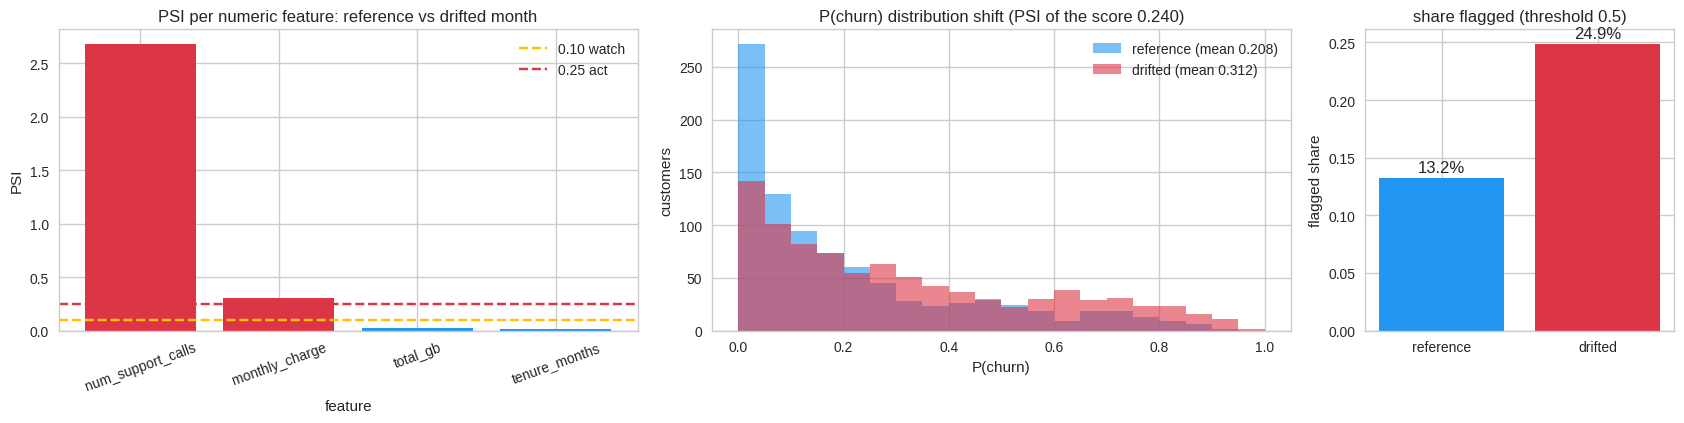

features flagged by PSI: ['num_support_calls', 'monthly_charge'] | the score distribution moved right and the flagged share rose from 13.2% to 24.9%


In [ ]:
# ============================================================
#  Picture: PSI per feature (left) and the score-distribution shift with the flagged share (right)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), gridspec_kw={"width_ratios": [3, 3, 1.6]})
colors = psi11.status.map({"act": "#dc3545", "watch": "#ffc107", "stable": "#2196F3"})
axes[0].bar(psi11.index, psi11.PSI, color=colors)
axes[0].axhline(0.10, ls="--", color="#ffc107", label="0.10 watch"); axes[0].axhline(0.25, ls="--", color="#dc3545", label="0.25 act")
axes[0].set_title("PSI per numeric feature: reference vs drifted month"); axes[0].set_ylabel("PSI"); axes[0].set_xlabel("feature"); axes[0].tick_params(axis="x", rotation=20); axes[0].legend()
bins = np.linspace(0, 1, 21)
axes[1].hist(p_ref11, bins=bins, alpha=0.6, color="#2196F3", label=f"reference (mean {p_ref11.mean():.3f})")
axes[1].hist(p_cur11, bins=bins, alpha=0.6, color="#dc3545", label=f"drifted (mean {p_cur11.mean():.3f})")
axes[1].set_title(f"P(churn) distribution shift (PSI of the score {score_psi11:.3f})"); axes[1].set_xlabel("P(churn)"); axes[1].set_ylabel("customers"); axes[1].legend()
axes[2].bar(["reference", "drifted"], [flag_ref11, flag_cur11], color=["#2196F3", "#dc3545"])
for i, v in enumerate([flag_ref11, flag_cur11]):
    axes[2].text(i, v + 0.005, f"{v:.1%}", ha="center")
axes[2].set_title("share flagged (threshold 0.5)"); axes[2].set_ylabel("flagged share")
plt.tight_layout(); plt.show()
print(f"features flagged by PSI: {psi11.index[psi11.status != 'stable'].tolist()} | the score distribution moved right and the flagged share rose from {flag_ref11:.1%} to {flag_cur11:.1%}")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, one bar per numeric feature with the two conventional lines. The two features the generator changed (`monthly_charge` up 15%, one extra `num_support_calls`) stand above the lines; the untouched features sit near zero, which is the sanity check that PSI is not noisy on nine hundred rows and ten bins. Middle, the predicted-churn histograms: the red mass slides right because higher charges and more calls both push the model's log-odds up. Right, the share of customers over the 0.5 threshold, which is the number the retention team's call list depends on.

**The common misread:** PSI says *that* an input moved, not *whether it matters*. A feature the model barely uses can drift with no effect on the scores, and a small PSI on a dominant feature can move them a lot; the middle panel is the check that decides whether to page anyone.

</div>

## 12.6 ✅ When to use it

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

**Deployment in PyCaret** is `finalize_model` → `save_model` → `load_model` → `predict_model` on raw rows, and it costs one refit and one pickle. Use `create_api` / `create_docker` when another team needs an HTTP endpoint and you want the scaffold in a minute; read the generated file before serving it. Use `log_experiment=True` from the first `setup` of a real project, not the last. Run the PSI cell on every scoring batch; it is a `groupby` and a histogram.

**The gotcha:** a finalized model has no honest test number, and a saved pipeline is tied to the library versions that wrote it.

</div>

### The capability map

| Business problem | PyCaret module | Key calls | Input shape | Output | Metric to read | Time here | vs AutoGluon / scikit-learn | Part |
|---|---|---|---|---|---|---|---|---|
| Will this customer leave? (yes/no) | `ClassificationExperiment` | `setup(df, target)` → `compare_models(include=[...], sort="AUC")` → `predict_model` | one row per entity, 0/1 label | `prediction_label`, `prediction_score` (+ `_1` with `raw_score=True`); the compare table | AUC, PR-AUC, F1, MCC | ~1 min | AutoGluon: one `fit` with stacking, no plot gallery; sklearn: you write the pipeline and the loop | 1 |
| Which of five grades? | `ClassificationExperiment` (multiclass inferred) | `compare_models(sort="Accuracy")`, `add_metric` for macro-F1, `predict_model(raw_score=True)` | one row per entity, K-valued label | `prediction_score_A..E` | accuracy, macro-F1, per-class recall | ~1 min | AutoGluon: same call as binary; sklearn: `OneVsRest` or native | 2 |
| What price / how much? | `RegressionExperiment` | `setup(..., transform_target=True)` → `compare_models(sort="MAE")` → `plot_model("residuals")` | one row per entity, numeric label | a number per row | MAE, RMSE, R², MAPE | ~1 min | AutoGluon: `eval_metric="mean_absolute_error"`; sklearn: `TransformedTargetRegressor` | 3 |
| Squeeze the winner | `ClassificationExperiment` | `tune_model` → `ensemble_model` → `blend_models` → `stack_models` → `calibrate_model` → `optimize_threshold` | a fitted model | a better model, one `pull()` table per step | CV AUC / F1 per step, reliability curve | 1-2 min | AutoGluon: automatic (bagging + stacking are the default); sklearn: `RandomizedSearchCV`, `VotingClassifier`, `StackingClassifier` | 4 |
| Find the 1% (fraud) | `ClassificationExperiment` | `setup(fix_imbalance=True)`, `add_metric("pr_auc", ...)`, `optimize_threshold`, `predict_model(probability_threshold=t)` | one row per event, rare 0/1 label | scores + a cost-optimal threshold | PR-AUC, cost curve, recall at t | ~1 min | AutoGluon: `eval_metric="average_precision"` + `calibrate_decision_threshold`; sklearn: `class_weight`, `imblearn` | 5 |
| Group customers with no labels | `ClusteringExperiment` | `setup(df, normalize=True)` → `create_model("kmeans", num_clusters=k)` → `assign_model` | feature matrix, no label | a `Cluster` column, Silhouette / CH / DB | Silhouette, elbow, a profile table | seconds | AutoGluon: none; sklearn: `KMeans` + `silhouette_score` by hand | 6 |
| Flag the odd transactions | `AnomalyExperiment` | `setup(df)` → `create_model("iforest", fraction=f)` → `assign_model` | feature matrix, no label | `Anomaly`, `Anomaly_Score` | precision@k against known cases | seconds | AutoGluon: none; sklearn: `IsolationForest`, `LocalOutlierFactor` | 7 |
| How many units next fortnight? | `TSForecastingExperiment` | `setup(data, target, fh=14)` → `compare_models(include=[...])` → `predict_model(fh, X=future_exog, return_pred_int=True)` | one series with a `DatetimeIndex`, exogenous columns beside it | a forecast frame with intervals | MASE, RMSSE, SMAPE | 1-2 min | AutoGluon: many series + Chronos zero-shot; sklearn: none (sktime, statsmodels) | 8 |
| Text next to numbers | `ClassificationExperiment` after `TfidfVectorizer` + `TruncatedSVD` | engineer text features → `setup` → `compare_models` | a DataFrame with a text column (engineered first) | as classification | AUC of raw-text vs engineered routes | ~1 min | AutoGluon: text columns handled natively, or `MultiModalPredictor`; sklearn: the same TF-IDF recipe | 9 |
| Why this score? Is it fair? | `ClassificationExperiment` | `interpret_model("summary")`, `shap.TreeExplainer`, `permutation_importance`, `check_fairness` | a fitted tree model + the transformed held-out rows | beeswarm, reason codes, per-group table | mean SHAP, permutation AUC drop, TPR / selection-rate gaps | seconds | AutoGluon: `feature_importance` + SHAP by hand; sklearn: `permutation_importance` + `shap` | 10 |
| Ship it and watch it | any experiment | `finalize_model` → `save_model` / `load_model` → `predict_model` → `create_api` → `log_experiment=True` → PSI | a fitted model, fresh raw rows | a `.pkl`, an API file, a run log, a PSI table | frozen report card, PSI per feature and of the score | seconds | AutoGluon: `save` / `clone_for_deployment`; sklearn: `joblib` + your own service | 11 |

### The decision flowchart

```text
Start: a business question and a table
│
├─ Is there a label column?
│    ├─ No ─▶ want groups to name ──────────────▶ ClusteringExperiment: kmeans, assign_model, profile table (Part 6)
│    │        want the odd rows ─────────────────▶ AnomalyExperiment: iforest with fraction=, precision@k (Part 7)
│    └─ Yes
│         ├─ Is the table one series in time? ─▶ TSForecastingExperiment: fh=, exogenous columns, MASE (Part 8)
│         │     many series or long horizons ──▶ AutoGluon TimeSeriesPredictor (the AutoGluon tour)
│         ├─ Is there free text? ──────────────▶ engineer TF-IDF/SVD features first (Part 9); long varied text ──▶ AutoGluon MultiModal
│         ├─ label is 0/1 ─────────────────────▶ ClassificationExperiment, sort="AUC" (Part 1)
│         │     rare positives ─────────────────▶ fix_imbalance, PR-AUC, optimize_threshold, a cost curve (Part 5)
│         ├─ label has K classes ──────────────▶ ClassificationExperiment, macro-F1, the confusion heatmap (Part 2)
│         └─ label is a number ────────────────▶ RegressionExperiment, MAE, transform_target when skewed (Part 3)
│
├─ The winner is close but not enough? ──────▶ tune_model → blend/stack → calibrate_model → optimize_threshold (Part 4)
├─ Someone will act on a single score? ──────▶ interpret_model, reason codes, check_fairness with the base rate (Part 10)
├─ Need the best number, not the fastest? ──▶ AutoGluon presets="best_quality" / "extreme_quality"; rows > ~1M ──▶ RAPIDS cuML or use_gpu=True
└─ Always: show_input first, test_data= in setup, report_card on held-out rows, freeze it before finalize_model, PSI on every batch (Part 11)
```

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 SOTA 2026: where low-code sits, as of September 2026

- **PyCaret 3.3.2 (28 April 2024) is still the latest stable release**, and the version this notebook was verified against. Its PyPI metadata declares `requires_python >= 3.9`; it was tested on Python 3.9 to 3.11 and its pinned dependencies frequently fail to resolve on 3.12+. Pin a 3.11 kernel when the install cell at the top breaks.
- **PyCaret 4.0 exists only as alphas** (4.0.0a0 on 23 April 2026 through 4.0.0a8 on 8 May 2026): a rewrite with a lean core (about 41 default packages instead of about 90), Python 3.11 to 3.13, and an **OOP-only** API — the functional `from pycaret.classification import *` style is removed, the five `*Experiment` classes this tour used are what survives. A "control plane" (FastAPI backend + web UI) sits on top. Learn the experiment objects; do not build production on an alpha.
- **`setup(use_gpu=True)` swaps engines, it does not add models**: `lr`, `knn`, `rf`, `svm`, `ridge`, `kmeans`, `dbscan` move to RAPIDS cuML when it is importable; `xgboost`, `lightgbm`, `catboost` flip their own device flags; tree, Bayes and discriminant models stay on the CPU. Missing cuML gives a warning and a fallback; `use_gpu="force"` raises. **RAPIDS cuML 26.06 (June 2026)** is the documented stable line, and its `cuml.accel` runs unchanged scikit-learn, umap-learn and hdbscan code on the GPU with `%load_ext cuml.accel`, which reaches PyCaret's sklearn engines untouched.
- **AutoGluon 1.6 (1.6.0 on 5 August 2026; 1.6.3 on 18 September 2026)** is the full-AutoML neighbour: multi-layer stacking by default, and the `extreme_quality` preset built on tabular foundation models (Nori, TabICLv2, TabDPT-Turbo; `noncommercial` adds TabPFN-3) that needs a GPU. PyCaret's answer to foundation models is the **`estimator=` hook**: `create_model(<any sklearn-compatible object>)` puts TabPFN, TabICL or your own class through the same `pull()`, `plot_model`, `blend_models` and `save_model` lifecycle as `"lightgbm"`.
- **Where the tour's twelve capabilities land in 2026:** PyCaret for the first afternoon (compare, plot, explain, ship) on tables up to a few million rows; AutoGluon when the number matters more than the hour and for many-series forecasting, text and images; RAPIDS when a fit stops finishing inside a meeting; plain scikit-learn when you need every knob or a one-package dependency list.

</div>

## 12.7 Task 12 Summary

**✅ Key Takeaways**
- `finalize_model` refits on train + test; the honest report card must be frozen before it (`frozen11`), and the finalized pipeline is what `save_model` ships.
- `load_model` returns the whole pipeline: raw rows in the original layout go in, labels and probabilities come out, identical to the in-memory model.
- `create_api` writes a FastAPI file (printed, not served); `log_experiment=True` turns every `setup` and `create_model` into a run when MLflow is installed.
- PSI per feature says which inputs moved; the PSI of the score and the flagged share say whether the model cares; the retrain path closes the loop once labels arrive.
- The capability map and the flowchart route any new business question to one module, one call sequence, one metric and one Part.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `fresh11`, `reference11`, `drifted11` | five raw customers to score, last month (the held-out rows) and the drifted month |
| `frozen11`, `final11`, `after_auc` | the frozen honest report card, the finalized pipeline, the misleading post-finalize AUC |
| `model_path11`, `saved_file11`, `loaded11`, `scored11`, `out11` | the saved pipeline, its reload, and the scored fresh rows |
| `API_NAME`, `API_DIR`, `api_how` | the generated API file, its folder, and how it was written |
| `HAS_MLFLOW`, `runs11`, `exp_log` | whether MLflow is present, the run table, and the logged experiment |
| `psi`, `psi11`, `p_ref11`, `p_cur11`, `score_psi11`, `flag_ref11`, `flag_cur11` | the PSI function and table, the scores on both months, the score PSI and the flagged shares |
| `exp_rt`, `lgbm_rt`, `retrain11`, `ledger11` | the retrained experiment and model, the old-vs-retrained report card, and the deployment ledger |

**➡️ Next Up:** the closing section — one line per module, ten pitfalls tied to the Parts that showed them, and where to go next.


---

# 🏆 Cheat Sheet: every module in one line

| Capability | One line (PyCaret 3.3, experiment objects) | Part |
|---|---|---|
| Binary classification | `exp = ClassificationExperiment(); exp.setup(df, target="churned", test_data=test, index=False, fold=3, session_id=RANDOM_STATE, n_jobs=N_JOBS, verbose=False, html=False); best = exp.compare_models(include=["lr","rf","lightgbm"], fold=3, sort="AUC")` | 1 |
| Multiclass | same `setup`; `exp.add_metric("f1_macro", "F1 macro", f1_score, average="macro")`; `exp.predict_model(best, raw_score=True)` → `prediction_score_<class>` | 2 |
| Regression | `RegressionExperiment().setup(df, target="price", transform_target=True, ...)`; `compare_models(sort="MAE")`; `plot_model(m, plot="residuals")` | 3 |
| Tune and ensemble | `tune_model(m, n_iter=10, optimize="AUC", choose_better=True)` → `ensemble_model(m, method="Bagging")` → `blend_models([...], method="soft")` → `stack_models([...], meta_model=lr)` → `calibrate_model` → `optimize_threshold(optimize="F1")` | 4 |
| Rare events | `setup(..., fix_imbalance=True)`; `add_metric("pr_auc", "PR-AUC", average_precision_score, target="pred_proba")`; `predict_model(m, probability_threshold=t)` | 5 |
| Clustering | `ClusteringExperiment().setup(df, normalize=True, ...)`; `km = exp.create_model("kmeans", num_clusters=5)`; `exp.assign_model(km)` → `Cluster` | 6 |
| Anomaly detection | `AnomalyExperiment().setup(df, ...)`; `iso = exp.create_model("iforest", fraction=0.03)`; `exp.assign_model(iso)` → `Anomaly`, `Anomaly_Score` | 7 |
| Time series | `TSForecastingExperiment().setup(data=df, target="units", fh=14, fold=3, ...)`; `compare_models(include=["naive","snaive","ets","arima","theta"])`; `predict_model(best, fh=14, X=future_exog, return_pred_int=True)` | 8 |
| Text in tables | `TfidfVectorizer` + `TruncatedSVD(20)` → join → `setup` → `compare_models` | 9 |
| Explain | `exp.interpret_model(m, plot="summary")`; `shap.TreeExplainer(m).shap_values(exp.get_config("X_test_transformed"))`; `permutation_importance(m, X_te, y_te, scoring="roc_auc")`; `exp.check_fairness(m, sensitive_features=["contract"])` | 10 |
| Ship and watch | `final = exp.finalize_model(m)`; `exp.save_model(final, path)`; `exp.load_model(path)`; `exp.predict_model(loaded, data=fresh)`; `exp.create_api(final, "name")`; `setup(..., log_experiment=True)`; PSI per feature | 11 |

**The three lines never change.** `exp = XExperiment(); exp.setup(df, target=...)` → `best = exp.compare_models(...)` → `exp.predict_model(best, data=new)`. Everything in this tour was a choice of experiment class, a `setup` knob, and the shape of `df`.

---

# ⚠️ Common Pitfalls to Avoid

1. **Reading the `compare_models` table as test scores** (Part 1). They are cross-validation means on the training rows; `predict_model` on `test_data=` is the number to report.
2. **Reading `prediction_score` as P(positive)** (Parts 1, 5). It is the score of the *predicted* class; ask for `raw_score=True` and read `prediction_score_1`.
3. **Treating ordered grades as unordered classes without looking at adjacent-grade errors** (Part 2). The row-normalised confusion heatmap shows whether the misses are off by one.
4. **Optimising MAE on a skewed price without `transform_target`** (Part 3). A few mansions set the score; the second `setup` shows the difference.
5. **Assuming `tune_model` improved the model** (Part 4). Without `choose_better=True` a worse tuned model is returned silently; the step table shows every move.
6. **Accuracy on a 1.5% fraud rate** (Part 5). "Always legit" scores 98.5%; use PR-AUC, a threshold chosen on a cost curve, and `probability_threshold=`.
7. **Treating `num_clusters` and `fraction` as measured** (Parts 6, 7). They are assumptions; profile the clusters and check precision@k against something you know.
8. **Forecasting without the naive baseline** (Part 8). MASE below 1.0 is the bar; a model that does not beat seasonal-naive learned nothing, and exogenous columns must be supplied for the horizon.
9. **Reading a large selection-rate gap as bias, and reading a reason code as a fact** (Part 10). Put the base rate next to the selection rate and compare TPR and FPR gaps per group; check a reason code's column against permutation importance before an agent says it aloud.
10. **Reporting a number computed after `finalize_model`, or shipping without a drift check** (Part 11). Freeze the report card first; run PSI on every scoring batch; version the pickle with its library versions.

---

# 🚀 What's Next

1. **Go deep on one capability.** `colabs/06_data_eval_mlops/pycaret_zero_to_hero.ipynb` follows one dataset through the whole lifecycle: every `setup` knob, leakage traps, calibration, the full plot gallery, MLOps and error analysis by segment.
2. **Run the same twelve problems through the neighbour.** `colabs/06_data_eval_mlops/autogluon_capabilities_tour.ipynb` is the AutoGluon twin of this notebook: same datasets, one `fit` per Part, and the capability map's middle column in practice.
3. **Move the zoo to a GPU.** `colabs/06_data_eval_mlops/nvidia_rapids_zero_to_hero.ipynb` runs the classical models on cuDF / cuML for tables too large for this notebook; `setup(use_gpu=True)` is the PyCaret door to the same engines.
4. **Replace one generator with your data.** Keep the shape (a label column, or a series with a `DatetimeIndex`), keep `show_input` as the first call, and every other cell in that Part runs unchanged.
5. **Drop a foundation model into `create_model(estimator=...)`** on a GPU runtime (`pip install tabpfn`) and read the `pull()` table it gets, exactly like `"lightgbm"`.

---

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 34px; border-radius: 20px; color: white; text-align: center; margin: 24px 0;">

## 🎓 Course Complete

Twelve capabilities, twelve small datasets, one three-line pattern.

You can now look at a business question and a table and say which PyCaret module answers it, what the input has to look like, which one-line calls to type, which metric to read, what the fit will cost, and what comes out: a compare table, a label and a probability, a grade, a price, a cluster, an anomaly score, a forecast with intervals, a reason code, a fairness table, a saved pipeline, an API file, a drift number.

The map is the product. Keep it next to the next dataset that lands on your desk.

</div>

---

# 📚 References

**PyCaret**
- PyCaret documentation, 3.x: [pycaret.gitbook.io/docs](https://pycaret.gitbook.io/docs) — `setup` parameters, model ids, the `plot_model` and `interpret_model` galleries, `check_fairness`, `create_api`, `create_docker`, `log_experiment`.
- PyCaret source and releases: [github.com/pycaret/pycaret](https://github.com/pycaret/pycaret/releases) — 3.3.2 (28 April 2024) is the latest stable release; the 4.0.0 alphas (a0 on 23 April 2026 to a8 on 8 May 2026) are the Python 3.11+ OOP-only rewrite. [pypi.org/project/pycaret](https://pypi.org/project/pycaret/).
- Ali, M. *PyCaret: An open source, low-code machine learning library in Python* (2020).

**Explainability and fairness**
- Lundberg, S. M., Lee, S.-I. *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS 2017. Lundberg, S. M. et al. *From local explanations to global understanding with explainable AI for trees* (TreeExplainer). Nature Machine Intelligence, 2020.
- Breiman, L. *Random Forests* (permutation importance). Machine Learning, 2001.
- Hardt, M., Price, E., Srebro, N. *Equality of Opportunity in Supervised Learning*. NeurIPS 2016. Bird, S. et al. *Fairlearn: A toolkit for assessing and improving fairness in AI*. Microsoft, 2020.

**Monitoring and deployment**
- Siddiqi, N. *Credit Risk Scorecards* (the Population Stability Index and its 0.10 / 0.25 conventions). Wiley, 2006.
- Sculley, D. et al. *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 2015.

**The neighbours**
- AutoGluon 1.6 (1.6.0 on 5 August 2026, 1.6.3 on 18 September 2026): [auto.gluon.ai](https://auto.gluon.ai) — tabular foundation models tutorial and the `extreme_quality` preset.
- RAPIDS cuML 26.06 and `cuml.accel`: [docs.nvidia.com/cuml](https://docs.nvidia.com/cuml/latest/).
- Hollmann, N. et al. *Accurate predictions on small data with a tabular foundation model* (TabPFN v2). Nature, January 2025. Qu, J. et al. *TabICL: A Tabular Foundation Model for In-Context Learning on Large Data*. ICML 2025.

---

<div style="text-align: center; color: #5F6368; font-size: 0.9em; padding: 12px;">
Built for the CMPE 258 zero-to-hero Colab series · verified against <b>PyCaret 3.3.2</b> · every cell runs on a free Colab CPU without an API key
</div>


In [ ]:
# ============================================================
#  Clean up: remove every model, plot and API file this tour wrote under WORK
# ============================================================
import pycaret, sklearn
n_files = sum(len(files) for _, _, files in os.walk(WORK)) if os.path.isdir(WORK) else 0
shutil.rmtree(WORK, ignore_errors=True)
print(f"removed {WORK} ({n_files} files) | still exists: {os.path.isdir(WORK)} | artefacts were written by PyCaret {pycaret.__version__} on scikit-learn {sklearn.__version__}")


removed /tmp/pctour_x_iz1mwp (15 files) | still exists: False | artefacts were written by PyCaret 3.3.2 on scikit-learn 1.4.2
